# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [1]:
# Installing the libraries with the specified version.
#!pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 statsmodels==0.14.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#to make decision tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

# To build model for prediction
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

## Data Overview

- Observations
- Sanity checks

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/UT DS Grad Cert/Project4/"

data = pd.read_csv(path+"INNHotelsGroup.csv")

In [5]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [6]:
data.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


In [7]:
data.shape

(36275, 19)

There are 36275 observations acrosss 19 variables

In [8]:
#summarize the type of each varaible
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

Booking_ID is a categorical variable.  As a marker of each individual, it will not be used in analysis.

There are 12 true numeric variables:  no_of_adults, no_of_children, no_of_weekend_nights, no_of_week_nights, lead_time, arrival_year, arrival_month, arrival_date, no_of_previous_cancellations, no_of_previous_bookings_not_cancelled, avg_price_per_room, and no_of_special_requests.

Several of these might need to be cleaned and altered.  For example, the three date fields might need to be changed to a single value and turned into a date/time object.  Number of bookings cancelled and not cancelled might combine to a single "number of total bookings" allowing for proportional values for cancellations.  Likewise, family size/party size might also need to be created from number of children and number of adults.

There are 5 categorical variables under analysis: type_of_meal_plan, required_car_parking_space, room_type_reserved, market_segment_type, and booking status.  Booking status is our target variable.

In [9]:
#checking for missing data
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


There is no missing data.

In [10]:
#checking for duplicates
data.duplicated().sum()

np.int64(0)

There are no duplicated data.

In [11]:
#drop the booking ID column as it is not needed for evaulation
data.drop('Booking_ID', axis=1, inplace=True)

## <a name='link2'>Exploratory Data Analysis (EDA)</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

A full EDA can be found in the <a href = "#link1">appendix section</a> I made.

###Custom Functions for visualization

In [12]:
#custom definitions from the course to visualize data
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram


  # function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature, # Added to address FutureWarning
        palette="Paired",
        order=data[feature].value_counts().index[:n],
        legend=False # Added to address FutureWarning
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [13]:
#set a gray background grid for all visualizations
sns.set_style("darkgrid")

####**Leading Questions**:
1. What are the busiest months in the hotel?
2. Which market segment do most of the guests come from?
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
4. What percentage of bookings are canceled?
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

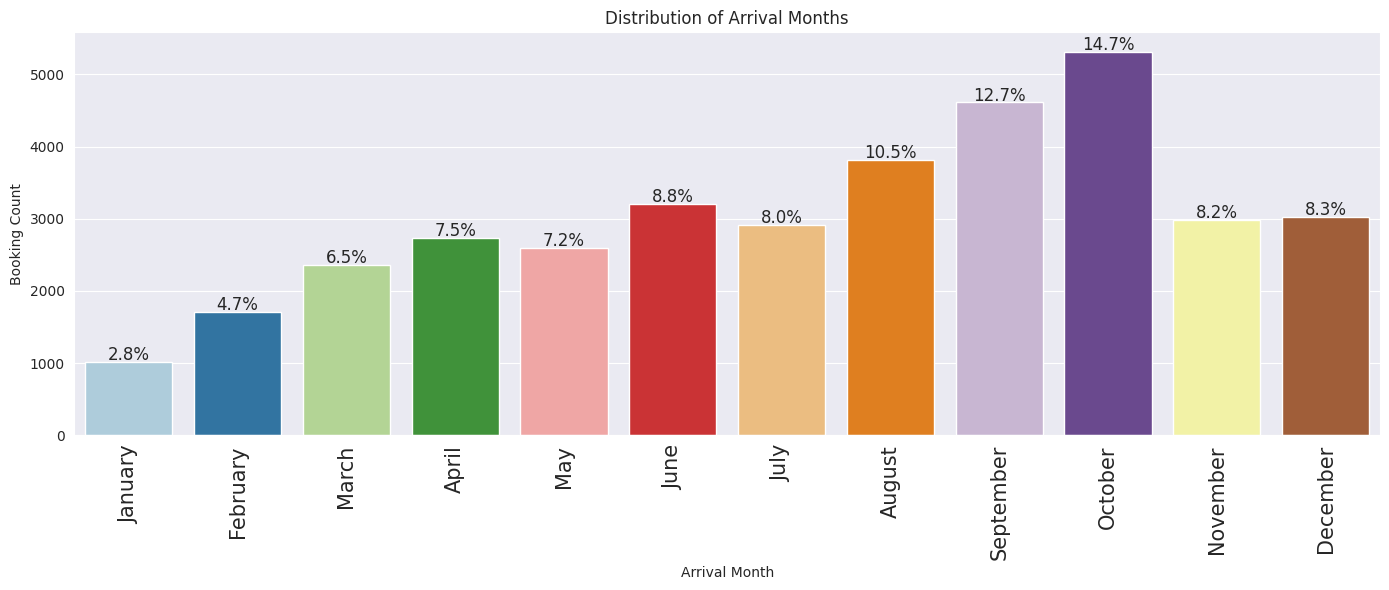


The three busiest months comprise 37.9 % of bookings.
The three slowest months comprise 14.0 % of bookings.


In [14]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(len(months) + 2, 6))

# Get unique month numbers, sorted to ensure chronological order
month_order = sorted(data['arrival_month'].unique())

ax = sns.countplot(
    data=data,
    x='arrival_month',
    hue='arrival_month',
    palette="Paired",
    order=month_order,
    legend=False
)

# Set the x-tick labels to month names
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=90, fontsize=15)

# Add percentage annotations
total_bookings = len(data)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        label = "{:.1f}%".format(100 * height / total_bookings)
        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.xlabel("Arrival Month")
plt.ylabel("Booking Count")
plt.title("Distribution of Arrival Months")
plt.tight_layout()
plt.show()

print("="*150,"\n")
print("The three busiest months comprise", 10.5+12.7+14.7,"% of bookings.")
print("The three slowest months comprise", 2.8+4.7+6.5,"% of bookings.")

###Observation on Months
The three busiest months are the late summer / early autumn months of August, September, and October.  In total, these three months comprise 37.9% of the yearly bookings.  The three slowest months are the winter months of January, February, and March.  These months comprise only 14% of the bookings.

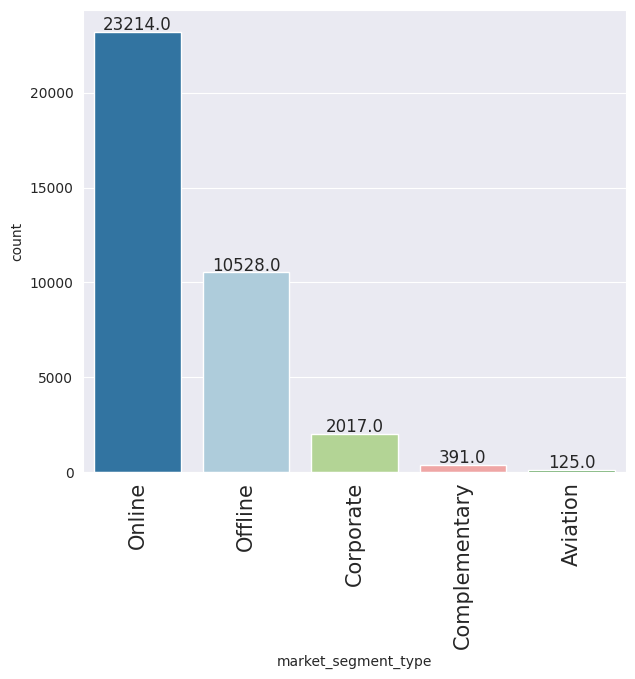

Table of market segment types as a percentage:
market_segment_type
Online           63.99
Offline          29.02
Corporate         5.56
Complementary     1.08
Aviation          0.34
Name: proportion, dtype: float64


In [15]:
#bargraph showing the market segments
labeled_barplot(data, 'market_segment_type')
print("Table of market segment types as a percentage:")
print(round(data['market_segment_type'].value_counts(normalize=True) * 100, 2))


###Observations on Market Segment Type
A significant majority of the reservations come from online at nearly 64% of all reservations.  Another 29% come from offline reservations.  The balance of reservations come from the last three categories.  Thus, it appears that individuals (rather than companies) handle roughly 93% of all hotel reservations over this time period.

market_segment_type
Aviation         100.704000
Complementary      3.141765
Corporate         82.911740
Offline           91.632679
Online           112.256855
Name: avg_price_per_room, dtype: float64




Market segment type: Online


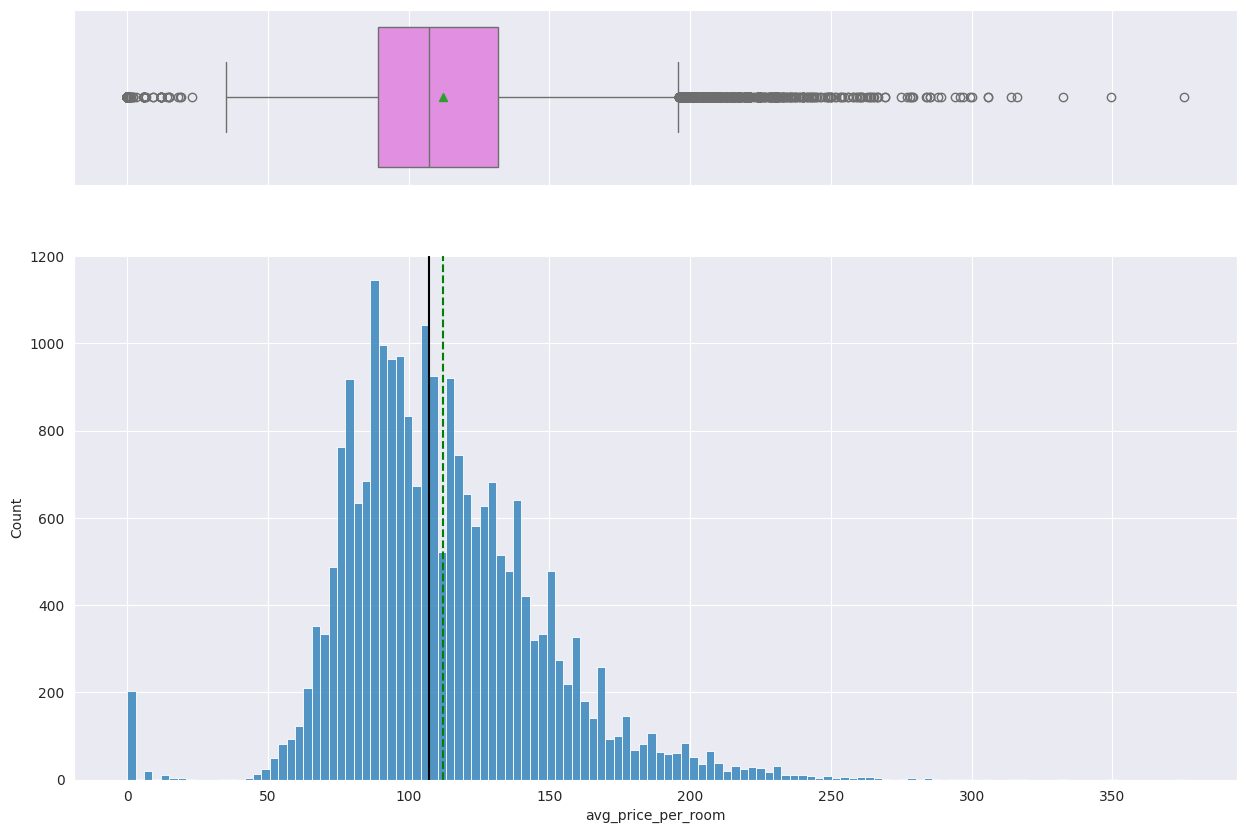





Market segment type: Offline


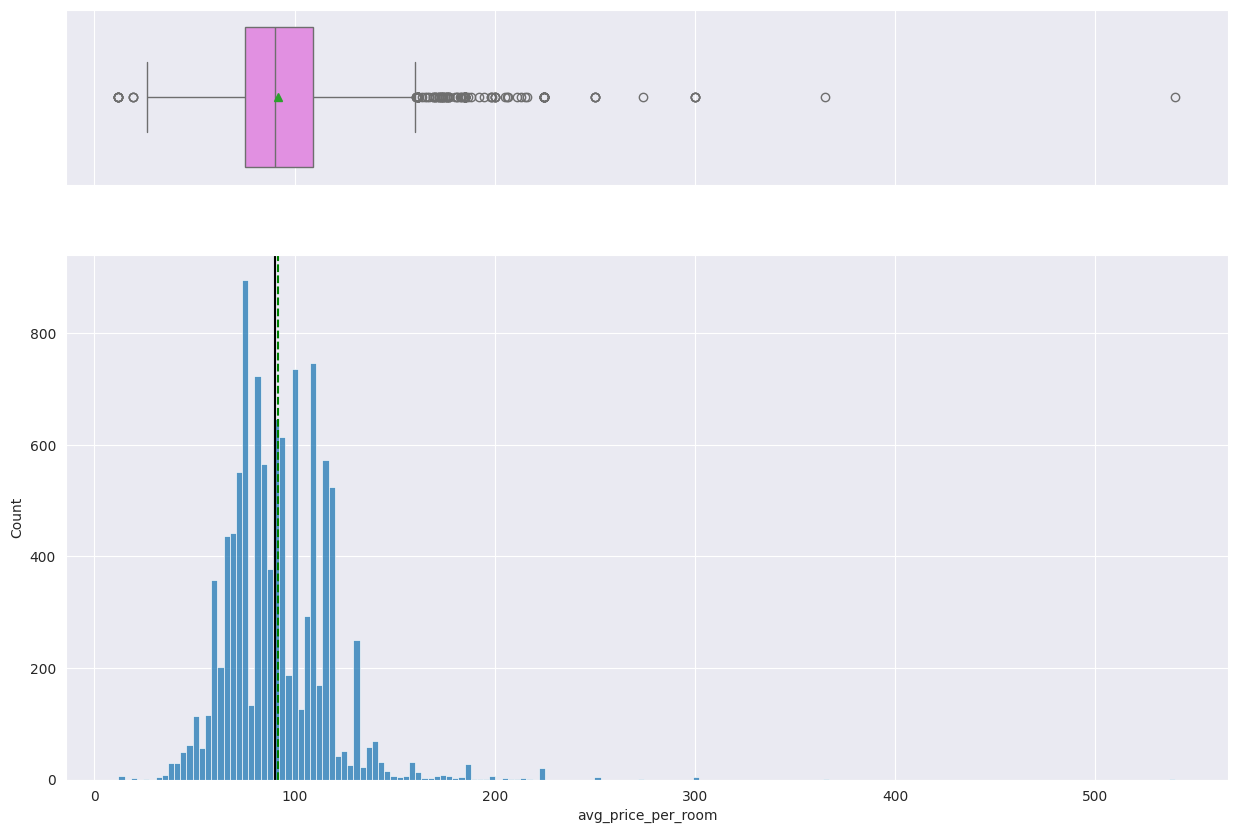





Market segment type: Corporate


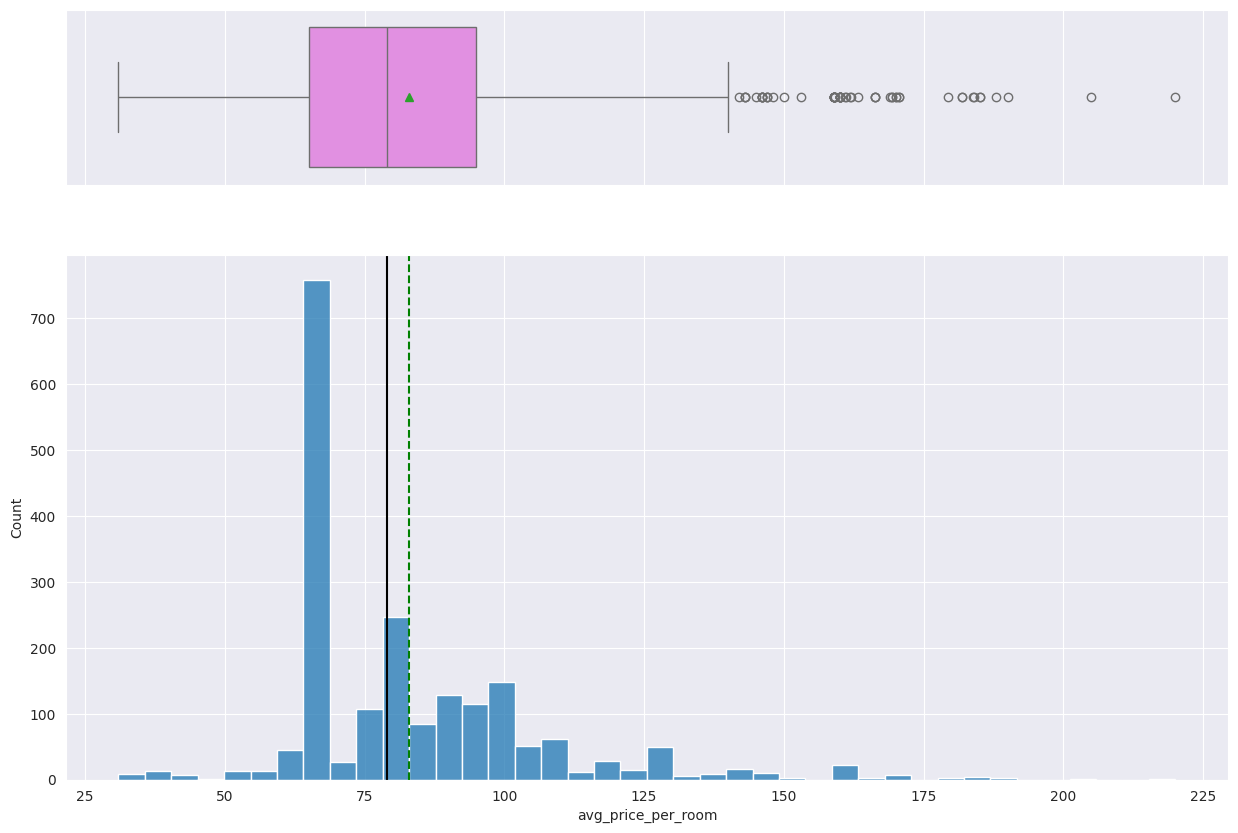





Market segment type: Aviation


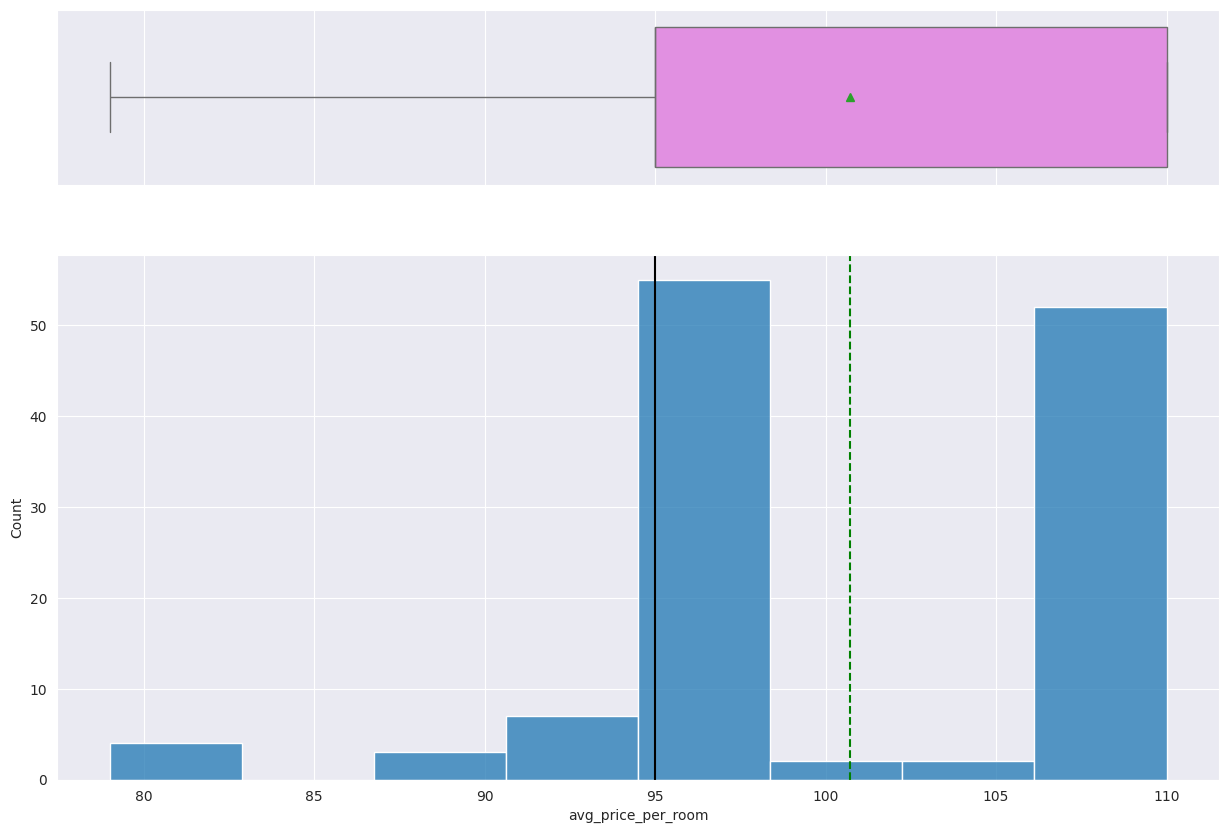





Market segment type: Complementary


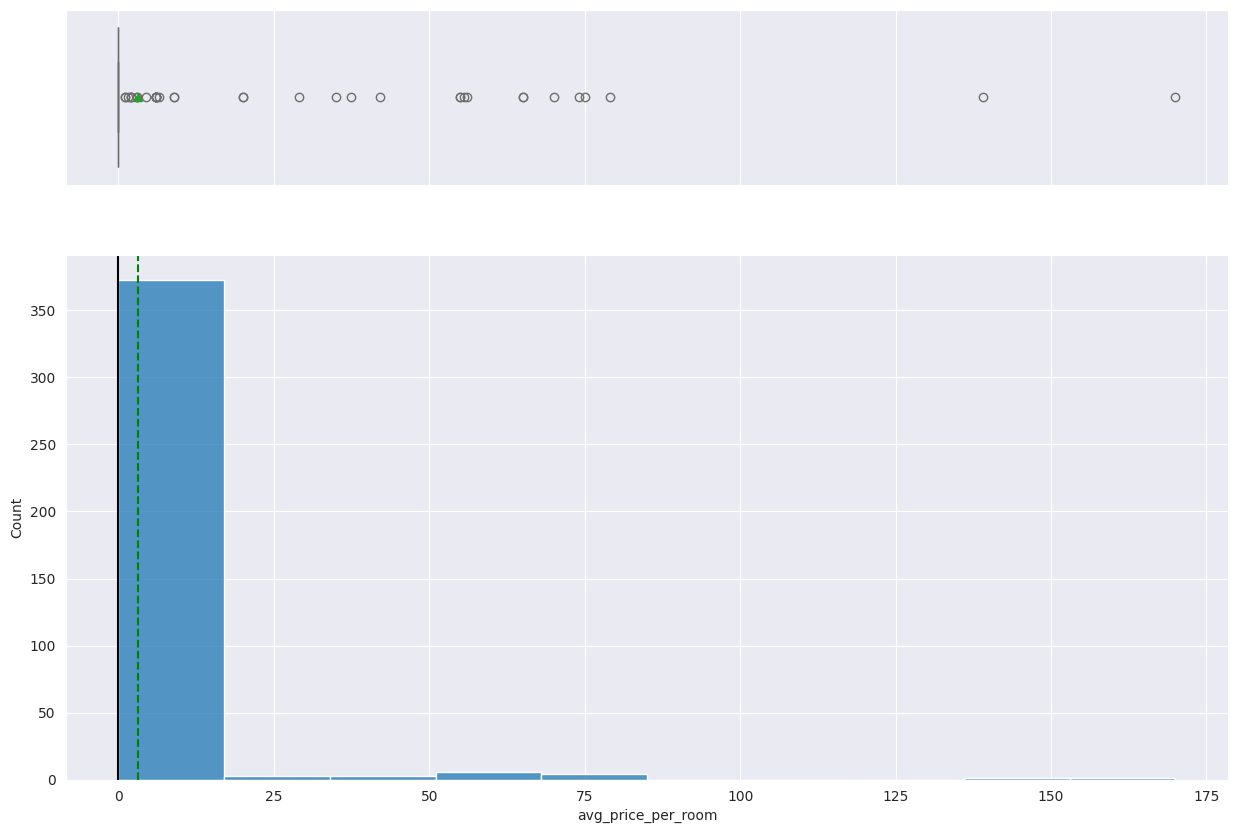

In [16]:
#room prices by market_segment
print(data.groupby('market_segment_type')['avg_price_per_room'].mean())
print("\n\n", "="*150,"\n\n")

#boxplot_histograms of room price by market segment
market_segment_order = ['Online', 'Offline', 'Corporate', 'Aviation', 'Complementary']
for market_type in market_segment_order:
  print("Market segment type:", market_type)
  # Filter the data for the current market_type
  filtered_data = data[data['market_segment_type'] == market_type]
  # Call histogram_boxplot with the filtered data and the correct feature name
  histogram_boxplot(filtered_data, 'avg_price_per_room')
  plt.show()
  print("\n\n", "="*150,"\n\n")

In [17]:
#Numeric summary of prices sorted by market_segment_type
# Set maximum columns to show all of them and prevent line wrapping
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000) # Setting a very large width to prevent wrapping
print(data.groupby('market_segment_type')['avg_price_per_room'].describe().T)

market_segment_type    Aviation  Complementary    Corporate       Offline        Online
count                125.000000     391.000000  2017.000000  10528.000000  23214.000000
mean                 100.704000       3.141765    82.911740     91.632679    112.256855
std                    8.538361      15.512972    23.690001     24.995597     35.220319
min                   79.000000       0.000000    31.000000     12.000000      0.000000
25%                   95.000000       0.000000    65.000000     75.000000     89.000000
50%                   95.000000       0.000000    79.000000     90.000000    107.100000
75%                  110.000000       0.000000    95.000000    109.000000    131.750000
max                  110.000000     170.000000   220.000000    540.000000    375.500000


###Observations on Market Segment Prices
Overall, online reservations were €112.25 per reservation.  Aviation was the next most expensive at €100.70 on average.  Offline reservations were €91.63 and corporate reservations were the least expensive paid reservations at €82.91.  Complementary reservations should be viewed separately since the hotel is making a loss on these, but they average €3.14 each.

All prices across the segments showed a large amount of variation.  All segements were right skewed except for aviation reservations which were left skewed.  This is suggestive of the hotel charging airlines a bit more for the short notice nature of these reservations.

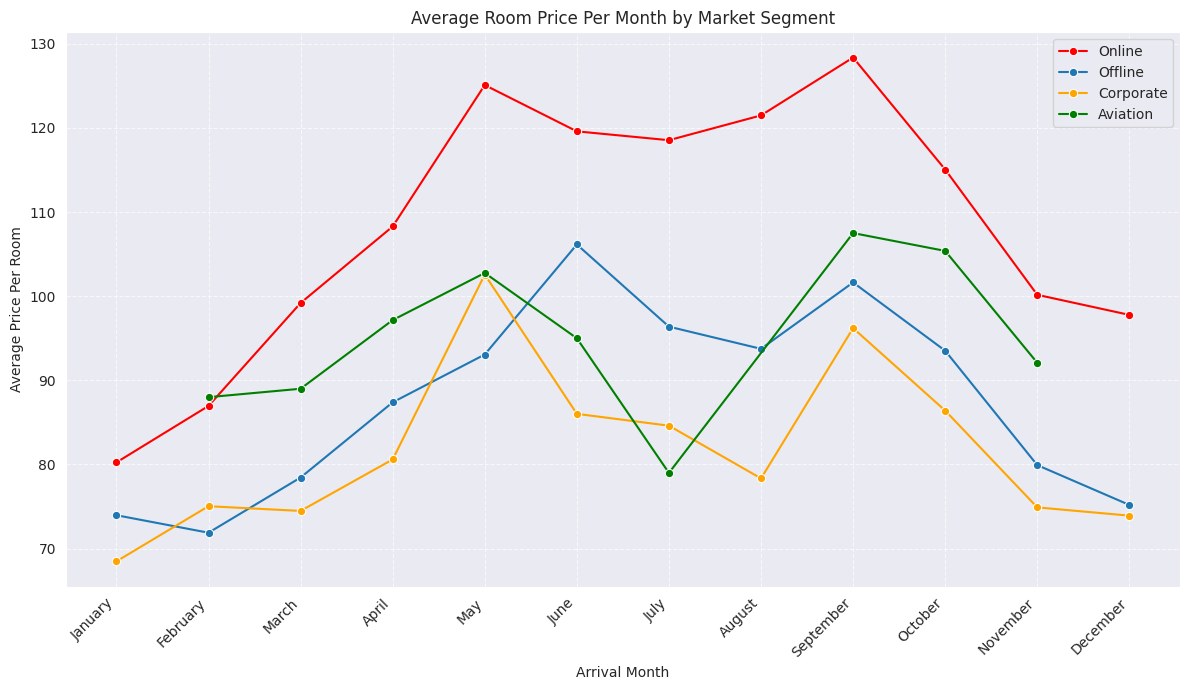

In [18]:
#create a time series of average room price by month, grouped by market segment

# Group by arrival_month and repeated_guest, then calculate the mean of avg_price_per_room
price_by_month_market = data.groupby(['arrival_month', 'market_segment_type'])['avg_price_per_room'].mean().unstack()

# Plotting the time series
plt.figure(figsize=(12, 7))

# Plot for online
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market['Online'], marker='o', label='Online', color = "red")

# Plot for offline (repeated_guest = 1)
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Offline"], marker='o', label='Offline')

# Plot for corporate
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Corporate"], marker='o', label='Corporate', color = "orange")

# Plot for aviation
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Aviation"], marker='o', label='Aviation', color = "green")

plt.title('Average Room Price Per Month by Market Segment')
plt.xlabel('Arrival Month')
plt.ylabel('Average Price Per Room')

# Use the 'months' list defined earlier for x-axis labels
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xticks(ticks=range(1, 13), labels=months, rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

###Observations on Room Price by Market Segment over time
This is a more detailed breakdown of price by market segment while also considering the different months of the year.  Ovearll, online reservations showed the highest average price on a month by month basis.  The next highest was aviation overall, but with a dip during June and July.  Offline reservations trended close to the corporate cost, but was slightly higher than corporate costs nearly every month.  We also see a spike in prices for all segments during the busy months of August, September, and October.  There is a corresponding dip in the prices during the slow months of January, February, and March.  The only exception to this general trend is an unanticipated drop in the average price for aviation reservations in July.  More research beyond the scope of the data may be necessary to explain this dip.

In [19]:
#show the overall percentage of bookings that were cancelled
print("Percentage of bookings that were cancelled")
cancelled_bookings = data['booking_status'].value_counts(normalize=True) * 100
print(round(cancelled_bookings, 2))

#show the conditional proportion (as a %) of booking_status | repeated_guests
print("\n\n", "="*150,"\n\n")
print("Percentage of booking cancellations for repeated guests:")
rep_guests_cancellations = pd.crosstab(data['repeated_guest'], data['booking_status'], normalize='index') * 100
print(round(rep_guests_cancellations, 2))

Percentage of bookings that were cancelled
booking_status
Not_Canceled    67.24
Canceled        32.76
Name: proportion, dtype: float64




Percentage of booking cancellations for repeated guests:
booking_status  Canceled  Not_Canceled
repeated_guest                        
0                  33.58         66.42
1                   1.72         98.28


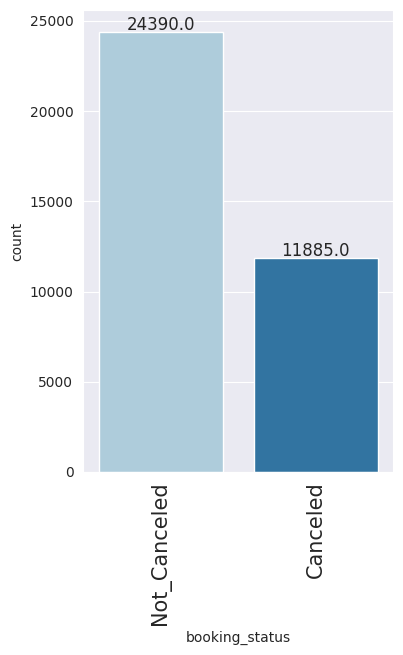

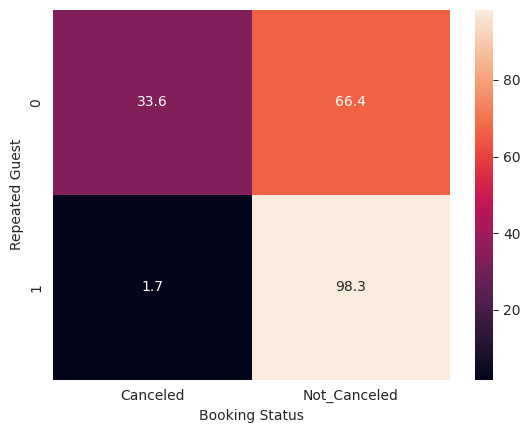

In [20]:
#bargraph of cancelled reservations
labeled_barplot(data, 'booking_status')

#heatmap of booking cancellations for repeated_guest
sns.heatmap(rep_guests_cancellations, annot = True, fmt=".1f") # Corrected: annot=True to show data values, added fmt
plt.ylabel("Repeated Guest") # Corrected: use plt instead of plot
plt.xlabel("Booking Status") # Corrected: use plt instead of plot
plt.show() # Added to ensure plot displays

###Observation on Cancellations

Overall, 32.76% of reservations are cancelled.  This is almost 1 in every 3 reservations, leading to significant lost of revenue and higher costs for the hotel.  However, when grouping the data by repeated customers, we see that only 1.7% of reservations made by repeated customers are cancelled.  This suggests that the hotel does very well once a customer's loyalty is earned (whether that loyalty is via individuals or via corporate relationships is an open question: see Appendix for a breakdown of market_segement by repeated_guest).

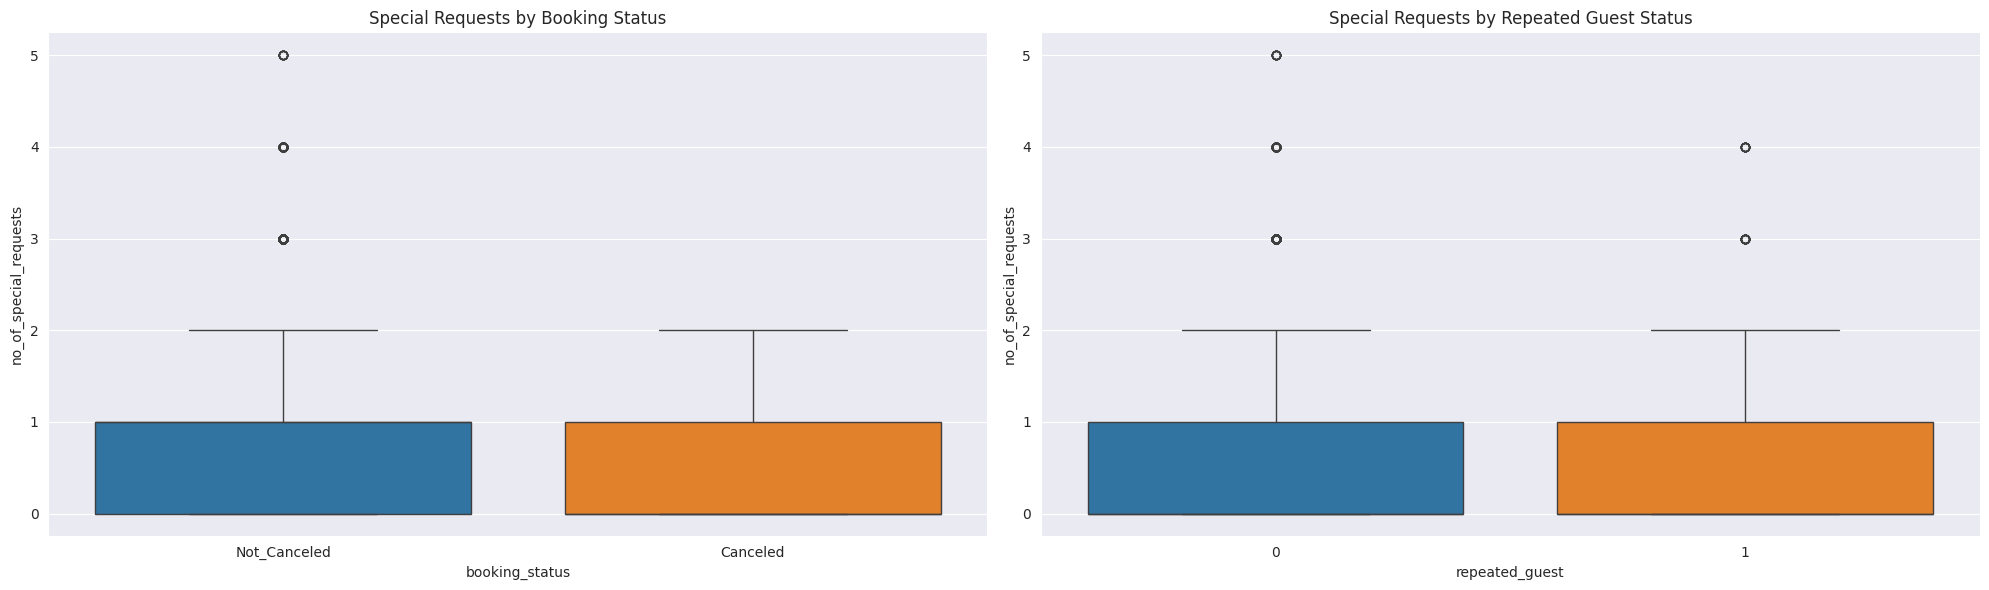





Number of special requests by booking status:
booking_status          Canceled  Not_Canceled
no_of_special_requests                        
0                           8545         11232
1                           2703          8670
2                            637          3727
3                              0           675
4                              0            78
5                              0             8




Percentage of special requests by booking status:
booking_status          Canceled  Not_Canceled
no_of_special_requests                        
0                          43.21         56.79
1                          23.77         76.23
2                          14.60         85.40
3                           0.00        100.00
4                           0.00        100.00
5                           0.00        100.00




Number of special requests by repeated guest status:
repeated_guest              0    1
no_of_special_requests            
0                

In [21]:
#boxplot for number of special requests grouped by booking_status and repeated_guest status on a single grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# Boxplot for number of special requests grouped by booking_status
sns.boxplot(data=data, x='booking_status', y='no_of_special_requests', hue='booking_status', legend=False, palette='tab10', ax=axes[0])
axes[0].set_title('Special Requests by Booking Status')

# Boxplot for number of special requests grouped by repeated_guest status
sns.boxplot(data=data, x='repeated_guest', y='no_of_special_requests', hue='repeated_guest', legend=False, palette='tab10', ax=axes[1])
axes[1].set_title('Special Requests by Repeated Guest Status')

plt.tight_layout()
plt.show()

#display table of number of special requests by booking status
print("\n\n", "="*150,"\n\n")
req_status = pd.crosstab(data['no_of_special_requests'], data['booking_status'])
print("Number of special requests by booking status:")
print(req_status)

#display same table with row normalization
print("\n\n", "="*150,"\n\n")
print("Percentage of special requests by booking status:")
print(round(req_status.div(req_status.sum(axis=1), axis=0) * 100, 2))


#display table with number of special request by repeat customer status
print("\n\n", "="*150,"\n\n")
req_repeat = pd.crosstab(data['no_of_special_requests'], data['repeated_guest'])
print("Number of special requests by repeated guest status:")
print(req_repeat)

#same table with column normalization
print("\n\n", "="*150,"\n\n")
print("Percentage of special requests by repeated guest status:")
print(round(req_repeat.div(req_repeat.sum(axis=0), axis=1) * 100, 2))


###Observation on special requests by booking status
Based on the visualization and summary tables above, the number of special requests made seems to have a large impact on the likelihood of cancellations.  The higher the number of requests made, the less likely a reservation will be cancelled.  There does not appear to be a signficant distinction between special requests and repeated guest status.  This is suggestive of a possible marketing strategy.  The Inn may want to highlight on how it will meet guests' individual needs.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [22]:
data2 = data.copy()
#map booking status to numbers
data2["booking_status"] = data2["booking_status"].apply(lambda x: 1 if x == "Canceled" else 0)

#I can drop the complementary rooms since these are a loss already and should not be considered as a predictor of cancellations
data2 = data2[data2["market_segment_type"] != "Complementary"]




Number of numeric columns for boxplots: 11


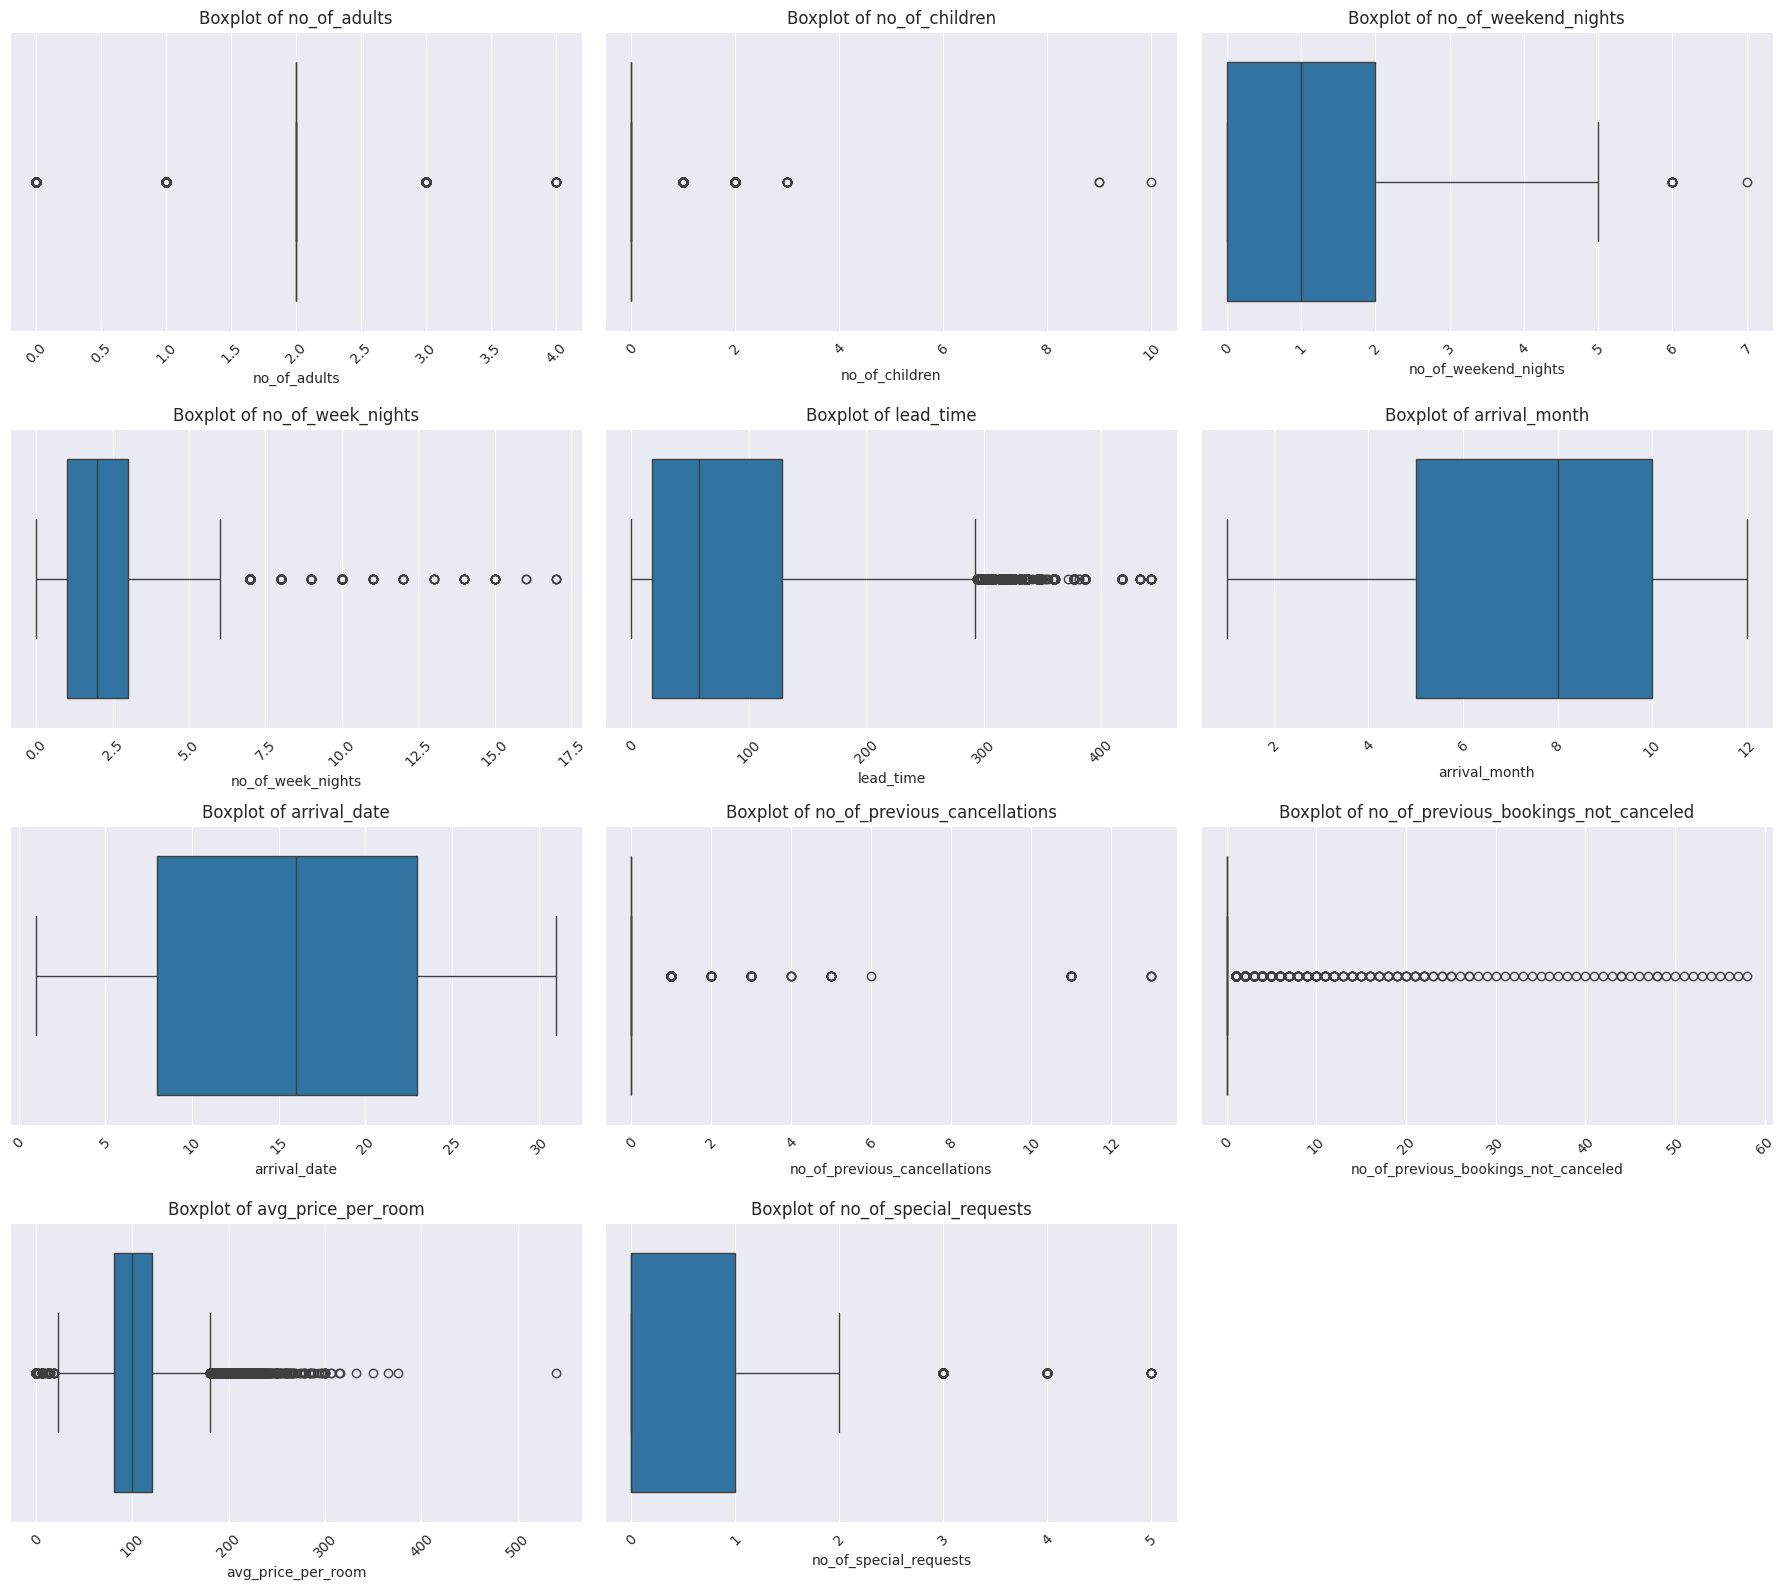

In [23]:
#outlier detection
#pull numeric columns from data2
num_cols = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'lead_time', 'arrival_month', 'arrival_date', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']
print(f"Number of numeric columns for boxplots: {len(num_cols)}")

# Create subplots for boxplots in a 4x3 grid
n_rows = 4
n_cols = 3
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 6, n_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Loop through numeric columns and plot boxplots
for i, col in enumerate(num_cols):
    sns.boxplot(data=data2, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots if the number of columns is less than n_rows * n_cols
for j in range(len(num_cols), n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

room_type_reserved
Room_Type 1     96.732220
Room_Type 2     90.460714
Room_Type 3    103.150000
Room_Type 4    126.354585
Room_Type 5    131.747621
Room_Type 6    184.892437
Room_Type 7    206.053193
Name: avg_price_per_room, dtype: float64


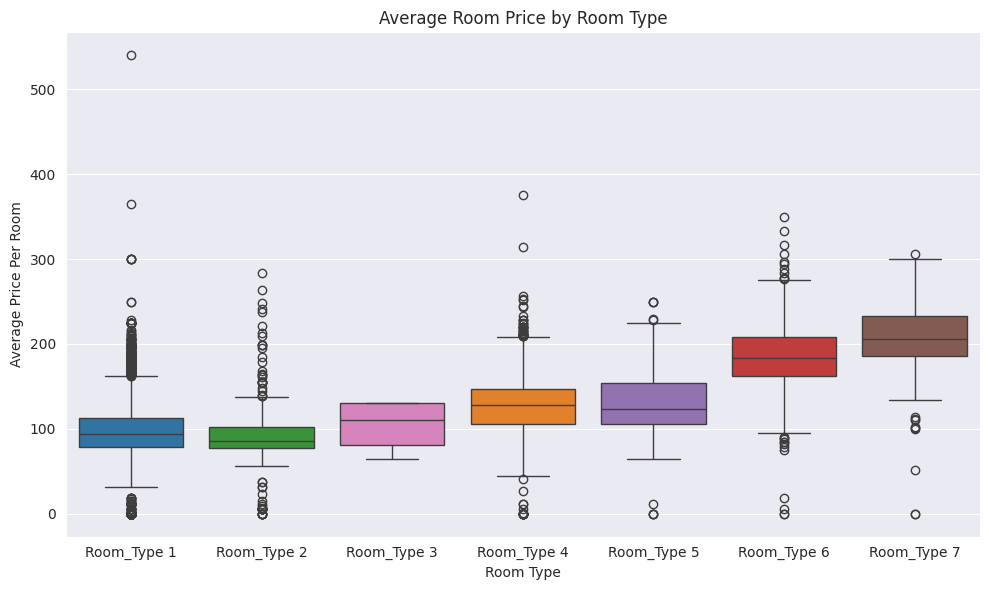

In [24]:
#show average room price by room type
print(data2.groupby('room_type_reserved')['avg_price_per_room'].mean())
plt.figure(figsize=(10, 6))
# Define the desired order for room types
room_type_order = ['Room_Type 1', 'Room_Type 2', 'Room_Type 3', 'Room_Type 4', 'Room_Type 5', 'Room_Type 6', 'Room_Type 7']
ax = sns.boxplot(data=data2, x='room_type_reserved', y='avg_price_per_room', hue='room_type_reserved', legend=False, palette='tab10', order=room_type_order)
plt.title('Average Room Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price Per Room')
plt.tight_layout()
plt.show()

### Observation on Room Type outliers
There are some outliers in this data set that are concerning to me.  The first, and most glaring, is the very high price of a single observation in Room 1.  This is more than 5 times more expensive than the mean price of that room type and seems a little extreme.  Additionally, multiple room types are showing up at a zero or near zero cost even after we have dropped the complementary room price.  To adjust for these, I will perform outlier capping using a percentile method.  I will set a lower cap for 1% and an upper cap at 99% and see how that affects my data.

In [25]:
#find number of observations that are less than 1 percentile or greater than 99th percentile

outlier_counts = {}

# Group by room_type_reserved
for room_type, group in data2.groupby('room_type_reserved'):
    # Calculate 1st and 99th percentiles for avg_price_per_room within each group
    lower_bound = group['avg_price_per_room'].quantile(0.01)
    upper_bound = group['avg_price_per_room'].quantile(0.99)

    # Count observations outside the bounds
    outliers = group[(group['avg_price_per_room'] < lower_bound) | (group['avg_price_per_room'] > upper_bound)]
    num_outliers = len(outliers)

    # Store the results
    outlier_counts[room_type] = {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'num_outliers': num_outliers,
        'total_observations': len(group)
    }

# Print the results for each room type
print("Outlier analysis for avg_price_per_room by room_type_reserved:")
for room_type, data in outlier_counts.items():
    print(f"\nRoom Type: {room_type}")
    print(f"  1st Percentile (Lower Bound): {data['lower_bound']:.2f}")
    print(f"  99th Percentile (Upper Bound): {data['upper_bound']:.2f}")
    print(f"  Number of Outliers: {data['num_outliers']} ({(data['num_outliers']/data['total_observations'])*100:.2f}% of total {data['total_observations']})")

Outlier analysis for avg_price_per_room by room_type_reserved:

Room Type: Room_Type 1
  1st Percentile (Lower Bound): 40.67
  99th Percentile (Upper Bound): 170.00
  Number of Outliers: 550 (1.97% of total 27883)

Room Type: Room_Type 2
  1st Percentile (Lower Bound): 6.00
  99th Percentile (Upper Bound): 210.07
  Number of Outliers: 13 (1.93% of total 672)

Room Type: Room_Type 3
  1st Percentile (Lower Bound): 65.63
  99th Percentile (Upper Bound): 130.00
  Number of Outliers: 1 (20.00% of total 5)

Room Type: Room_Type 4
  1st Percentile (Lower Bound): 60.00
  99th Percentile (Upper Bound): 203.76
  Number of Outliers: 115 (1.92% of total 6005)

Room Type: Room_Type 5
  1st Percentile (Lower Bound): 5.64
  99th Percentile (Upper Bound): 240.41
  Number of Outliers: 6 (2.42% of total 248)

Room Type: Room_Type 6
  1st Percentile (Lower Bound): 88.77
  99th Percentile (Upper Bound): 277.49
  Number of Outliers: 20 (2.10% of total 952)

Room Type: Room_Type 7
  1st Percentile (Lower B

In [26]:
total_outliers = 0
for room_type, data in outlier_counts.items():
    total_outliers += data['num_outliers']

total_observations_data2 = len(data2)
percentage_data_lost = (total_outliers / total_observations_data2) * 100

print(f"Total number of outliers across all room types: {total_outliers}")
print(f"Total percentage of data lost from data2 if outliers are removed: {percentage_data_lost:.2f}%")

Total number of outliers across all room types: 709
Total percentage of data lost from data2 if outliers are removed: 1.98%


###Observations on trimming using the percentile method.  

Overall, this will cause a loss of 1.98% of the data.  This is within the generally accepted "safe" threshold of 3% data loss.  Thus, these outliers will be trimmed, not capped.

In [27]:
#trimming the outliers using the percentile method

for room_type, data in outlier_counts.items():
    lower_bound = data['lower_bound']
    upper_bound = data['upper_bound']

    # Filter out outliers for the current room type
    # Ensure we are modifying data2 in place or reassigning it correctly
    data2 = data2[~((data2['room_type_reserved'] == room_type) &
                    ((data2['avg_price_per_room'] < lower_bound) |
                     (data2['avg_price_per_room'] > upper_bound)))]

data2.reset_index(drop=True, inplace=True)
print(f"Data2 shape after trimming outliers: {data2.shape}")

Data2 shape after trimming outliers: (35175, 18)


room_type_reserved
Room_Type 1     96.649206
Room_Type 2     89.651608
Room_Type 3    112.687500
Room_Type 4    126.200073
Room_Type 5    131.914917
Room_Type 6    185.060687
Room_Type 7    207.950696
Name: avg_price_per_room, dtype: float64


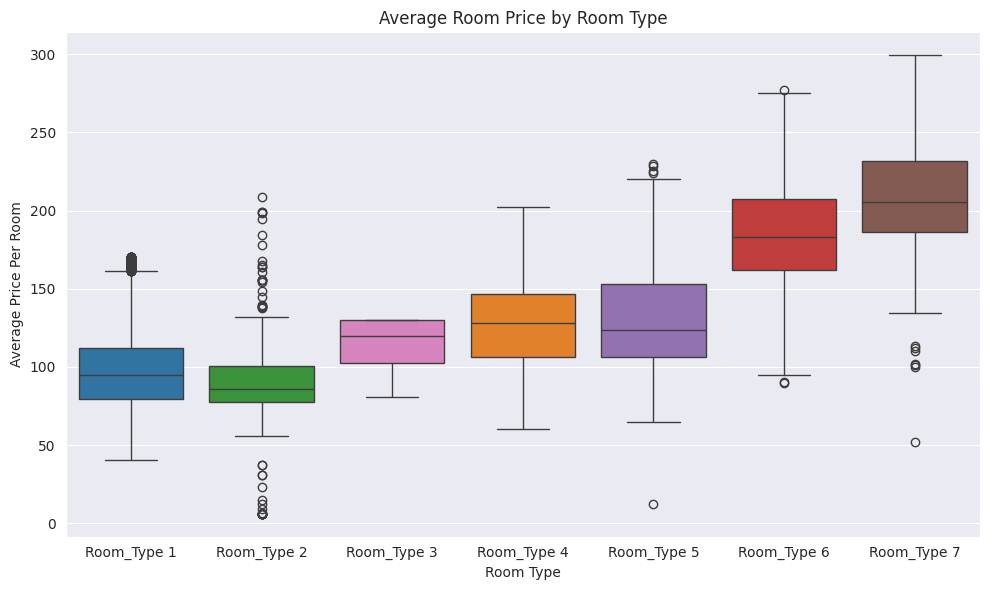

In [28]:
#redo boxplots to view changes
#show average room price by room type
print(data2.groupby('room_type_reserved')['avg_price_per_room'].mean())
plt.figure(figsize=(10, 6))
# Define the desired order for room types
room_type_order = ['Room_Type 1', 'Room_Type 2', 'Room_Type 3', 'Room_Type 4', 'Room_Type 5', 'Room_Type 6', 'Room_Type 7']
ax = sns.boxplot(data=data2, x='room_type_reserved', y='avg_price_per_room', hue='room_type_reserved', legend=False, palette='tab10', order=room_type_order)
plt.title('Average Room Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price Per Room')
plt.tight_layout()
plt.show()

###Observations on Outliers
While outliers still remain in almost every numeric variable, this is acceptable since most variables are skewed rather than normal.  Additionally, the price trimming ensures that all outliers are now within "reasonable" ranges.  Looking at how the dropped data affected the average price per room, we can see that in most cases, the average price stays within €1 of the price before dropping the outliers.  The only exception to this is Room_Type_3, but there were only 5 observations of that room type to begin with. Since all remaining outliers are within reasonable expectations, no further analysis is warranted.

###Feature Engineering

While this will not be used in the regression model and tree diagram, creating a data frame with a timedate field will help in EDA.

In [29]:
#transform the three date fields into a single field that can be used for time series
data3 = data2.copy()
data3["Check_in_date"] = (data3["arrival_date"].astype(str) + "-" + data3["arrival_month"].astype(str) + "-" + data3["arrival_year"].astype(str))

#my first attempt produced errors, so I am adding the errors="coerce" to override that
data3["Check_in_date"] = pd.to_datetime(data3["Check_in_date"], format="%d-%m-%Y", errors='coerce')

#count number of invalid dates
data3["Check_in_date"].isnull().sum()

np.int64(36)

In [30]:
#exploring why there are invalid dates
nan_rows = data3[data3["Check_in_date"].isna()].index.tolist()
print(nan_rows)
invalid_dates = data3.loc[nan_rows].copy()
display(invalid_dates)

[2549, 3559, 5425, 6152, 7422, 7766, 8730, 8891, 8979, 9387, 9646, 10284, 10341, 10433, 11534, 13892, 14908, 14982, 16698, 17842, 17993, 18137, 18461, 19825, 21038, 21052, 25324, 26724, 27085, 29633, 29695, 29710, 29914, 31087, 33593, 34408]


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,Check_in_date
2549,2,0,1,5,Meal Plan 1,0,Room_Type 1,104,2018,2,29,Online,1,1,0,61.43,0,1,NaT
3559,1,0,1,3,Meal Plan 1,0,Room_Type 1,21,2018,2,29,Online,0,0,0,102.05,0,1,NaT
5425,2,0,1,3,Meal Plan 1,0,Room_Type 1,24,2018,2,29,Offline,0,0,0,45.50,0,0,NaT
6152,1,0,1,1,Meal Plan 1,0,Room_Type 1,117,2018,2,29,Offline,0,0,0,76.00,0,0,NaT
7422,2,1,1,5,Meal Plan 1,0,Room_Type 1,35,2018,2,29,Online,0,0,0,98.10,1,1,NaT
7766,2,2,1,3,Meal Plan 1,0,Room_Type 6,3,2018,2,29,Online,0,0,0,183.00,1,0,NaT
8730,1,0,1,2,Meal Plan 1,0,Room_Type 1,117,2018,2,29,Offline,0,0,0,76.00,0,0,NaT
8891,2,2,1,3,Meal Plan 1,0,Room_Type 6,3,2018,2,29,Online,0,0,0,189.75,0,0,NaT
8979,2,0,1,3,Meal Plan 1,0,Room_Type 4,15,2018,2,29,Online,0,0,0,85.55,1,0,NaT
9387,1,0,1,0,Meal Plan 1,0,Room_Type 4,21,2018,2,29,Online,0,0,0,117.00,0,0,NaT


In [31]:
37/36275 *100

0.1019986216402481

###Observation on Invalid Dates
The invalid dates are all the same issue: they are coded as Feb 29th but 2018 was not a leap year (leap years are divisible by 4).

Looking at the number of reservations on the previous and following dates (Feb 28 and Mar 01) it is impossible to tell whether this was a typo. Thus, imputation of the date to either Feb 28 or Mar 01 would be an arbitrary choice on my part. Since 37 observations is around 0.1% of the data set, I feel comfortable dropping these rows.

In [32]:
data4 = data3.copy()
data4.drop(nan_rows, inplace=True, axis=0)
data4.reset_index(drop=True, inplace=True)
data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35139 entries, 0 to 35138
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          35139 non-null  int64         
 1   no_of_children                        35139 non-null  int64         
 2   no_of_weekend_nights                  35139 non-null  int64         
 3   no_of_week_nights                     35139 non-null  int64         
 4   type_of_meal_plan                     35139 non-null  object        
 5   required_car_parking_space            35139 non-null  int64         
 6   room_type_reserved                    35139 non-null  object        
 7   lead_time                             35139 non-null  int64         
 8   arrival_year                          35139 non-null  int64         
 9   arrival_month                         35139 non-null  int64         
 10

In [33]:
#use the date time to pull the day of the week as a variable and add it to dataframe
data4['arrival_day_of_week'] = data4['Check_in_date'].dt.day_name()
data4.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,Check_in_date,arrival_day_of_week
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,0,2017-10-02,Monday
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,0,2018-11-06,Tuesday
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,1,2018-02-28,Wednesday
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,1,2018-05-20,Sunday
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,1,2018-04-11,Wednesday


In [34]:
data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35139 entries, 0 to 35138
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          35139 non-null  int64         
 1   no_of_children                        35139 non-null  int64         
 2   no_of_weekend_nights                  35139 non-null  int64         
 3   no_of_week_nights                     35139 non-null  int64         
 4   type_of_meal_plan                     35139 non-null  object        
 5   required_car_parking_space            35139 non-null  int64         
 6   room_type_reserved                    35139 non-null  object        
 7   lead_time                             35139 non-null  int64         
 8   arrival_year                          35139 non-null  int64         
 9   arrival_month                         35139 non-null  int64         
 10

Families who travel together may also be an imporant indicator for cancellations.  While the family size did not appear to affect booking status (see appendix), I still believe it is worth adding a variable called Family with values of 0 for only adults and values of 1 for a party of both adults and children.  While this variable will miss adult couples, the importance of this feature will be to see whether a group of a adults and children differentiate booking status.

In [35]:
# Create the 'family_trip' variable
data4['family_trip'] = 0  # Initialize with 0 for guests without children
data4.loc[(data4['no_of_adults'] >= 1) & (data4['no_of_children'] >= 1), 'family_trip'] = 1

# Display the head of data4 with the new column
data4["family_trip"].value_counts()

,count
family_trip,
0,32705
1,2434


In [36]:
# data4 will be used in the appendix so I can perform time series analysis
# data5 will drop this new column so that I can continue feature engineering
data5 = data4.copy()
data5.drop("Check_in_date", axis=1, inplace=True)



In [37]:
#summarize the number of each value in teh arrival_year column
print(data5["arrival_year"].value_counts())
#I will drop check in year since I will assume similar year over year performance
#Additionally, the incomplete year (2017) may lead to a coefficient appearing significant when in reality it
# is an artifact of our data range
data5.drop("arrival_year", axis=1, inplace=True)
data5.head()

arrival_year
2018    28995
2017     6144
Name: count, dtype: int64


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_day_of_week,family_trip
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,10,2,Offline,0,0,0,65.00,0,0,Monday,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,11,6,Online,0,0,0,106.68,1,0,Tuesday,0
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2,28,Online,0,0,0,60.00,0,1,Wednesday,0
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,5,20,Online,0,0,0,100.00,0,1,Sunday,0
4,2,0,1,1,Not Selected,0,Room_Type 1,48,4,11,Online,0,0,0,94.50,0,1,Wednesday,0


## EDA

- It is a good idea to explore the data once again after manipulating it.

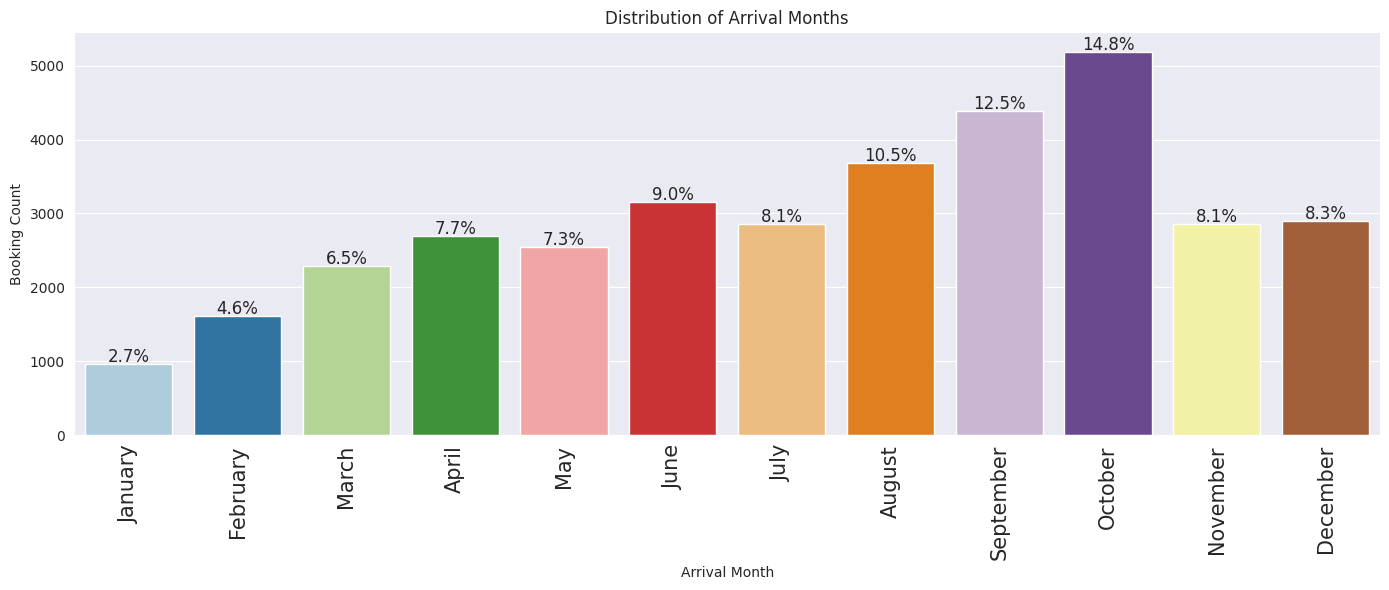


The three busiest months comprise 37.8 % of bookings.
The three slowest months comprise 13.8 % of bookings.


In [38]:
plt.figure(figsize=(len(months) + 2, 6))

# Get unique month numbers, sorted to ensure chronological order
month_order = sorted(data5['arrival_month'].unique())

ax = sns.countplot(
    data=data5,
    x='arrival_month',
    hue='arrival_month',
    palette="Paired",
    order=month_order,
    legend=False
)

# Set the x-tick labels to month names
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=90, fontsize=15)

# Add percentage annotations
total_bookings = len(data5)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        label = "{:.1f}%".format(100 * height / total_bookings)
        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.xlabel("Arrival Month")
plt.ylabel("Booking Count")
plt.title("Distribution of Arrival Months")
plt.tight_layout()
plt.show()

print("="*150,"\n")
print("The three busiest months comprise", 10.5+12.5+14.8,"% of bookings.")
print("The three slowest months comprise", round(2.7+4.6+6.5, 1),"% of bookings.")

###Observations
As expected, there is a 0.1% drop in the amount of data in February, but the overall trends are unchanged.  There are other small percentage dips but they appear to be spread fairly evenly across the months.

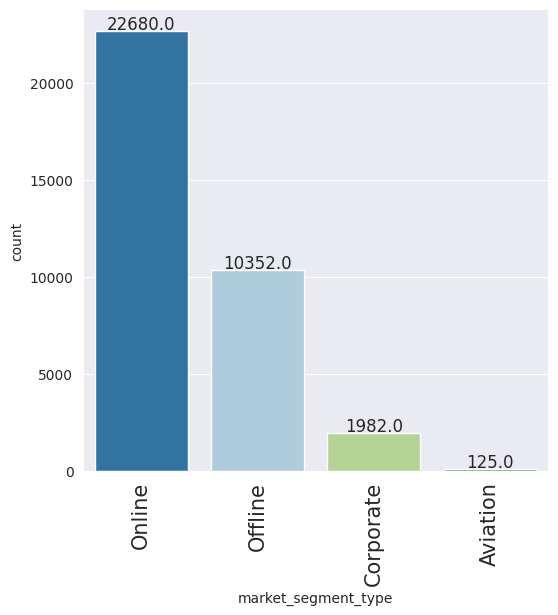

Table of market segment types as a percentage:
market_segment_type
Online       64.54
Offline      29.46
Corporate     5.64
Aviation      0.36
Name: proportion, dtype: float64


In [39]:
#bargraph showing the market segments
labeled_barplot(data5, 'market_segment_type')
print("Table of market segment types as a percentage:")
print(round(data5['market_segment_type'].value_counts(normalize=True) * 100, 2))

market_segment_type
Aviation     100.704000
Corporate     83.160747
Offline       91.174419
Online       112.358906
Name: avg_price_per_room, dtype: float64




Market segment type: Online


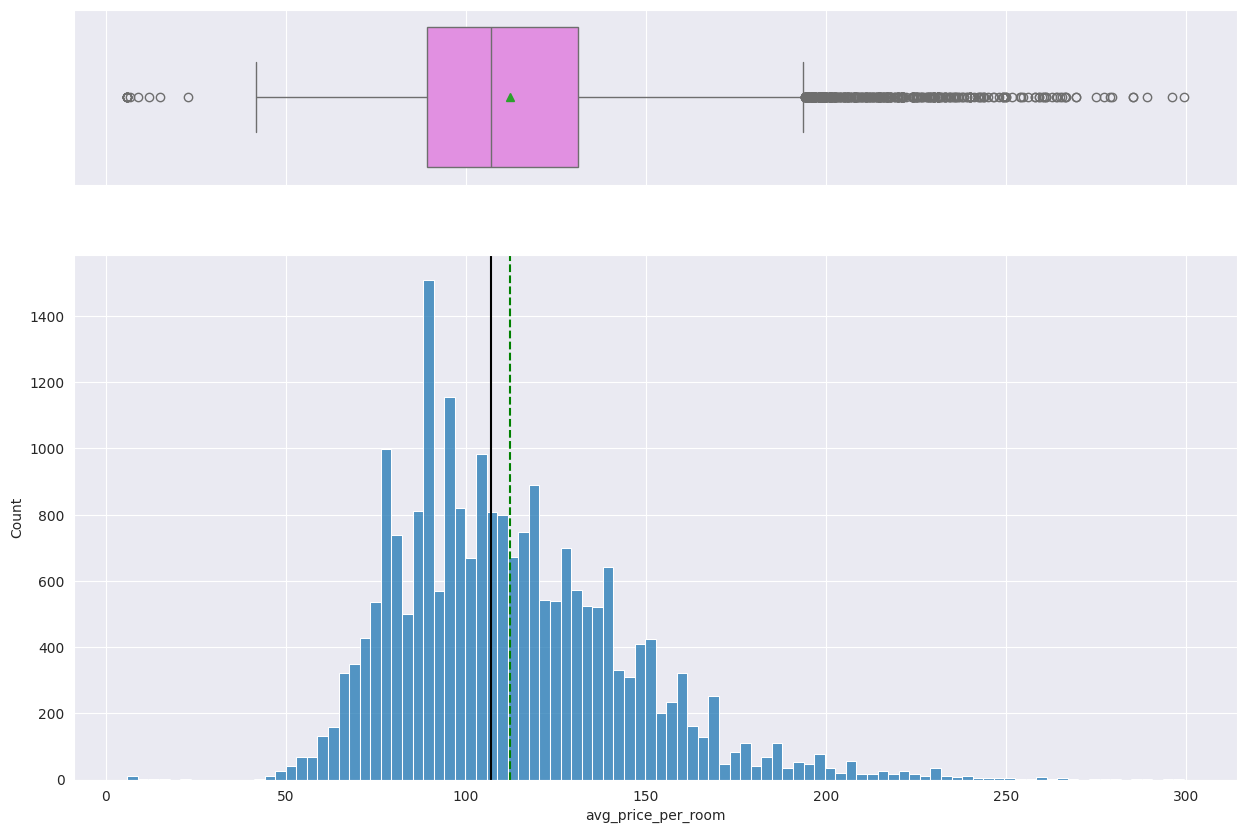





Market segment type: Offline


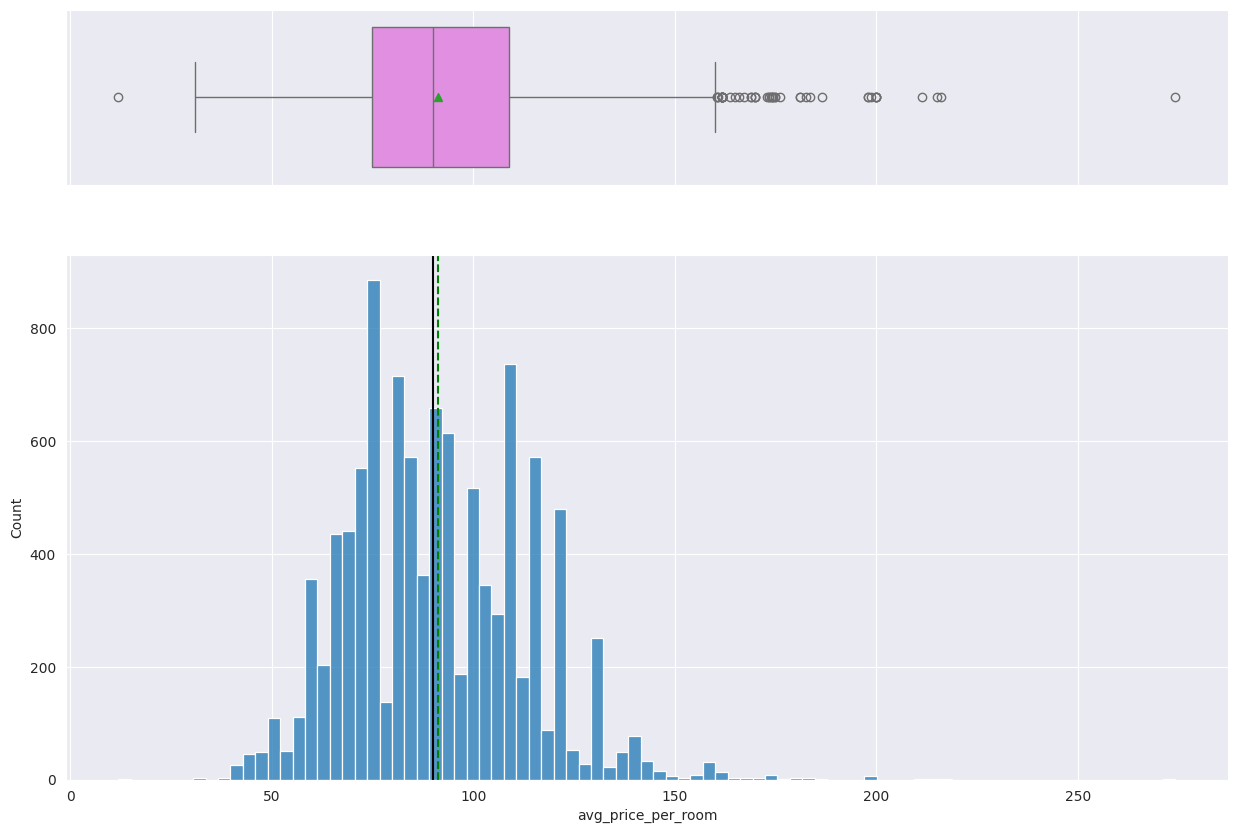





Market segment type: Corporate


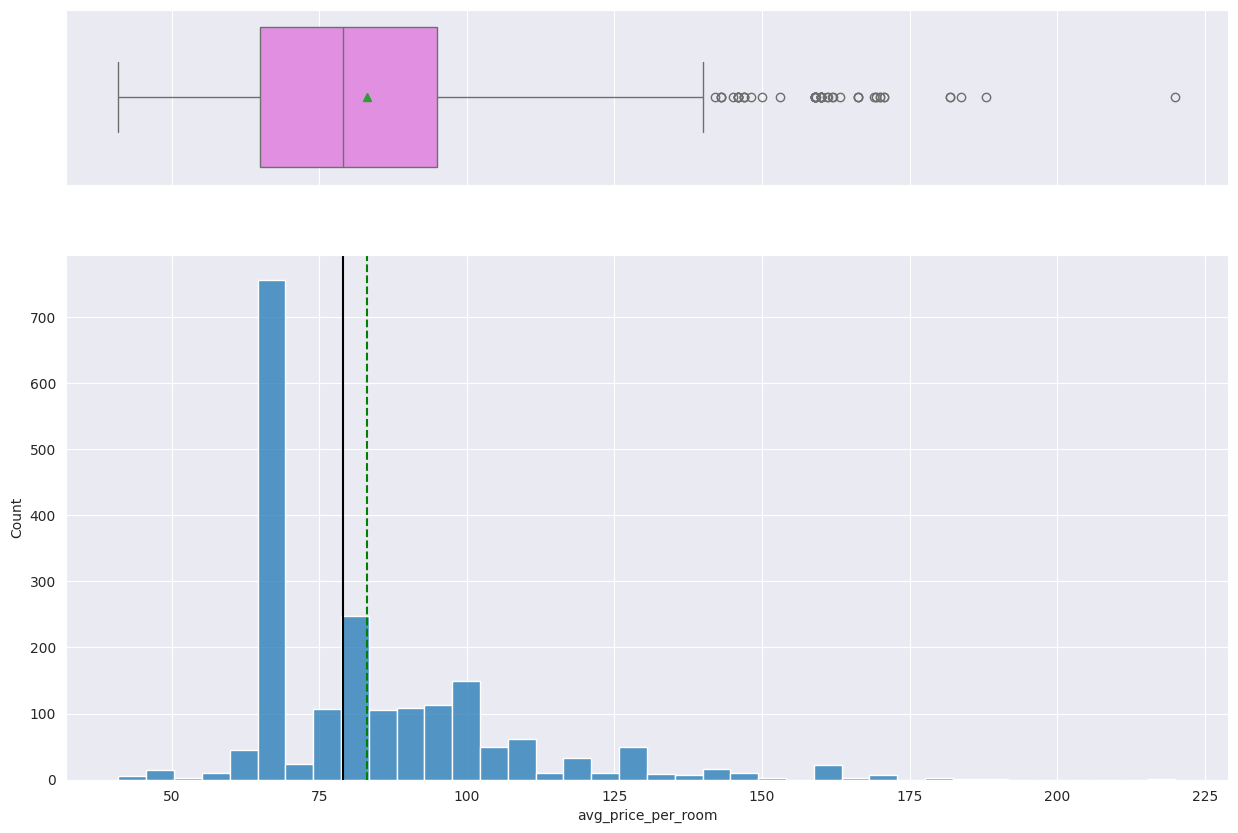





Market segment type: Aviation


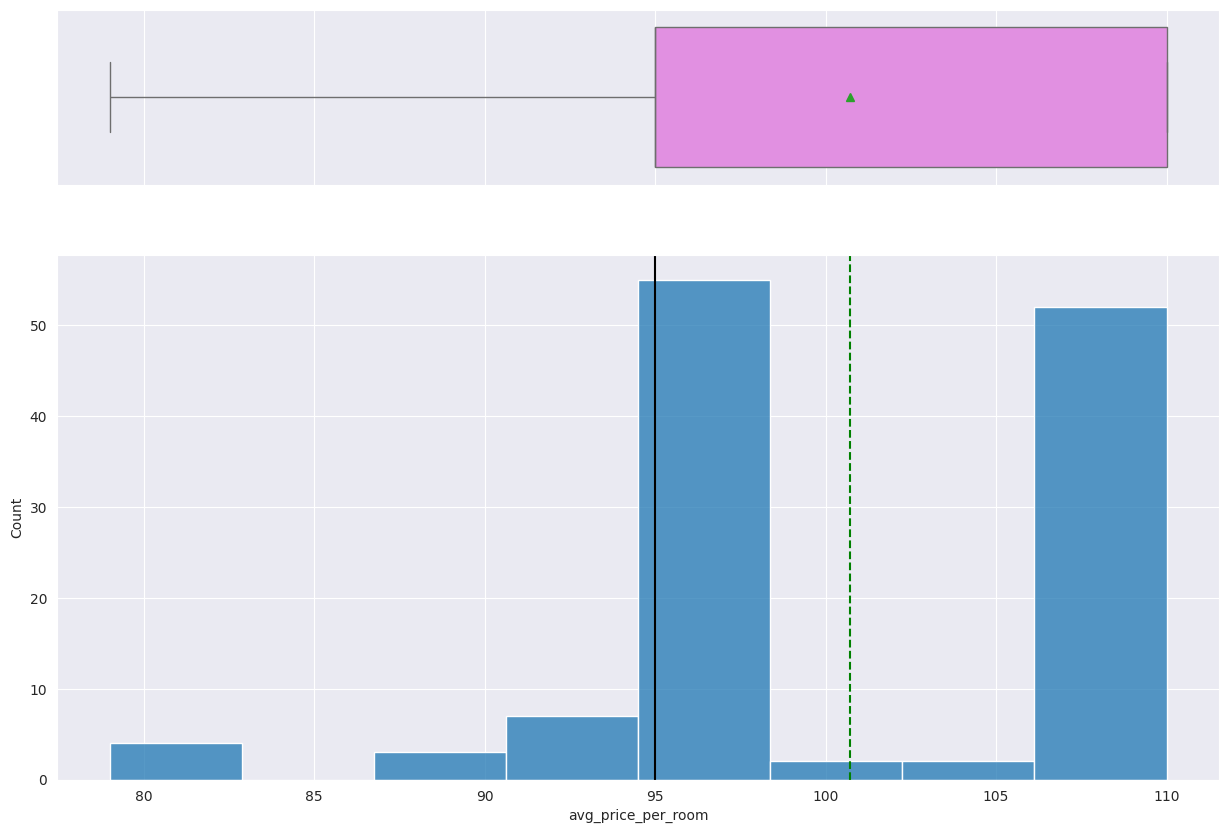





market_segment_type    Aviation    Corporate       Offline        Online
count                125.000000  1982.000000  10352.000000  22680.000000
mean                 100.704000    83.160747     91.174419    112.358906
std                    8.538361    22.609654     22.013317     32.198522
min                   79.000000    41.000000     12.000000      6.000000
25%                   95.000000    65.000000     75.000000     89.100000
50%                   95.000000    79.000000     90.000000    107.100000
75%                  110.000000    95.000000    109.000000    131.000000
max                  110.000000   220.000000    274.200000    299.330000


In [40]:
#room prices by market_segment
print(data5.groupby('market_segment_type')['avg_price_per_room'].mean())
print("\n\n", "="*150,"\n\n")

#boxplot_histograms of room price by market segment
market_segment_order = ['Online', 'Offline', 'Corporate', 'Aviation']
for market_type in market_segment_order:
  print("Market segment type:", market_type)
  # Filter the data for the current market_type
  filtered_data = data5[data5['market_segment_type'] == market_type]
  # Call histogram_boxplot with the filtered data and the correct feature name
  histogram_boxplot(filtered_data, 'avg_price_per_room')
  plt.show()
  print("\n\n", "="*150,"\n\n")

print(data5.groupby('market_segment_type')['avg_price_per_room'].describe().T)

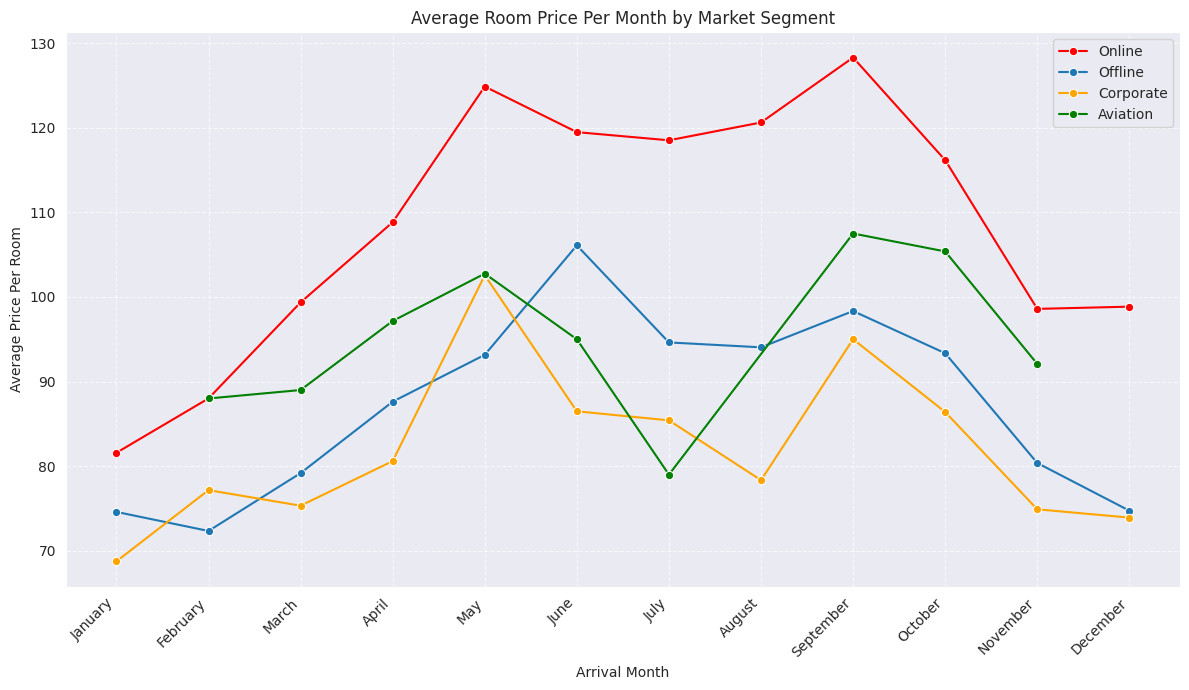

In [41]:
#create a time series of average room price by month, grouped by market segment

# Group by arrival_month and repeated_guest, then calculate the mean of avg_price_per_room
price_by_month_market = data5.groupby(['arrival_month', 'market_segment_type'])['avg_price_per_room'].mean().unstack()

# Plotting the time series
plt.figure(figsize=(12, 7))

# Plot for online
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market['Online'], marker='o', label='Online', color = "red")

# Plot for offline (repeated_guest = 1)
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Offline"], marker='o', label='Offline')

# Plot for corporate
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Corporate"], marker='o', label='Corporate', color = "orange")

# Plot for aviation
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Aviation"], marker='o', label='Aviation', color = "green")

plt.title('Average Room Price Per Month by Market Segment')
plt.xlabel('Arrival Month')
plt.ylabel('Average Price Per Room')

# Use the 'months' list defined earlier for x-axis labels
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xticks(ticks=range(1, 13), labels=months, rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Percentage of bookings that were cancelled
booking_status
0    66.58
1    33.42
Name: proportion, dtype: float64




Percentage of booking cancellations for repeated guests:
booking_status      0      1
repeated_guest              
0               65.86  34.14
1               98.08   1.92


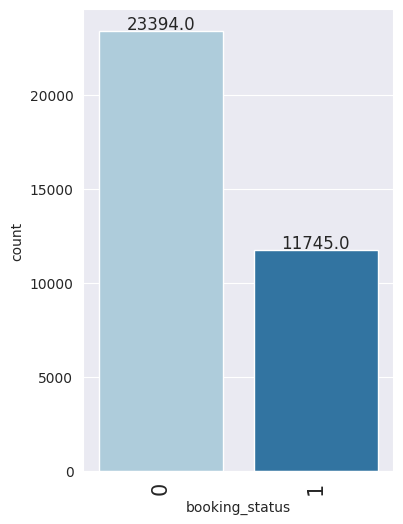

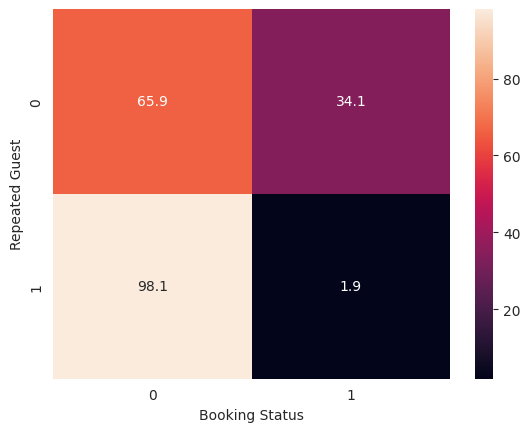

In [42]:
#show the overall percentage of bookings that were cancelled
print("Percentage of bookings that were cancelled")
cancelled_bookings = data5['booking_status'].value_counts(normalize=True) * 100
print(round(cancelled_bookings, 2))

#show the conditional proportion (as a %) of booking_status | repeated_guests
print("\n\n", "="*150,"\n\n")
print("Percentage of booking cancellations for repeated guests:")
rep_guests_cancellations = pd.crosstab(data5['repeated_guest'], data5['booking_status'], normalize='index') * 100
print(round(rep_guests_cancellations, 2))

#bargraph of cancelled reservations
labeled_barplot(data5, 'booking_status')

#heatmap of booking cancellations for repeated_guest
sns.heatmap(rep_guests_cancellations, annot = True, fmt=".1f") # Corrected: annot=True to show data values, added fmt
plt.ylabel("Repeated Guest") # Corrected: use plt instead of plot
plt.xlabel("Booking Status") # Corrected: use plt instead of plot
plt.show() # Added to ensure plot displays



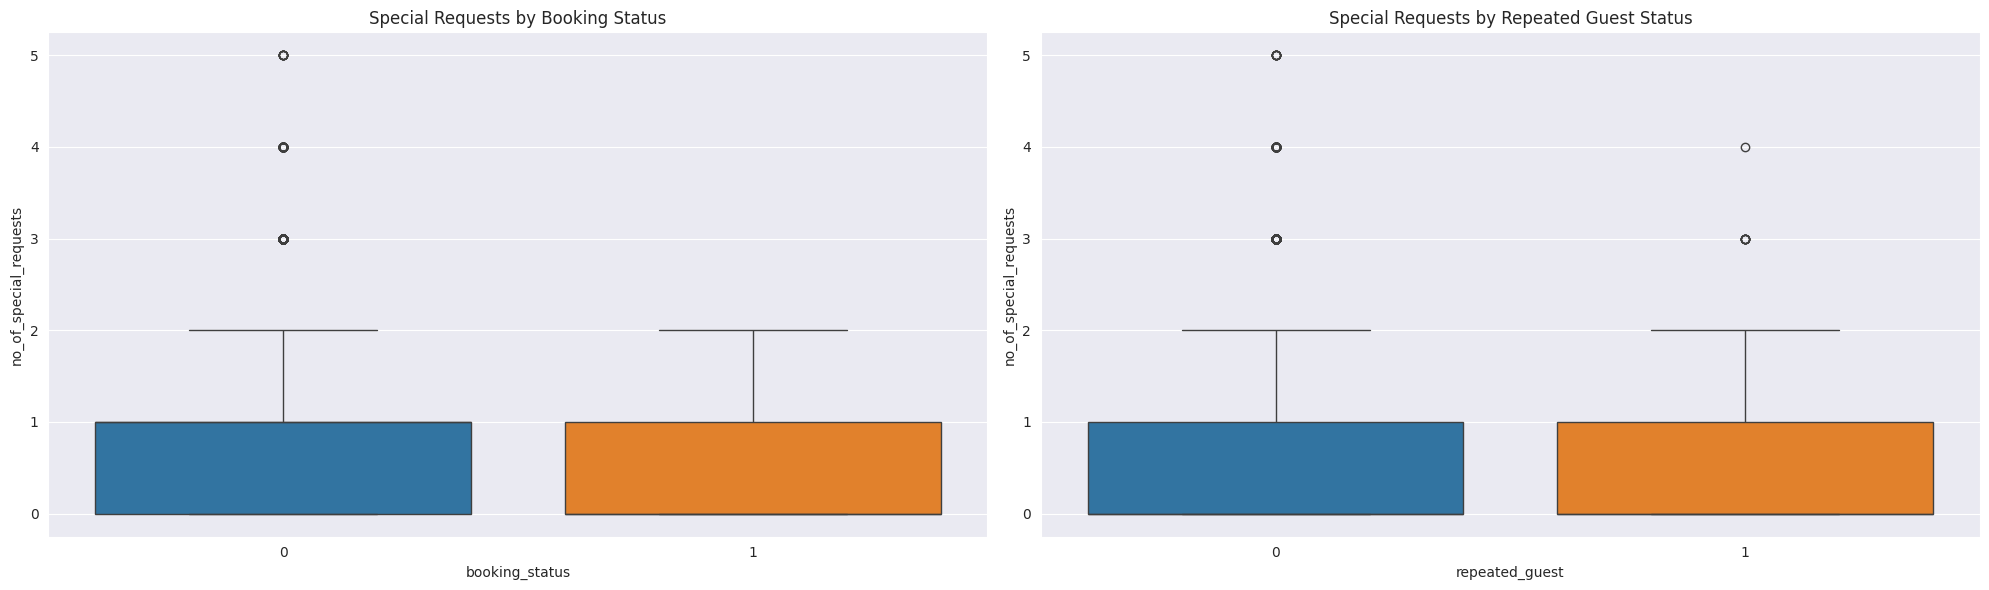





Number of special requests by booking status:
booking_status              0     1
no_of_special_requests             
0                       10766  8434
1                        8348  2683
2                        3561   628
3                         646     0
4                          65     0
5                           8     0




Percentage of special requests by booking status:
booking_status               0      1
no_of_special_requests               
0                        56.07  43.93
1                        75.68  24.32
2                        85.01  14.99
3                       100.00   0.00
4                       100.00   0.00
5                       100.00   0.00




Number of special requests by repeated guest status:
repeated_guest              0    1
no_of_special_requests            
0                       18701  499
1                       10791  240
2                        4154   35
3                         639    7
4                          64    1
5 

In [43]:
#boxplot for number of special requests grouped by booking_status and repeated_guest status on a single grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# Boxplot for number of special requests grouped by booking_status
sns.boxplot(data=data5, x='booking_status', y='no_of_special_requests', hue='booking_status', legend=False, palette='tab10', ax=axes[0])
axes[0].set_title('Special Requests by Booking Status')

# Boxplot for number of special requests grouped by repeated_guest status
sns.boxplot(data=data5, x='repeated_guest', y='no_of_special_requests', hue='repeated_guest', legend=False, palette='tab10', ax=axes[1])
axes[1].set_title('Special Requests by Repeated Guest Status')

plt.tight_layout()
plt.show()

#display table of number of special requests by booking status
print("\n\n", "="*150,"\n\n")
req_status = pd.crosstab(data5['no_of_special_requests'], data5['booking_status'])
print("Number of special requests by booking status:")
print(req_status)

#display same table with row normalization
print("\n\n", "="*150,"\n\n")
print("Percentage of special requests by booking status:")
print(round(req_status.div(req_status.sum(axis=1), axis=0) * 100, 2))


#display table with number of special request by repeat customer status
print("\n\n", "="*150,"\n\n")
req_repeat = pd.crosstab(data5['no_of_special_requests'], data5['repeated_guest'])
print("Number of special requests by repeated guest status:")
print(req_repeat)

#same table with column normalization
print("\n\n", "="*150,"\n\n")
print("Percentage of special requests by repeated guest status:")
print(round(req_repeat.div(req_repeat.sum(axis=0), axis=1) * 100, 2))


###Observations on EDA after processing
There are no significant changes to any of the visualizations.  The removal of the 37 invalid dates does not appear to have a significant impact on the data.

## Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

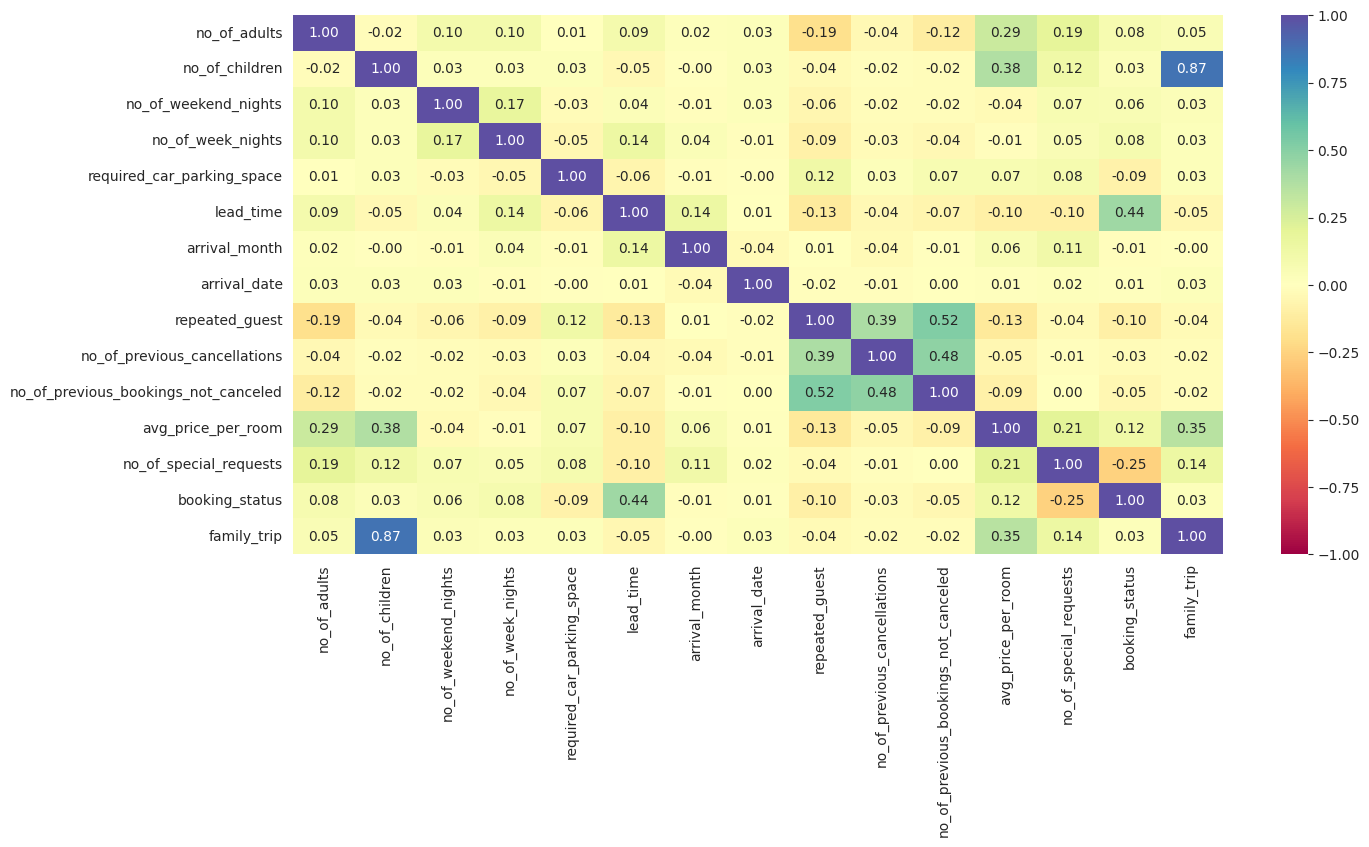

In [44]:
#correlation matrix for numeric values
plt.figure(figsize=(15, 7))
sns.heatmap(data5.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

###Observations on Correlation
Most of the variables are not correlated; however there is a weak correlation between the average price per room and the number of adults and the price with the number of children.  This is a logical correlation since more people usually get charged a higher price.  There is also a moderate positive correlation between lead time and booking status.  Reservations with a greater lead time are correlated with a higher number of cancellations.  Once the model is created I will check the Variable Inflation Factor (VIF); however, at this juncture I am not worried about too much multicolinearity.

## Building a Logistic Regression model

In [45]:
# specifying the independent  and dependent variables
X = data5.drop(["booking_status"], axis=1)
Y = data5["booking_status"]

# adding a constant to the independent variables
X = sm.add_constant(X)

# creating dummy variables
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=1)

In [46]:
#checking the proportion of independent values in the training and test split
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

booking_status
0    0.667195
1    0.332805
Name: proportion, dtype: float64
booking_status
0    0.662398
1    0.337602
Name: proportion, dtype: float64


###Observations on Training Data
The split is fairly similar for both the training and test data.

In [47]:
# fitting logistic regression model
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit(disp=False)

print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                24597
Model:                          Logit   Df Residuals:                    24565
Method:                           MLE   Df Model:                           31
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.3260
Time:                        22:25:35   Log-Likelihood:                -10546.
converged:                       True   LL-Null:                       -15647.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.6807      0.269     -9.965      0.000      -3.208      -2.153
no_of_adults                             0.0305      

###Observations on Initial Model
Observations

* Negative values of the coefficient show that the probability of a person canceling a reservation decreases with the increase of the corresponding attribute value.

* Positive values of the coefficient show that the probability of a person cancelling a reservation increases with the increase of the corresponding attribute value.

* p-value of a variable indicates if the variable is significant or not. If we consider the significance level to be 0.05 (5%), then any variable with a p-value less than 0.05 would be considered significant.

* The initial model is not displaying a warning, indicating that it is already stable. This means that pre-processing was successful in reducing the amount of noise.

## Model performance evaluation

**Model can make wrong predictions as**:

1. Predicting a person will cancel the reservation but they won't (a false positive error).

2. Predicting a person will keep their reservation but they will cancel in reality (a false negative).

**Which case is more important?**

* Both the cases are important as:

  * If we predict a person will cancel their reservation and either deny them a room or charge them some sort of deposit fee, the hotel may lose brand equity.

  * If we predict a person will keep their reservation but they cancel, then the hotel chain loses resources and my end up with unrented rooms and lost revenue.


**How to reduce this loss?**

* We need to reduce both False Negatives and False Positives

* `f1_score` should be maximized as the greater the f1_score, the higher the chances of reducing both False Negatives and False Positives and identifying both the classes correctly
  * fi_score is computed as
  $$f1\_score = \frac{2 * Precision * Recall}{Precision + Recall}$$

###Custom Functions for model evaluation
These are taken from the course MLS file.

**First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.**

* The model_performance_classification_statsmodels function will be used to check the model performance of models.
* The confusion_matrix_statsmodels function will be used to plot confusion matrix.

In [48]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

  # defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

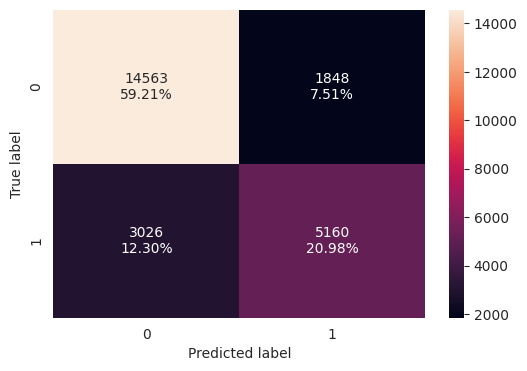




Training performance:


,Accuracy,Recall,Precision,F1
0,0.801846,0.630344,0.736301,0.679215


In [49]:
confusion_matrix_statsmodels(lg, X_train, y_train)
plt.show()
print("\n\n","="*150, "\n\nTraining performance:")
model_performance_classification_statsmodels(lg, X_train, y_train)

###Observations
Currently the model has a high number of False Positives and False Negatives (4874) with an F1 score of 67.922%.

###Multicolinearity Check

In [50]:
#Check for Multicolinearity
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)

# Set display options for pandas to suppress scientific notation and set precision
with pd.option_context('display.float_format', '{:.4f}'.format):
    print("Series before feature selection: \n\n{}\n".format(vif_series))

Series before feature selection: 

const                                  319.5396
no_of_adults                             1.3760
no_of_children                           6.9365
no_of_weekend_nights                     1.9590
no_of_week_nights                        1.4593
required_car_parking_space               1.0398
lead_time                                1.2608
arrival_month                            1.0566
arrival_date                             1.0098
repeated_guest                           1.7612
no_of_previous_cancellations             1.3493
no_of_previous_bookings_not_canceled     1.5901
avg_price_per_room                       2.0061
no_of_special_requests                   1.2573
family_trip                              5.0177
type_of_meal_plan_Meal Plan 2            1.2548
type_of_meal_plan_Not Selected           1.2593
room_type_reserved_Room_Type 2           1.2087
room_type_reserved_Room_Type 3           1.0008
room_type_reserved_Room_Type 4           1.4248
room_

###Observations on VIF
As expected, the creation of the family_trip variable has created multicolinearity with the no_of_children variable. Since the no_of_children has a higher VIF score, we will drop that and rerun the VIF.

In [51]:
#drop the no_of_children variable and rerun the VIF
X_train1 = X_train.drop("no_of_children", axis=1)
X_test1 = X_test.drop("no_of_children", axis=1)

#Check for Multicolinearity
vif_series = pd.Series(
    [variance_inflation_factor(X_train1.values, i) for i in range(X_train1.shape[1])],
    index=X_train1.columns,
    dtype=float,
)

# Set display options for pandas to suppress scientific notation and set precision
with pd.option_context('display.float_format', '{:.4f}'.format):
    print("Series before feature selection: \n\n{}\n".format(vif_series))

Series before feature selection: 

const                                  319.4933
no_of_adults                             1.3218
no_of_weekend_nights                     1.9585
no_of_week_nights                        1.4592
required_car_parking_space               1.0397
lead_time                                1.2605
arrival_month                            1.0566
arrival_date                             1.0098
repeated_guest                           1.7611
no_of_previous_cancellations             1.3492
no_of_previous_bookings_not_canceled     1.5901
avg_price_per_room                       2.0049
no_of_special_requests                   1.2572
family_trip                              1.4831
type_of_meal_plan_Meal Plan 2            1.2547
type_of_meal_plan_Not Selected           1.2590
room_type_reserved_Room_Type 2           1.0411
room_type_reserved_Room_Type 3           1.0008
room_type_reserved_Room_Type 4           1.4210
room_type_reserved_Room_Type 5           1.0319
room_

There are no further VIF greater than 5, so I will proceed with the analysis.

###Dropping insignificant p-values

Now I will be dropping all variables with a p-value >0.05.  This will be done one by one with the model being rerun each time to ensure that we have dropped the minimum number of values.

In [52]:
def dropping_p(x_training_data, y_training_data):

  # initial list of columns
  cols = x_training_data.columns.tolist()
  # setting an initial max p-value
  max_p_value = 1

  while len(cols) > 0:
    # defining the train set
    train_aux = x_training_data[cols]

    # fitting the model
    model = sm.Logit(y_training_data, train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

  selected_features = cols
  return selected_features

In [53]:
cols_to_keep = dropping_p(X_train1, y_train)
X_train2 = X_train1[cols_to_keep]
X_test2 = X_test1[cols_to_keep]

In [54]:
logit1 = sm.Logit(y_train, X_train2)
lg1 = logit1.fit(disp=False)

print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                24597
Model:                          Logit   Df Residuals:                    24577
Method:                           MLE   Df Model:                           19
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.3256
Time:                        22:25:47   Log-Likelihood:                -10553.
converged:                       True   LL-Null:                       -15647.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.9024      0.103    -28.208      0.000      -3.104      -2.701
no_of_weekend_nights               0.1358      0.021      6.575      0.

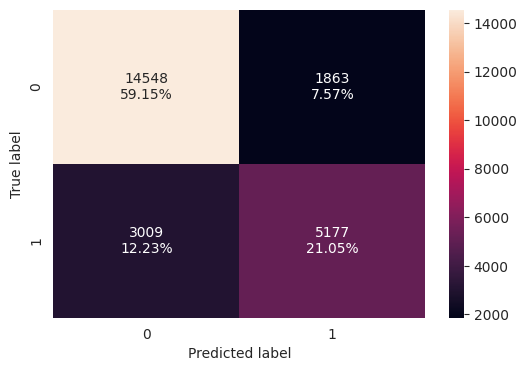




Training performance:


,Accuracy,Recall,Precision,F1
0,0.801927,0.632421,0.735369,0.680021


In [55]:
confusion_matrix_statsmodels(lg1, X_train2, y_train)
plt.show()
print("\n\n","="*150, "\n\nTraining performance:")
log_reg_model_train = model_performance_classification_statsmodels(lg1, X_train2, y_train)
log_reg_model_train

###Observations after dropping insignficant p-values
Overall the reduced model has a very slight gain in F1 from 0.679 to 0.680.  There is a small change in false positives from 7.51% to 7.57% and a small drop in false negatives from 12.23 to 12.30%.

###Converting coefficients to odds


In [56]:
# converting coefficients to odds
odds = np.exp(lg1.params)

# finding the percentage change
perc_change_odds = (np.exp(lg1.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe and transposing it
df_odds = pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train2.columns)

# Use option_context to temporarily set display format for better readability
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(df_odds)

                                 Odds  Change_odd%
const                          0.0549     -94.5111
no_of_weekend_nights           1.1455      14.5476
no_of_week_nights              1.0436       4.3567
required_car_parking_space     0.1916     -80.8442
lead_time                      1.0163       1.6320
arrival_month                  0.9461      -5.3879
repeated_guest                 0.0472     -95.2821
no_of_previous_cancellations   1.2685      26.8490
avg_price_per_room             1.0223       2.2343
no_of_special_requests         0.2283     -77.1670
type_of_meal_plan_Not Selected 1.3446      34.4640
room_type_reserved_Room_Type 2 0.6817     -31.8325
room_type_reserved_Room_Type 4 0.7596     -24.0359
room_type_reserved_Room_Type 5 0.4189     -58.1068
room_type_reserved_Room_Type 6 0.3935     -60.6537
room_type_reserved_Room_Type 7 0.1895     -81.0494
market_segment_type_Corporate  0.3789     -62.1091
market_segment_type_Offline    0.1623     -83.7735
arrival_day_of_week_Monday     

###Interpreting the Odds
Overall, negative odds mean a lower chance of cancellation.  To interpret each of these, we assume that we keep all other factors the same, a one unit change in the variable below with change the odds of cancelling a reservation. According to our model, the y factors that **lower** the likelihood of a cancellation are:
* repeated_guests:                 -95.28%
* offline booking:                 -83.77%
* Room Type 7:                     -81.05%
* required parking space:          -80.84%
* number of special requests:      -77.17%
* corporate bookings:              -62.11%
* room_type_6:                     -60.65%
* room_type_5:                     -58.11%
* room_type_2:                     -31.83%
* room_type_4:                     -24.04%
* arrival_day_of_week_Saturday:    -21.80%
* arrival_day_of_week_Monday:      -11.31%

The three largest increases to the odds of cancelling a reservation, given a one unit change in that variable (and again assuming all other factors are held constant) are:

* meal_plan_not_selected:          34.46%
* no_of_previous_cancellations:    26.85%
* no_of_weekend_nights:            14.55%

The remaining variables not explicitly mentioned all increase the odds of a reservation being cancelled, but all by less than 10% each.

### **ROC-AUC**

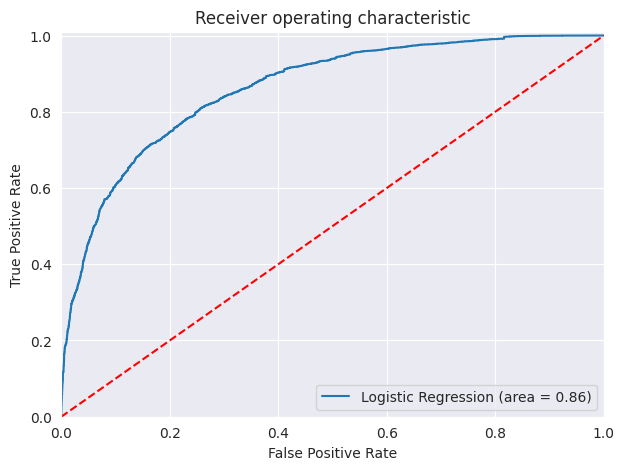

In [57]:
logit_roc_auc_train = roc_auc_score(y_train, lg1.predict(X_train2))
fpr, tpr, thresholds = roc_curve(y_train, lg1.predict(X_train2))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [58]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, lg1.predict(X_train2))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.29079897520501


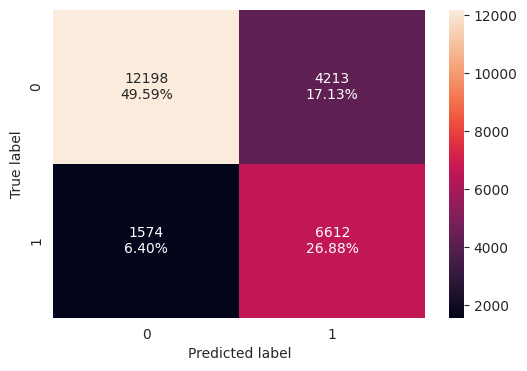




Training performance:


,Accuracy,Recall,Precision,F1
0,0.764727,0.80772,0.610808,0.695597


In [59]:
#review confusion matrix and model performance with optimal cutoff
confusion_matrix_statsmodels(lg1, X_train2, y_train, optimal_threshold_auc_roc)
plt.show()
print("\n\n","="*150, "\n\nTraining performance:")
log_reg_model_train_auc_roc = model_performance_classification_statsmodels(lg1, X_train2, y_train, optimal_threshold_auc_roc)
log_reg_model_train_auc_roc

### Observations on ROC-AUC

A threshold of 0.2908 maximize the area under the curve.  Accuracy dropped a little bit from 0.801 to 0.765 but there was a nice gain in F1 from 0.6800 to 0.6956.  Recall also improved significantly, but at the cost of precision.  However, since we are trying to maximize F1, the model is performing well.

###Precision-Recall curve


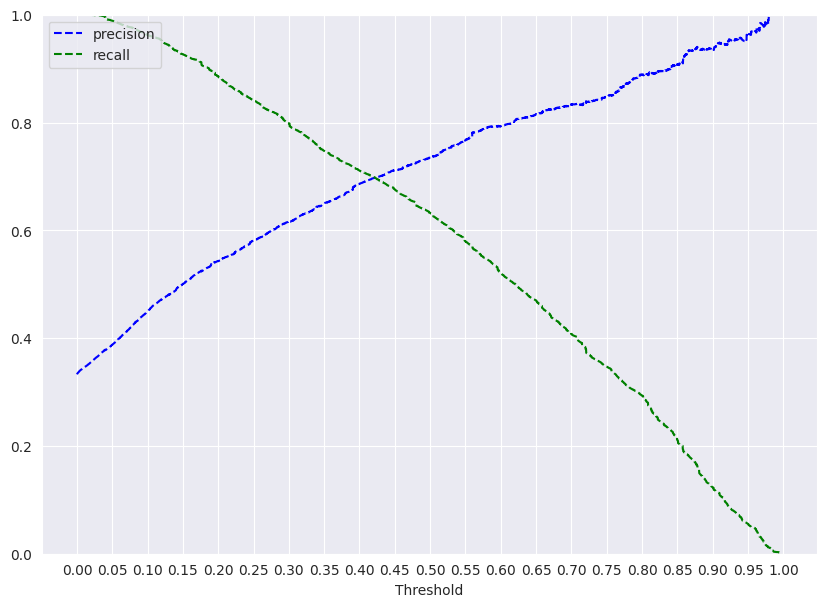

In [60]:
y_scores = lg1.predict(X_train2)
prec, rec, tre = precision_recall_curve(y_train, y_scores,)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
# Set x-axis tick marks at every 0.05 interval
plt.xticks(np.arange(0, 1.01, 0.05))
plt.show()

In [61]:
#calculate the intersection of the two curves
optimal_idx_pr_curve = np.argmin(np.abs(prec - rec))

#pull the index of the minimum difference from the threshold value array (tre)
optimal_threshold_pr_curve = tre[optimal_idx_pr_curve]
print(f"Optimal threshold from Precision-Recall curve (where precision and recall are closest): {optimal_threshold_pr_curve:.4f}")

Optimal threshold from Precision-Recall curve (where precision and recall are closest): 0.4221


In [62]:
# setting the threshold manually for replicability
optimal_threshold_curve = 0.4221

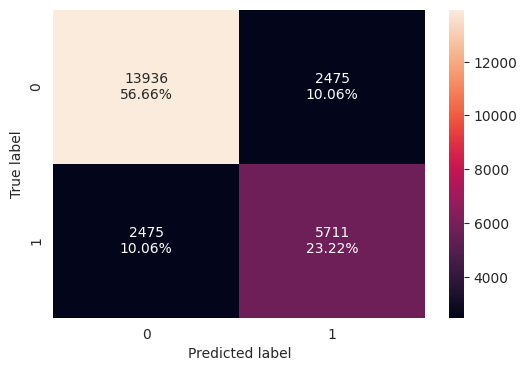




Training performance:


,Accuracy,Recall,Precision,F1
0,0.798756,0.697655,0.697655,0.697655


In [63]:
#evaluate model performance using Precision-Recall method
confusion_matrix_statsmodels(lg1, X_train2, y_train, optimal_threshold_curve)
plt.show()
print("\n\n","="*150, "\n\nTraining performance:")
log_reg_model_train_pre_rec = model_performance_classification_statsmodels(lg1, X_train2, y_train, optimal_threshold_curve)
log_reg_model_train_pre_rec

###Observations on Precision-Recall
This model evenly split the false positives and false negatives.  Accuracy has improved back to 0.7988, almost as high as the model after dropping insignificant p-values.  Additionally, we see another slight gain in the F1 value to 0.6976.  Thus, this model seems the most optimized for maximizing F1 while keeping the other values high.

##Checking the model on the test data

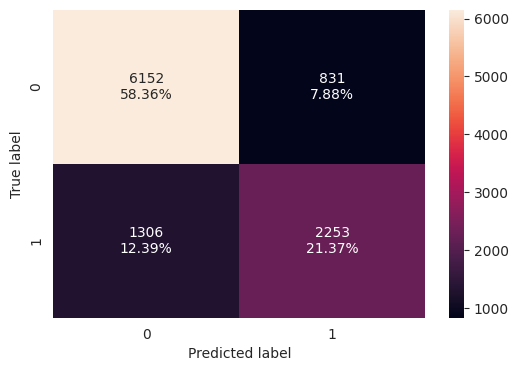




Test performance:


,Accuracy,Recall,Precision,F1
0,0.797287,0.633043,0.730545,0.678308


In [64]:
#basic model with test data
confusion_matrix_statsmodels(lg1, X_test2, y_test)
plt.show()
print("\n\n","="*150, "\n\nTest performance:")
log_reg_model_test = model_performance_classification_statsmodels(lg1, X_test2, y_test)
log_reg_model_test

###Observations on Test model
All test performance scores are similar to the training data.

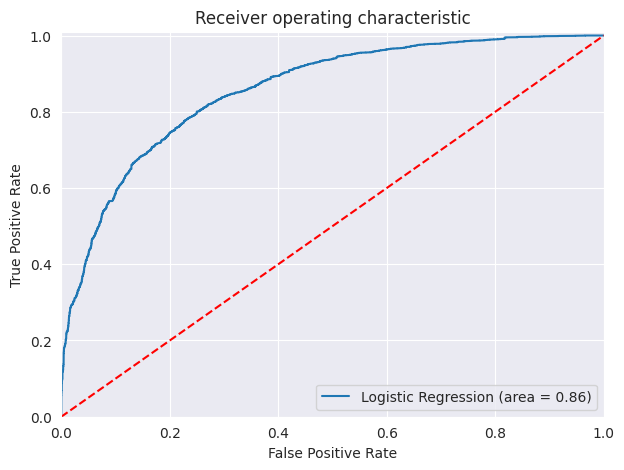

In [65]:
#evaluate model on test data using ROC-AUC method
logit_roc_auc_test = roc_auc_score(y_test, lg1.predict(X_test2))
fpr, tpr, thresholds = roc_curve(y_test, lg1.predict(X_test2))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

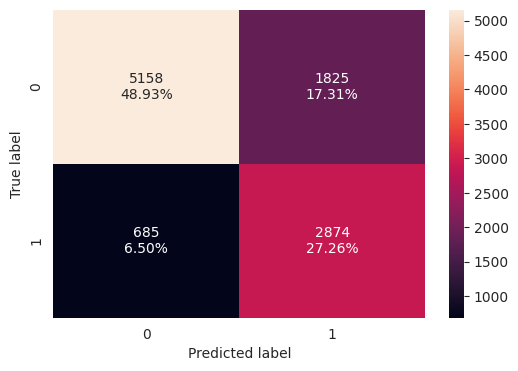




Test performance:


,Accuracy,Recall,Precision,F1
0,0.761905,0.80753,0.611619,0.696052


In [66]:
#test data wiht the ROC-AUC threshold
confusion_matrix_statsmodels(lg1, X_test2, y_test, optimal_threshold_auc_roc)
plt.show()
print("\n\n","="*150, "\n\nTest performance:")
log_reg_model_test_auc_roc = model_performance_classification_statsmodels(lg1, X_test2, y_test, optimal_threshold_auc_roc)
log_reg_model_test_auc_roc

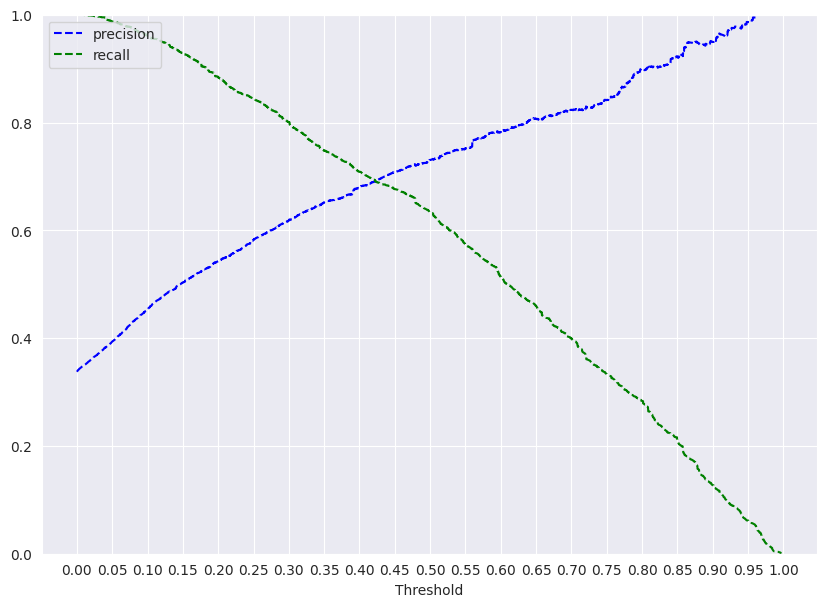

In [67]:
#Precision-Recall method on test data
y_scores = lg1.predict(X_test2)
prec, rec, tre = precision_recall_curve(y_test, y_scores,)

plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
# Set x-axis tick marks at every 0.05 interval
plt.xticks(np.arange(0, 1.01, 0.05))
plt.show()


In [68]:
#calculate exact threshold intersection value
optimal_idx_pr_curve = np.argmin(np.abs(prec - rec))
optimal_threshold_pr_curve = tre[optimal_idx_pr_curve]
print(f"Optimal threshold from Precision-Recall curve (where precision and recall are closest): {optimal_threshold_pr_curve:.4f}")

Optimal threshold from Precision-Recall curve (where precision and recall are closest): 0.4229


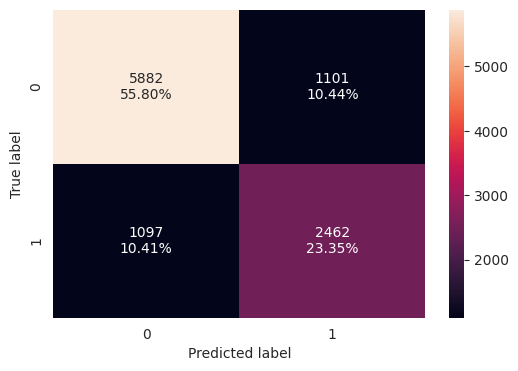




Test performance:


,Accuracy,Recall,Precision,F1
0,0.791501,0.691767,0.690991,0.691379


In [69]:
#test data performance using the Precision-Recall method
confusion_matrix_statsmodels(lg1, X_test2, y_test, optimal_threshold_curve)
plt.show()
print("\n\n","="*150, "\n\nTest performance:")
log_reg_model_test_pre_rec = model_performance_classification_statsmodels(lg1, X_test2, y_test, optimal_threshold_curve)
log_reg_model_test_pre_rec

###Observations on the Test Data models

All three models generated by the test data had very similar performances with the training data, suggesting that the final models were stable and reliable for prediction.  All the remains is a comparison and model selection.

## Final Model Summary

In [70]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train.T,
        log_reg_model_train_auc_roc.T,
        log_reg_model_train_pre_rec.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression-default Threshold",
    "Logistic Regression-0.2098 Threshold",
    "Logistic Regression-0.4221 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression-default Threshold,Logistic Regression-0.2098 Threshold,Logistic Regression-0.4221 Threshold
Accuracy,0.801927,0.764727,0.798756
Recall,0.632421,0.807720,0.697655
Precision,0.735369,0.610808,0.697655
F1,0.680021,0.695597,0.697655


In [71]:
# test performance comparison
models_test_comp_df = pd.concat(
    [
        log_reg_model_test.T,
        log_reg_model_test_auc_roc.T,
        log_reg_model_test_pre_rec.T,
        ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression-default Threshold",
    "Logistic Regression-0.2908 Threshold",
    "Logistic Regression-0.4221 Threshold",
]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Logistic Regression-default Threshold,Logistic Regression-0.2908 Threshold,Logistic Regression-0.4221 Threshold
Accuracy,0.797287,0.761905,0.791501
Recall,0.633043,0.807530,0.691767
Precision,0.730545,0.611619,0.690991
F1,0.678308,0.696052,0.691379


###Observations on the Final Model
For both training and test data, the default threshold performance is a nice baseline, with an F1 score around 68%.  Both the ROC-AUC and Precision-Recall threshold methods improve the model's F1 scores while holding accuracy relatively stable.  This suggests that the model is neither overfitting nor underfitting.  It is stable and reliable.  One issue with interpretation is that the training data has a higher F1 with the 0.4221 threshold while the test data has a higher F1 with the 0.2908 threshold.  However, the best logistic regression model for predicting reservation cancellations is the one using the 0.4221 threshold.  This is the model we can select.

#Decision Tree with Outlier Treatment data

Even though decision trees are decent at handling noise, outliers, and missing data, I am going to use the treated data.  This will allow for a better comparison with the regression model.

In [72]:
dt_data = data5.copy()

In [73]:
X_tree = dt_data.drop('booking_status', axis=1)
y_tree = dt_data['booking_status']

X_tree = pd.get_dummies(X_tree, drop_first=True)

#split data into training and test using 70:30
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y_tree, test_size=0.3, random_state=42)

In [74]:
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train_tree, y_train_tree)

DecisionTreeClassifier(random_state=1)

By default, the training model decision tree will show a near perfect fit.  The area of focus will be getting the evaluation metrics (accuracy-least important, recall, precision, and F1) to be similar between the training and test data.

###Custom Functions

In [75]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#custom function I should have created earlier based on my preferred layout
def model_perf_combo(dataset, training_data, testing_data):
  print("Performance\n\n")
  confusion_matrix_sklearn(dataset, training_data, testing_data)
  plt.show()
  print("\n\n","="*150, "\n\nNumeric Summary of performance:")
  my_perf = model_performance_classification_sklearn(dataset, training_data, testing_data)
  print(my_perf)
  return my_perf

Performance




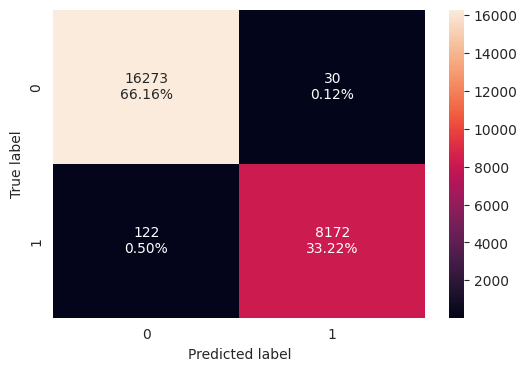




Numeric Summary of performance:
   Accuracy    Recall  Precision        F1
0   0.99382  0.985291   0.996342  0.990786


In [76]:
#model performance and analysis
training_model_perf_orig = model_perf_combo(model0, X_train_tree, y_train_tree)

Performance




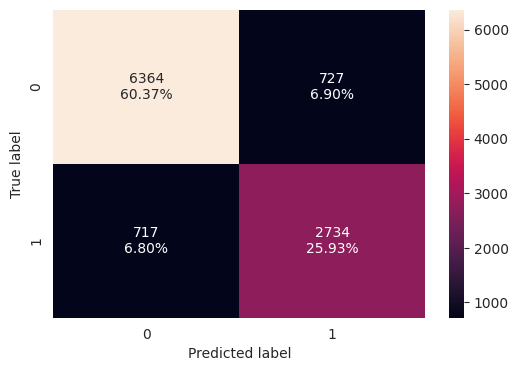




Numeric Summary of performance:
   Accuracy    Recall  Precision        F1
0  0.863024  0.792234   0.789945  0.791088


In [77]:
#repeat for testing data
test_model_perf_orig = model_perf_combo(model0, X_test_tree, y_test_tree)

## Do we need to prune the tree?

Yes.  There is a large disparity of the model on the training and test sets, so pruning is required.  I will try prepruning first and then post-pruning, in an attempt to get the best tree diagram model.

**Best Metric**

As outlined in the above analysis, the metric I will focus on maximizing will be F1.

##Pre-pruning

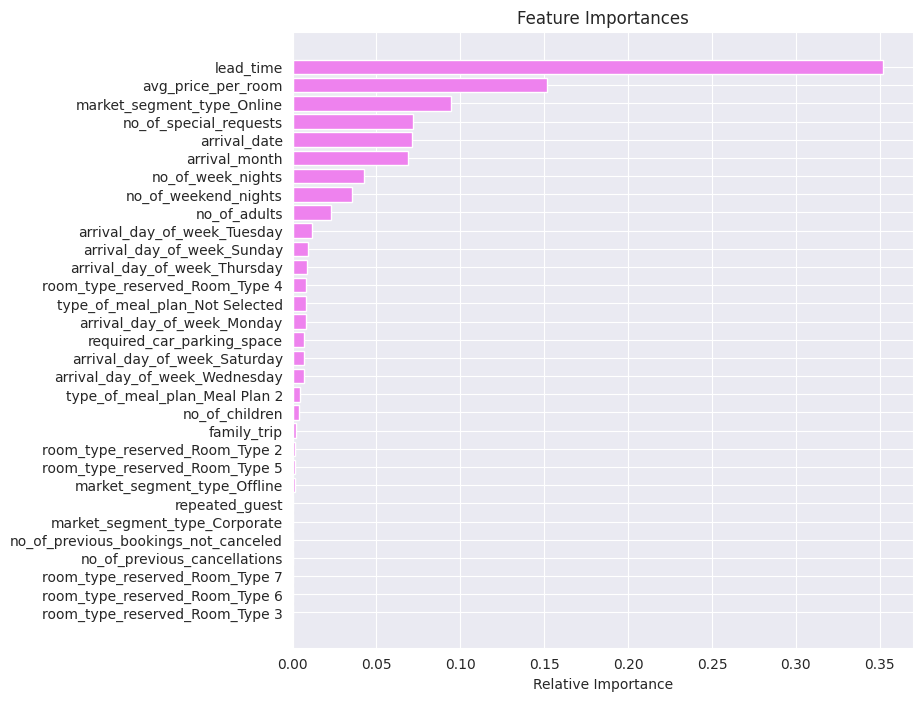

In [78]:
feature_names = list(X_train_tree.columns)
importances = model0.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [79]:
# Grid of parameters to choose from
parameters = {
    "class_weight": [None, "balanced"],
    "max_depth": np.arange(2, 9, 2),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}

# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train_tree, y_train_tree)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train_tree, y_train_tree)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(8),
                       max_leaf_nodes=150, min_samples_split=50,
                       random_state=1)

Performance




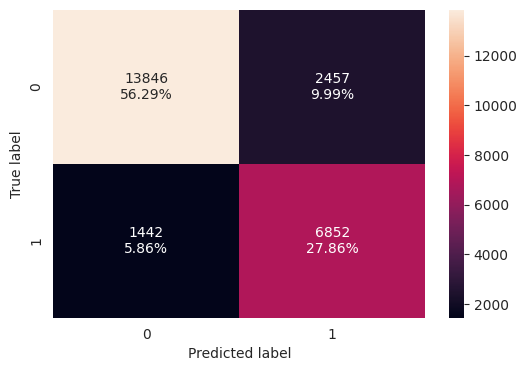




Numeric Summary of performance:
   Accuracy    Recall  Precision        F1
0  0.841485  0.826139   0.736062  0.778504


In [80]:
#show results of estimator model
train_model_perf_preprune = model_perf_combo(estimator, X_train_tree, y_train_tree)

Performance




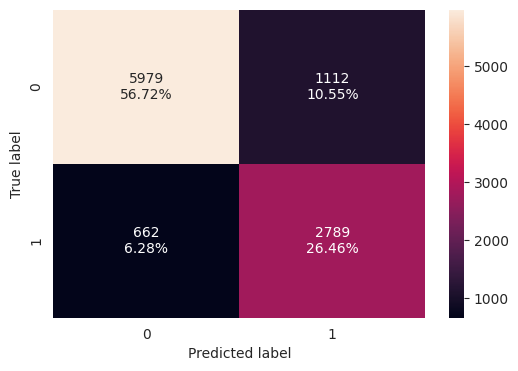




Numeric Summary of performance:
   Accuracy    Recall  Precision        F1
0  0.831721  0.808172   0.714945  0.758705


In [81]:
#repeat above for test data
test_model_perf_preprune = model_perf_combo(estimator, X_test_tree, y_test_tree)

###Observation on Pre-pruning using an estimator
The numeric scores produced are now similar for both the training and test data.  As a result, we now know that the model is not overfitting.  Thus the model can generalize well on unseen data.  However, the F1 score is lower than I'd like.

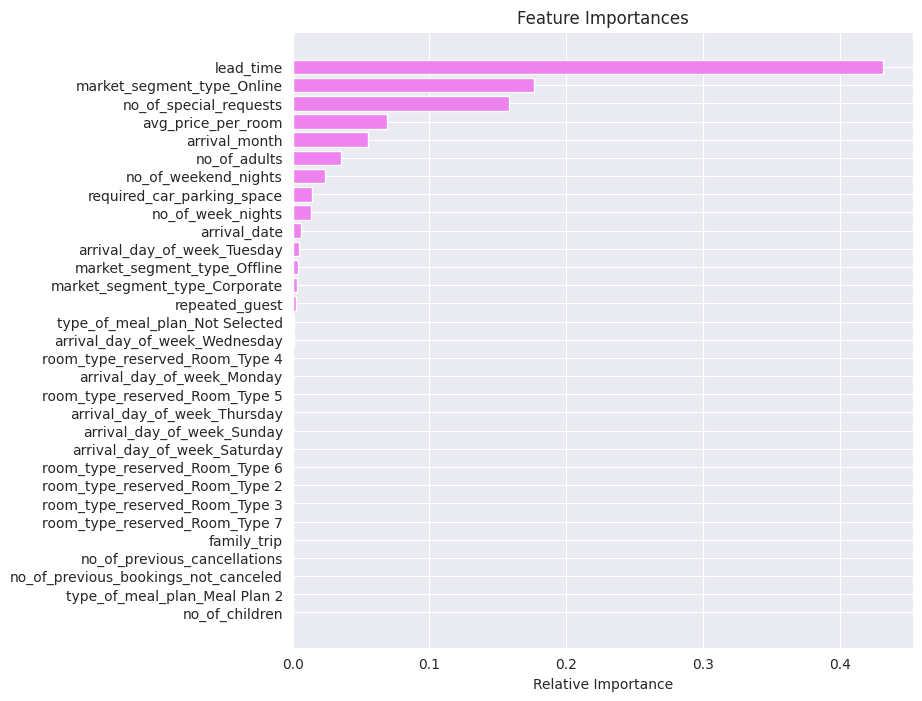

In [82]:
feature_names = list(X_train_tree.columns)
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

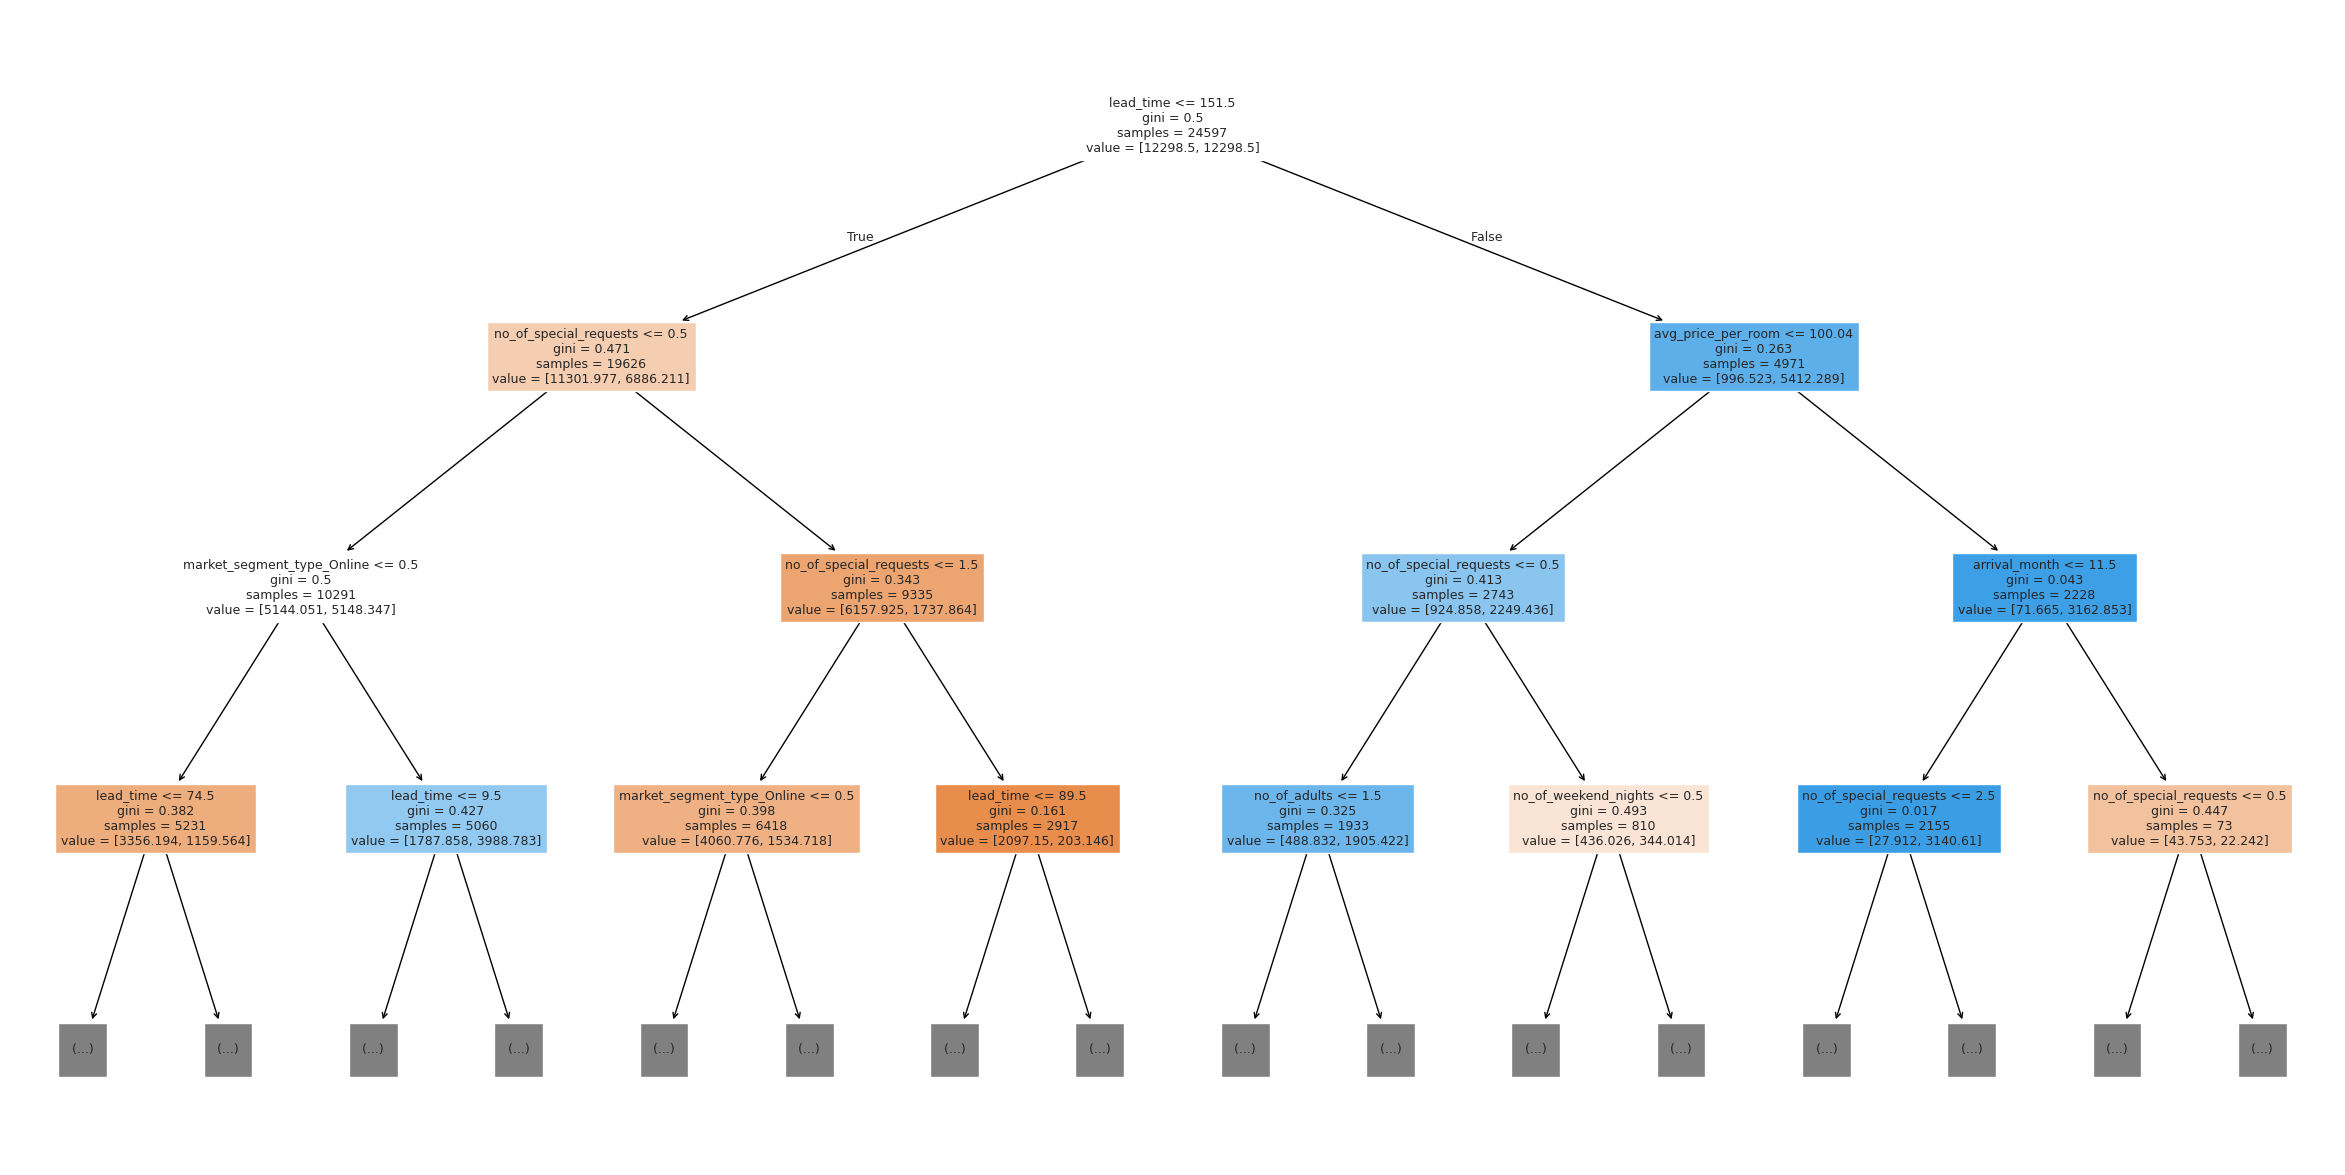

In [83]:
#visualize the tree
plt.figure(figsize=(30, 15))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    max_depth = 3, # Limiting the depth to make it more readable
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [84]:
# Text report showing the rules of a decision tree -
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 74.50
|   |   |   |   |--- no_of_weekend_nights <= 1.50
|   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |--- repeated_guest <= 0.50
|   |   |   |   |   |   |   |--- no_of_adults <= 1.50
|   |   |   |   |   |   |   |   |--- weights: [393.03, 94.90] class: 0
|   |   |   |   |   |   |   |--- no_of_adults >  1.50
|   |   |   |   |   |   |   |   |--- weights: [94.30, 66.73] class: 0
|   |   |   |   |   |   |--- repeated_guest >  0.50
|   |   |   |   |   |   |   |--- lead_time <= 33.00
|   |   |   |   |   |   |   |   |--- weights: [178.79, 0.00] class: 0
|   |   |   |   |   |   |   |--- lead_time >  33.00
|   |   |   |   |   |   |   |   |--- weights: [6.03, 2.97] class: 0
|   |   |   |   |   |--- market_segment_type_Offline >  0.50
|   |   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   | 

##Post-pruning

In [85]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
tree_path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(tree_path.ccp_alphas), tree_path.impurities
pd.DataFrame(tree_path)

,ccp_alphas,impurities
0,0.000000e+00,0.008470
1,-5.421011e-20,0.008470
2,2.706046e-20,0.008470
3,2.706046e-20,0.008470
4,2.706046e-20,0.008470
...,...,...
1681,9.098544e-03,0.327976
1682,1.013170e-02,0.338107
1683,1.155148e-02,0.349659
1684,3.457960e-02,0.418818


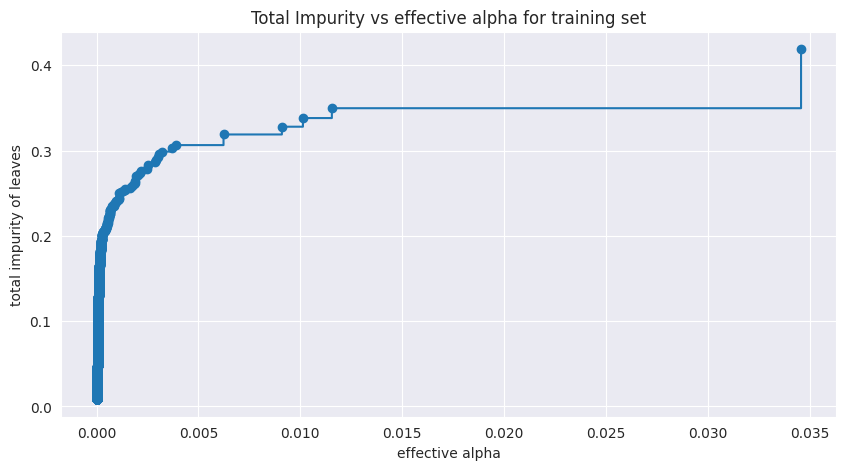

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [87]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train_tree, y_train_tree)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 3 with ccp_alpha: 0.08118209700288387


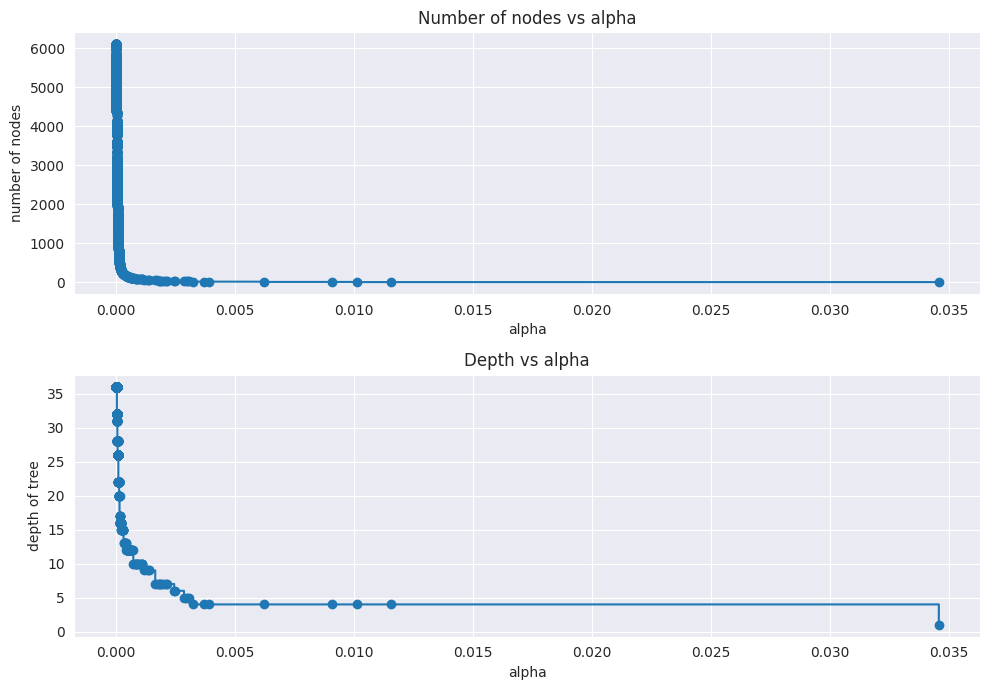

In [88]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

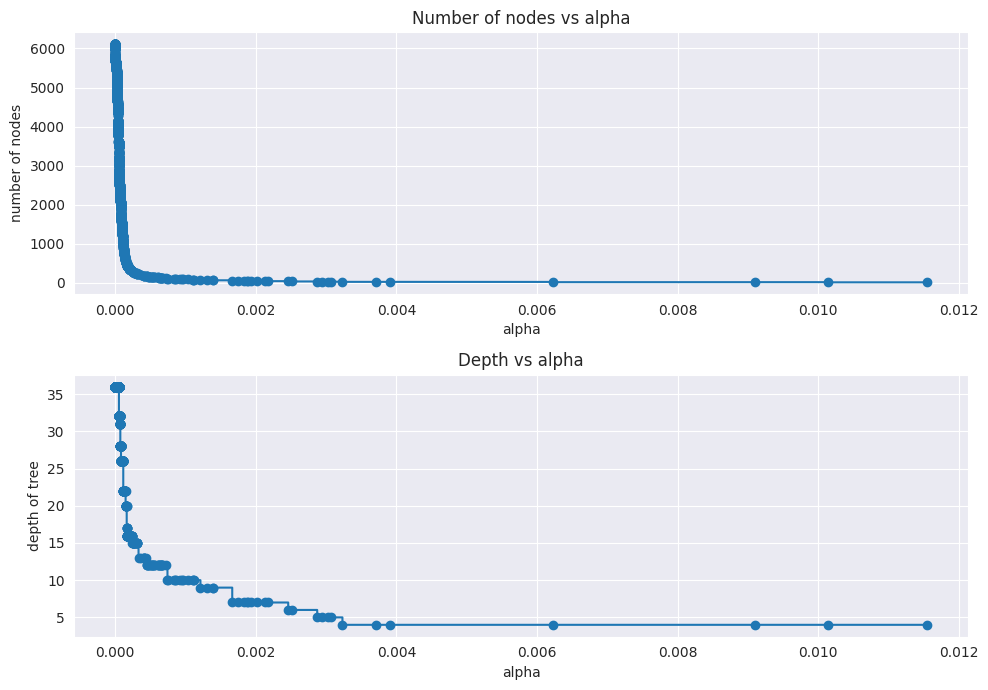

In [89]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [90]:
#pull the f1 scores for training data
f1_train = []
for clf in clfs:
    pred_train = clf.predict(X_train_tree)
    values_train = f1_score(y_train_tree, pred_train)
    f1_train.append(values_train)

#pull the f1 scores for test data
f1_test = []
for clf in clfs:
    pred_test = clf.predict(X_test_tree)
    values_test = f1_score(y_test_tree, pred_test)
    f1_test.append(values_test)

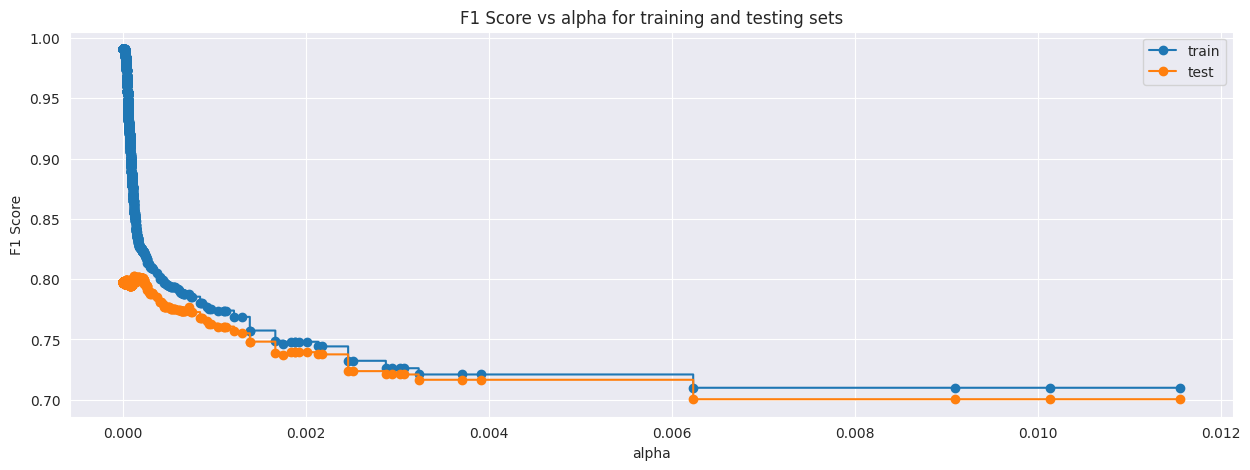

In [91]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs alpha for training and testing sets")
ax.plot(ccp_alphas, f1_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, f1_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [92]:
index_best_model = np.argmax(f1_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.00012040016238129764),
                       class_weight='balanced', random_state=1)


### Exploring F1 Score vs. Model Complexity

To help select a model that balances a high F1 score with fewer leaves (simpler model), we can plot the F1 score against the number of nodes in each tree. This allows for visual inspection of the trade-off.

Model with highest F1-test score (index 1437):
ccp_alpha       0.000120
node_count    883.000000
depth          22.000000
f1_train        0.859454
f1_test         0.802684
Name: 1437, dtype: float64


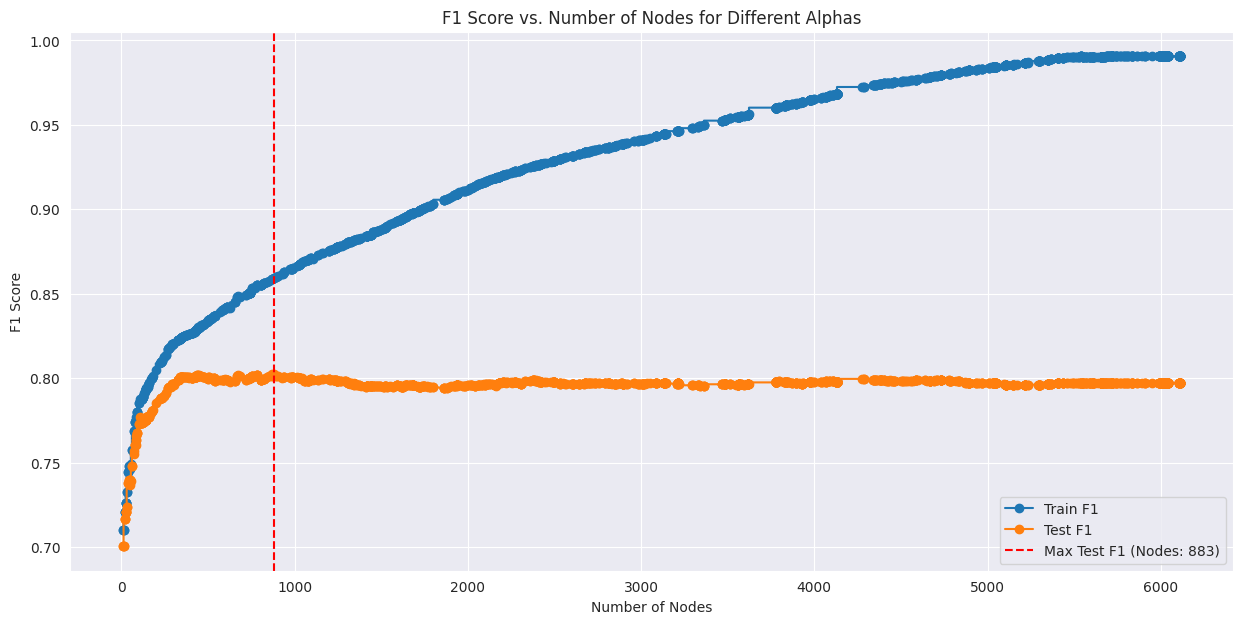

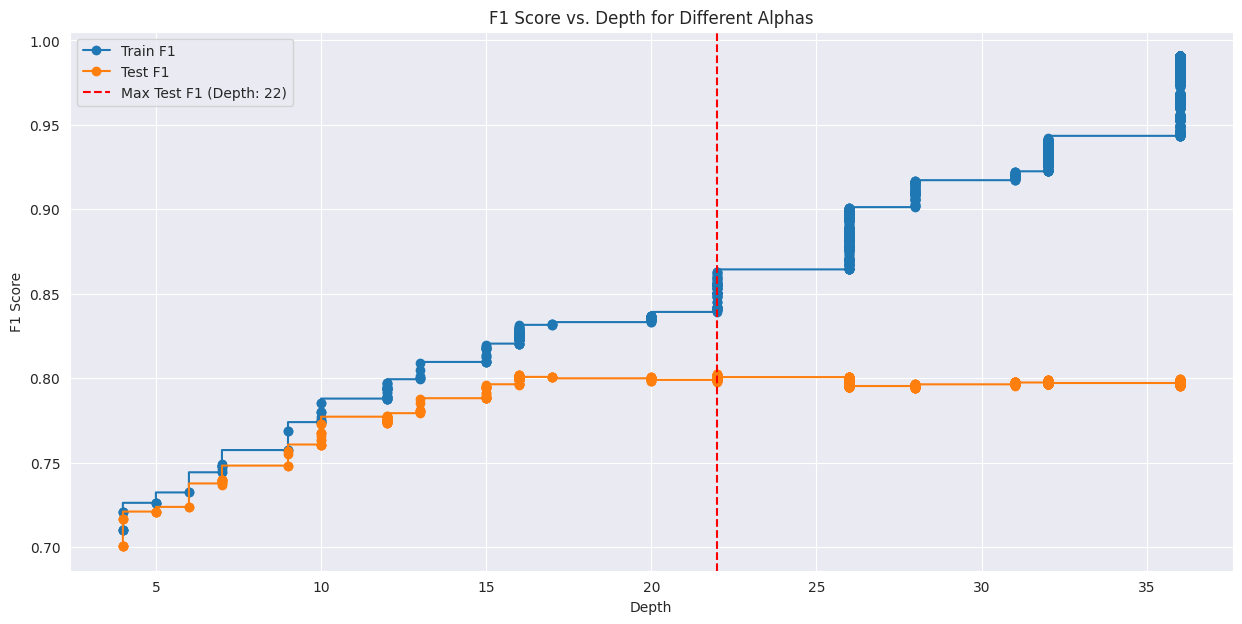

In [93]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

# Create a DataFrame to hold all relevant metrics for easier analysis
metrics_df = pd.DataFrame({
    'ccp_alpha': ccp_alphas,
    'node_count': node_counts,
    'depth': depth,
    'f1_train': f1_train,
    'f1_test': f1_test
})

# Find the index of the model with the highest F1-test score
max_f1_test_idx = np.argmax(metrics_df['f1_test'])
print(f"Model with highest F1-test score (index {max_f1_test_idx}):")
print(metrics_df.iloc[max_f1_test_idx])

# Plot F1 score vs. Number of Nodes
plt.figure(figsize=(15, 7))
plt.plot(metrics_df['node_count'], metrics_df['f1_train'], marker='o', label='Train F1', drawstyle="steps-post")
plt.plot(metrics_df['node_count'], metrics_df['f1_test'], marker='o', label='Test F1', drawstyle="steps-post")
plt.xlabel("Number of Nodes")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Number of Nodes for Different Alphas")
plt.axvline(x=metrics_df.iloc[max_f1_test_idx]['node_count'], color='r', linestyle='--', label=f'Max Test F1 (Nodes: {int(metrics_df.iloc[max_f1_test_idx]["node_count"])})')
plt.legend()
plt.grid(True)
plt.show()

# Plot F1 score vs. Depth
plt.figure(figsize=(15, 7))
plt.plot(metrics_df['depth'], metrics_df['f1_train'], marker='o', label='Train F1', drawstyle="steps-post")
plt.plot(metrics_df['depth'], metrics_df['f1_test'], marker='o', label='Test F1', drawstyle="steps-post")
plt.xlabel("Depth")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Depth for Different Alphas")
plt.axvline(x=metrics_df.iloc[max_f1_test_idx]['depth'], color='r', linestyle='--', label=f'Max Test F1 (Depth: {int(metrics_df.iloc[max_f1_test_idx]["depth"])})')
plt.legend()
plt.grid(True)
plt.show()

The plots above show the relationship between the F1 score (for both training and test sets) and the complexity of the decision tree (measured by number of nodes and depth).

Instead of simply picking `np.argmax(f1_test)`, you can visually inspect these plots to find a point where the test F1 score is still high, but the number of nodes or depth is significantly lower. This often represents a sweet spot for model generalization and interpretability.

For instance, you might look for the first significant drop in node count (or depth) after the F1 score has reached a peak or plateau. Alternatively, if multiple models yield very similar F1 scores, pick the one with the fewest nodes. You can then manually select the `ccp_alpha` value (or the corresponding index in `clfs`) that best represents this balance, and then assign that `clf` to `best_model`.

Performance




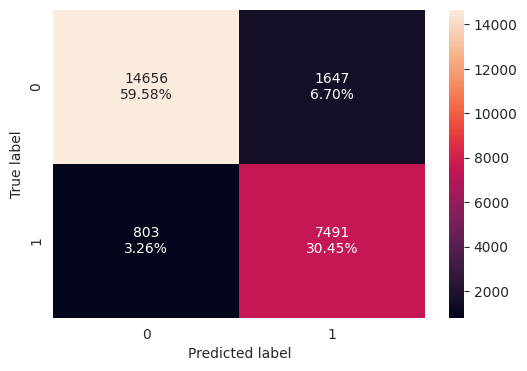




Numeric Summary of performance:
   Accuracy    Recall  Precision        F1
0  0.900394  0.903183   0.819764  0.859454


In [94]:
train_model_perf_postprune = model_perf_combo(best_model, X_train_tree, y_train_tree)

Performance




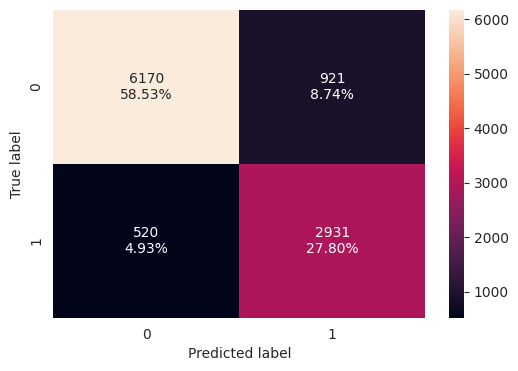




Numeric Summary of performance:
   Accuracy    Recall  Precision        F1
0  0.863309  0.849319   0.760903  0.802684


In [95]:
test_model_perf_postprune = model_perf_combo(best_model, X_test_tree, y_test_tree)

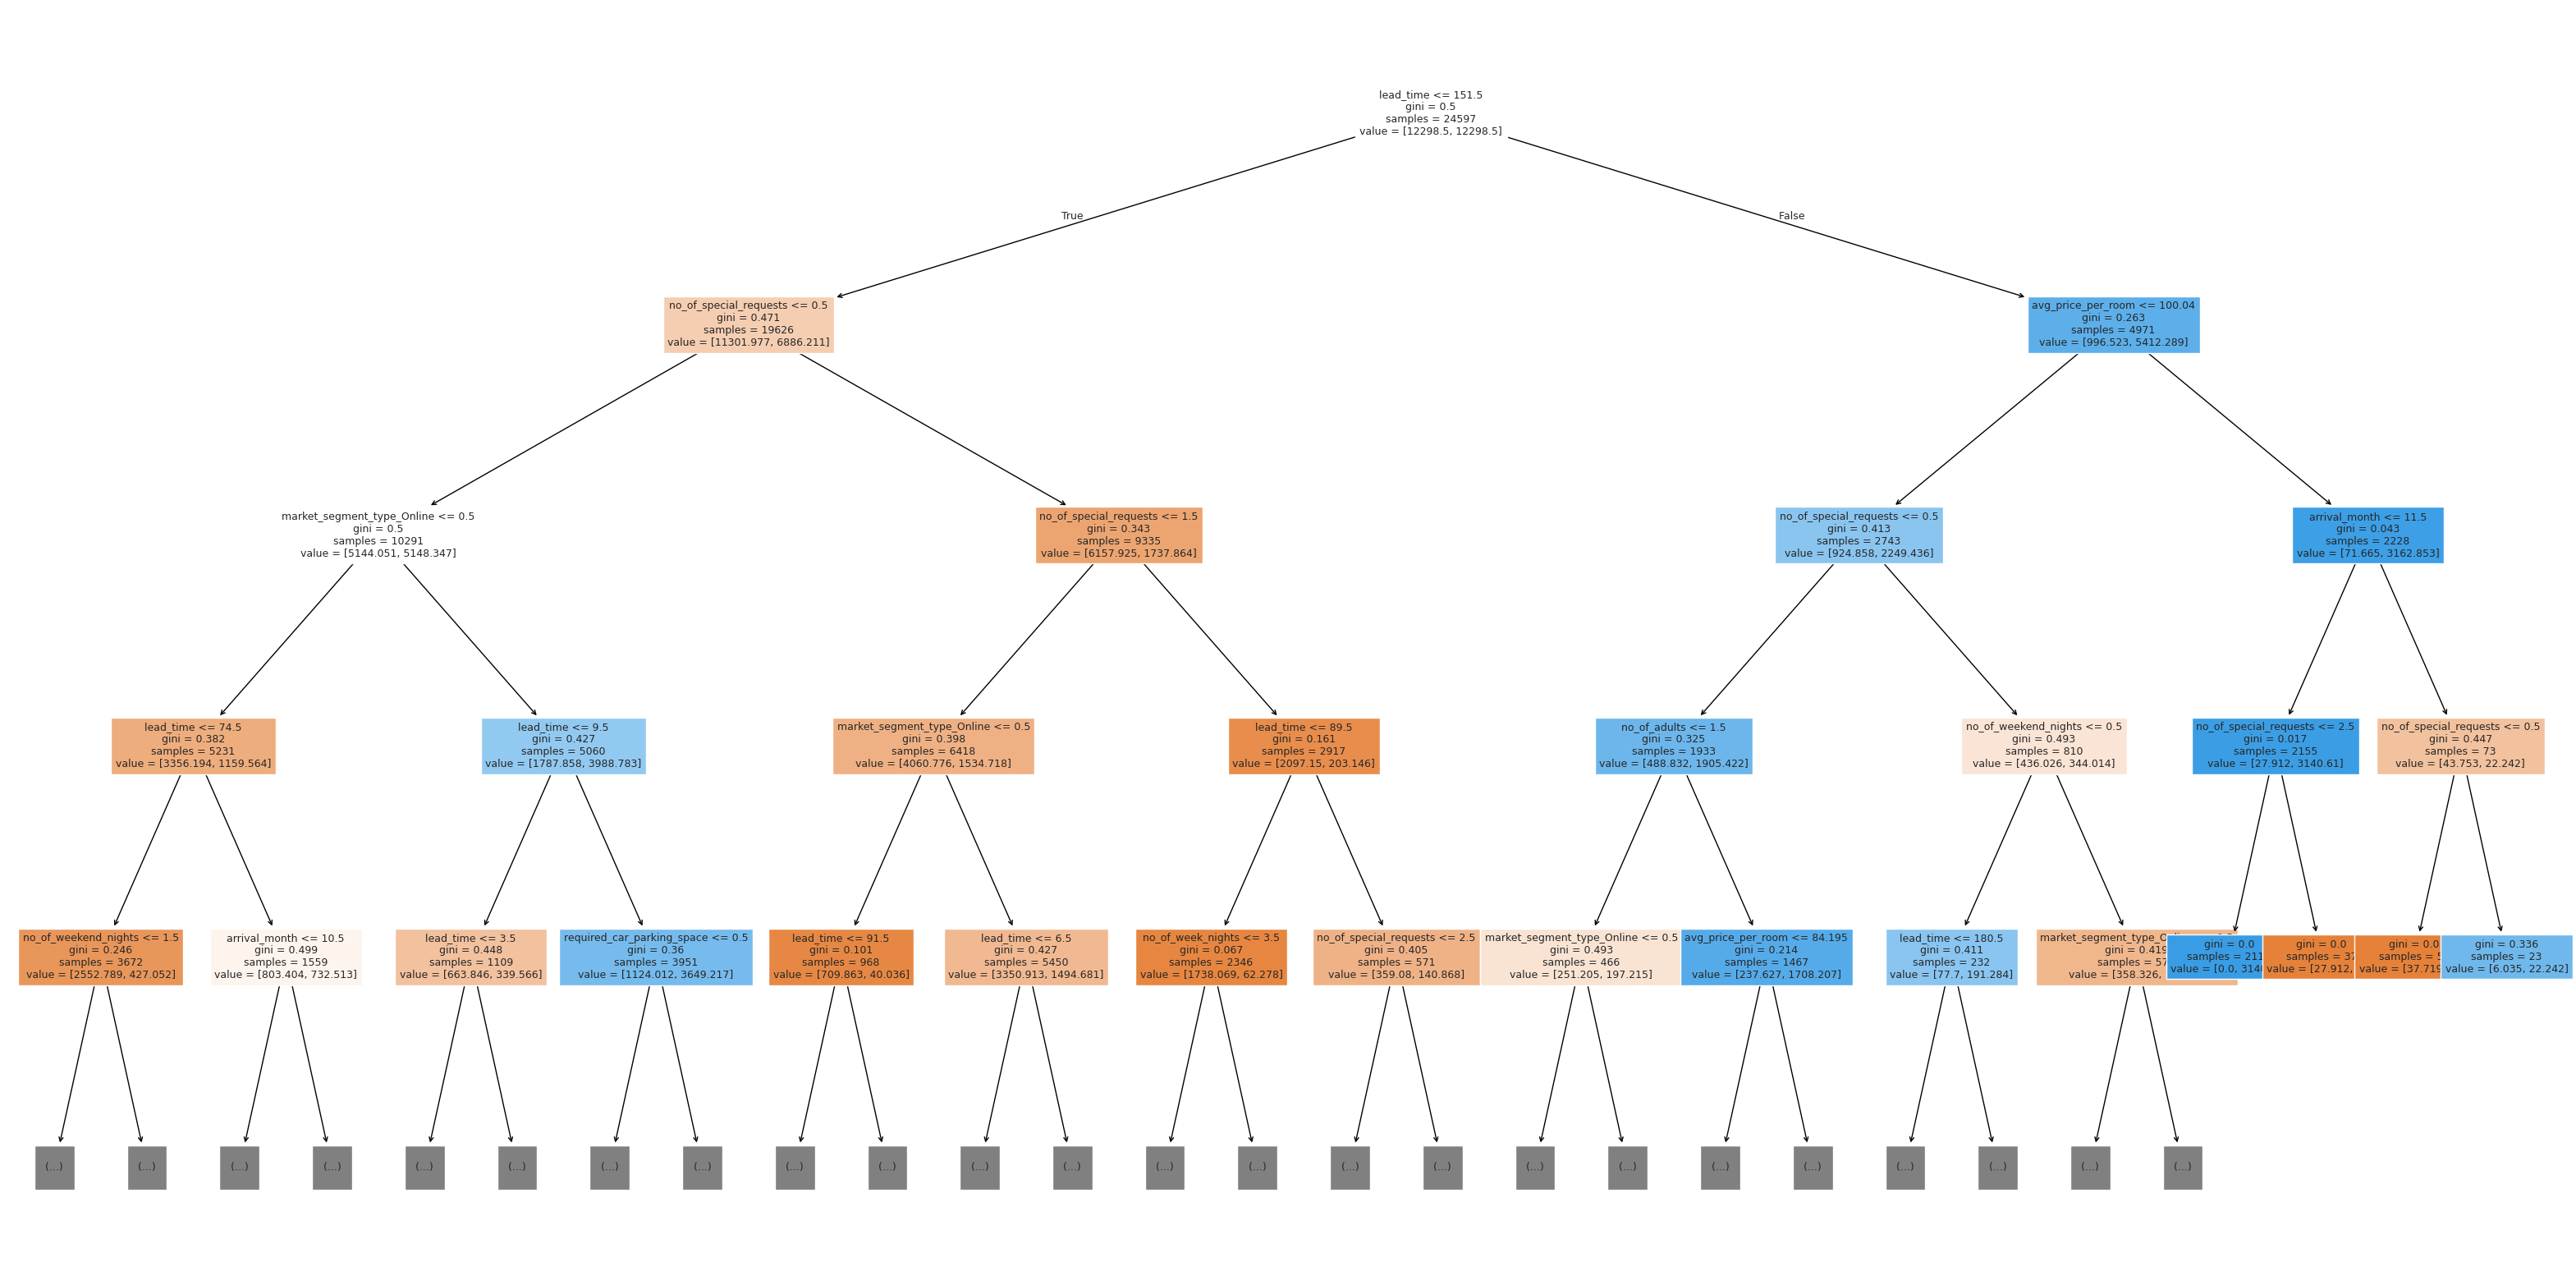

In [96]:
plt.figure(figsize=(40, 20))

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
    max_depth=4 # Limiting the depth to make it more readable
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [97]:
print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))


|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 74.50
|   |   |   |   |--- no_of_weekend_nights <= 1.50
|   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |--- repeated_guest <= 0.50
|   |   |   |   |   |   |   |--- no_of_adults <= 1.50
|   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 <= 0.50
|   |   |   |   |   |   |   |   |   |--- arrival_date <= 29.50
|   |   |   |   |   |   |   |   |   |   |--- lead_time <= 20.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [278.36, 32.62] class: 0
|   |   |   |   |   |   |   |   |   |   |--- lead_time >  20.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |   |   |   |   |   |--- arrival_date >  29.50
|   |   |   |   |   |   |   |   |   |   |--- lead_time <= 7.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [9.05, 1.48] class: 0
|

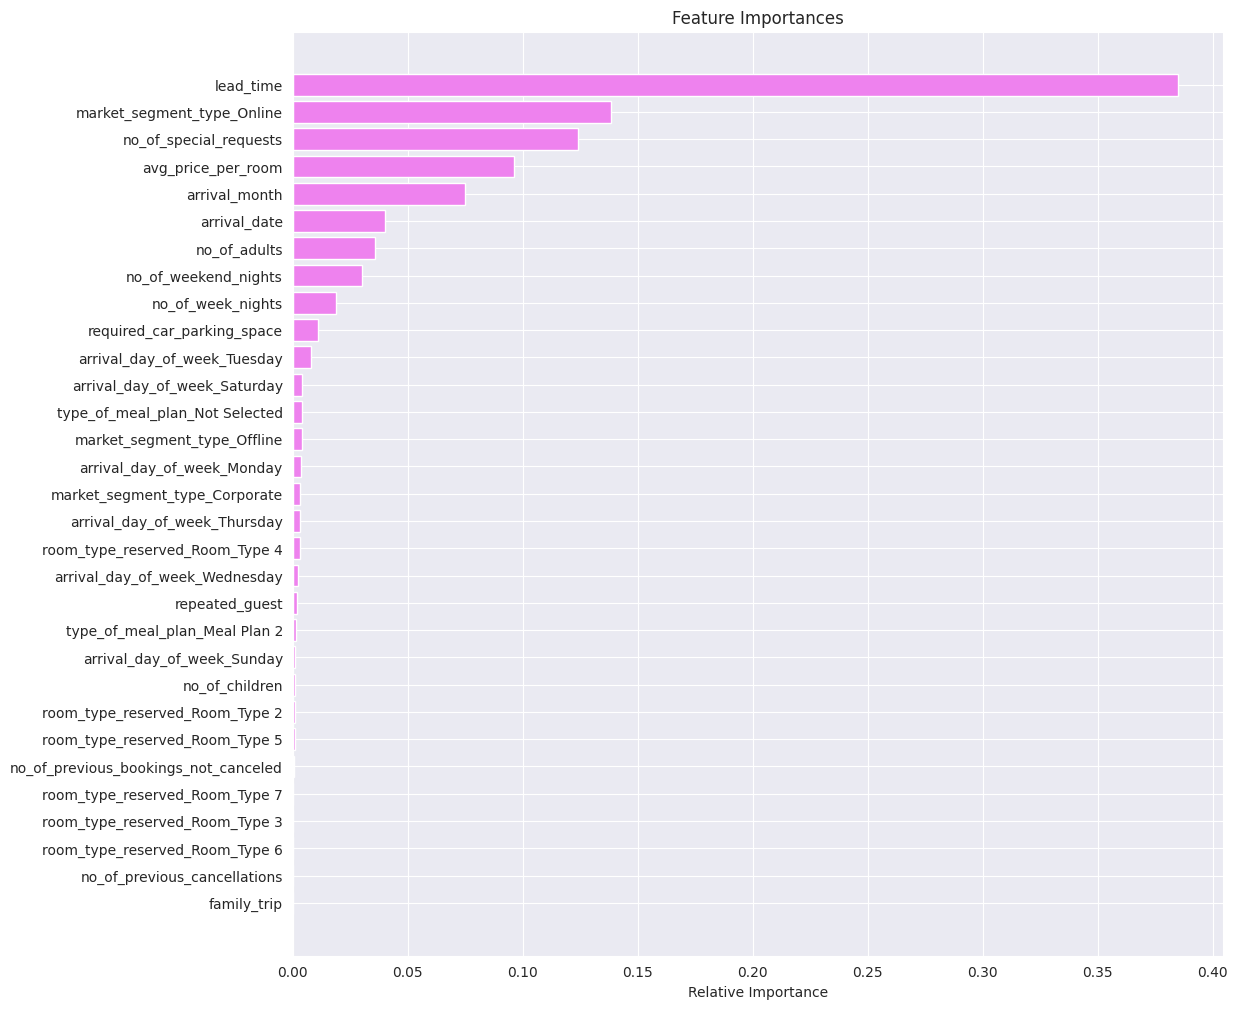

In [98]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##Final Model Summary (Decision Tree)


In [99]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        training_model_perf_orig.T,
        train_model_perf_preprune.T,
        train_model_perf_postprune.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree sklearn",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree sklearn,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.993820,0.841485,0.900394
Recall,0.985291,0.826139,0.903183
Precision,0.996342,0.736062,0.819764
F1,0.990786,0.778504,0.859454


In [100]:
#model performance comparison for test data
models_test_comp_df = pd.concat(
    [
        test_model_perf_orig.T,
        test_model_perf_preprune.T,
        test_model_perf_postprune.T,
    ],
    axis=1,
    )
models_test_comp_df.columns = [
    "Decision Tree sklearn",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Decision Tree sklearn,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.863024,0.831721,0.863309
Recall,0.792234,0.808172,0.849319
Precision,0.789945,0.714945,0.760903
F1,0.791088,0.758705,0.802684


### Model Performance Comparison and Conclusions

Of the two methods (pre-pruning v post-pruning), post pruning created a model that better maximized the F1 score (along with accuracy, recall, and precision).  This would suggest that post-pruning is the better model.  However, the model is still highly complex due to the size of the data.  Additionally, there is an approximate difference of -0.06 in the F1 scores between the training and testing data and a 0.04 drop in accuracy.  This suggests that the training model is still overfitting slightly.

The pre-pruning model also tends towards complexity.  I varied the max_depth parameter several times (max = 24, max = 12, max = 10 and max = 8 {the current model}).  Each time the pre-pruning algorithm selected the most complex depth available.  

In the post-pruning model, the most important differentiator is a lead time of <=151 days.  The second most important differentiator is the number of special requests and market segement online.  This is similar to what the regression model predicted.

## Actionable Insights and Recommendations

The regression analysis and tree diagram actually help us see two differnt priority.  The regression analysis can help the hotel decrease the number of cancellations while the tree diagram can help the hotel identify areas in which to recoup lost costs.

- What profitable policies for cancellations and refunds can the hotel adopt?
  * The major factors that suggest a high likelihood of cancellation are lead time, meal plan not selected, number of previous cancellations, and weekend nights.
  * First, the hotel should institute a time-tier cancellation fee system similar to that which airlines and events have.  For instance, if you cancel with more than 150 days notice (the decision tree split is 151.5), then you get a full refund.  The closer to your arrival date, the lower the percentage of the room fee will be refunded to you.
  * Second, the hotel may selectively choose to increase the cancellation fee for customers who have had multiple cancellations.  However, this should be used with caution due to the damage this scheme could have to brand equity.  Possibly, the hotel could note the number of cancellations in a six month period, rather than applying the logic to the lifetime of the customer's account.
  * No meal plan selected is something that the Inn should train managers and employees to handle.  The IT deparment needs to create and autogenerate a daily or weekly report that is sent to managers that lists the reservations without a meal plan.  These guests should be contacted by the local hotel to help that guest select a meal plan.  This is solid customer service that leads to better brand equity and may also help decrease the number of cancellations.
  * The only criteria that I struggle to find a solution for is number of weekend nights.  The more weekend nights booked, the higher the likelihood of cancellation.  The hotel could possibly implement a credit system if a guest wants to cancel their second night, similar to what some retail stores do.  Instead of a refund, they may move that reservation to a different night within the next 60, 120, or 180 days.  Otherwise, the guest loses the credit.  This would ensure that revenue is captured without giving away too many complementary rooms.  If the full reservation is being cancelled, then the tier system above would apply.
- What other recommedations would you suggest to the hotel?
  * The regression analysis strongly suggests that customer loyalty is the single greatest factor in reducing the likelihood of cancellations.  The hotel should focus on ways to improve this, specifically through areas in which they already seem to be retaining customers.
  * First, they should market and advertise that they are able to provide parking for their guests.  It is not clear from the data whether parking is a cost for the guest.  If it is, I suggest the Inn chain no longer charge for parking and market it as an option for travelers.
  * Second, they should focus on the room types.  Most of the rooms above room_type_1 contributed to a reduction in the likelihood of cancellation.  They should attempt to grow brand equity by both marketing these rooms and/or providing upgrades for select customers.
  * Third, their business department should be proactive about soliciting long term contracts with large corporations whose employees have to travel.  This will ensure a more steady stream of repeated guests who do not cancel their plans.
  * Fourth, concurrent with the market campaigns mentioned above, the hotel should make sure to highlight their willingness to accomodate special requests from their guests (assuming that the cost of these does not outweight revenue) since a higher number of special requests lowers the likelihood of cancellation (and since is is a second tier node on the decision tree).

##<a name='link1'>Appendix: Detailed Exploratory Data Analysis (EDA)</a>

This is the full set of exploratory data analysis.  The visualizations/insights relevant to the research question have been duplicated above.

In [101]:
#custom definitions from the course to visualize data
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram


  # function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature, # Added to address FutureWarning
        palette="Paired",
        order=data[feature].value_counts().index[:n],
        legend=False # Added to address FutureWarning
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

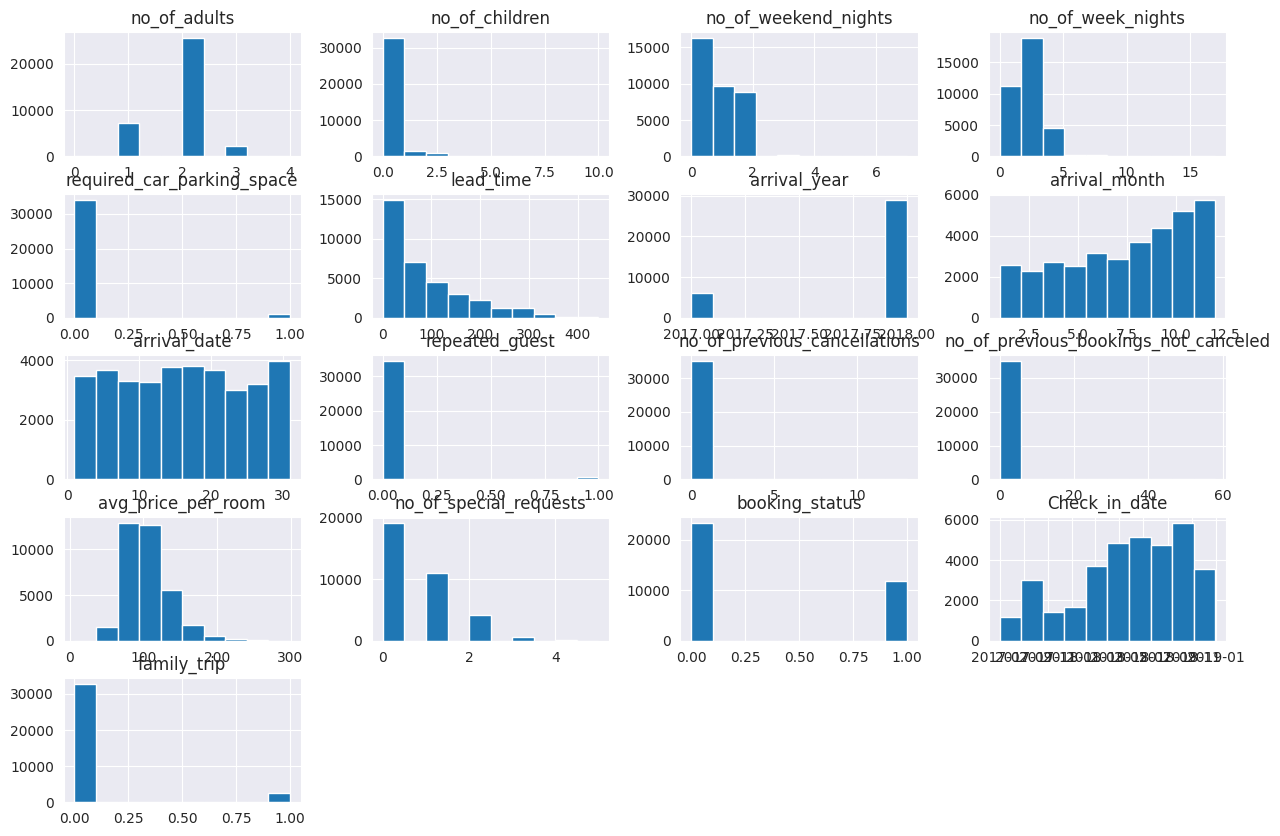

In [102]:
#quick-view visualization of the numeric variables in the dataframe.
sns.set_style("darkgrid")
data4.hist(figsize=(15, 10))
plt.show()


* The price per room appears normally distributed.
* Lead time and number of special requests are right skewed.
* The number of adults is approximately normally distributed.

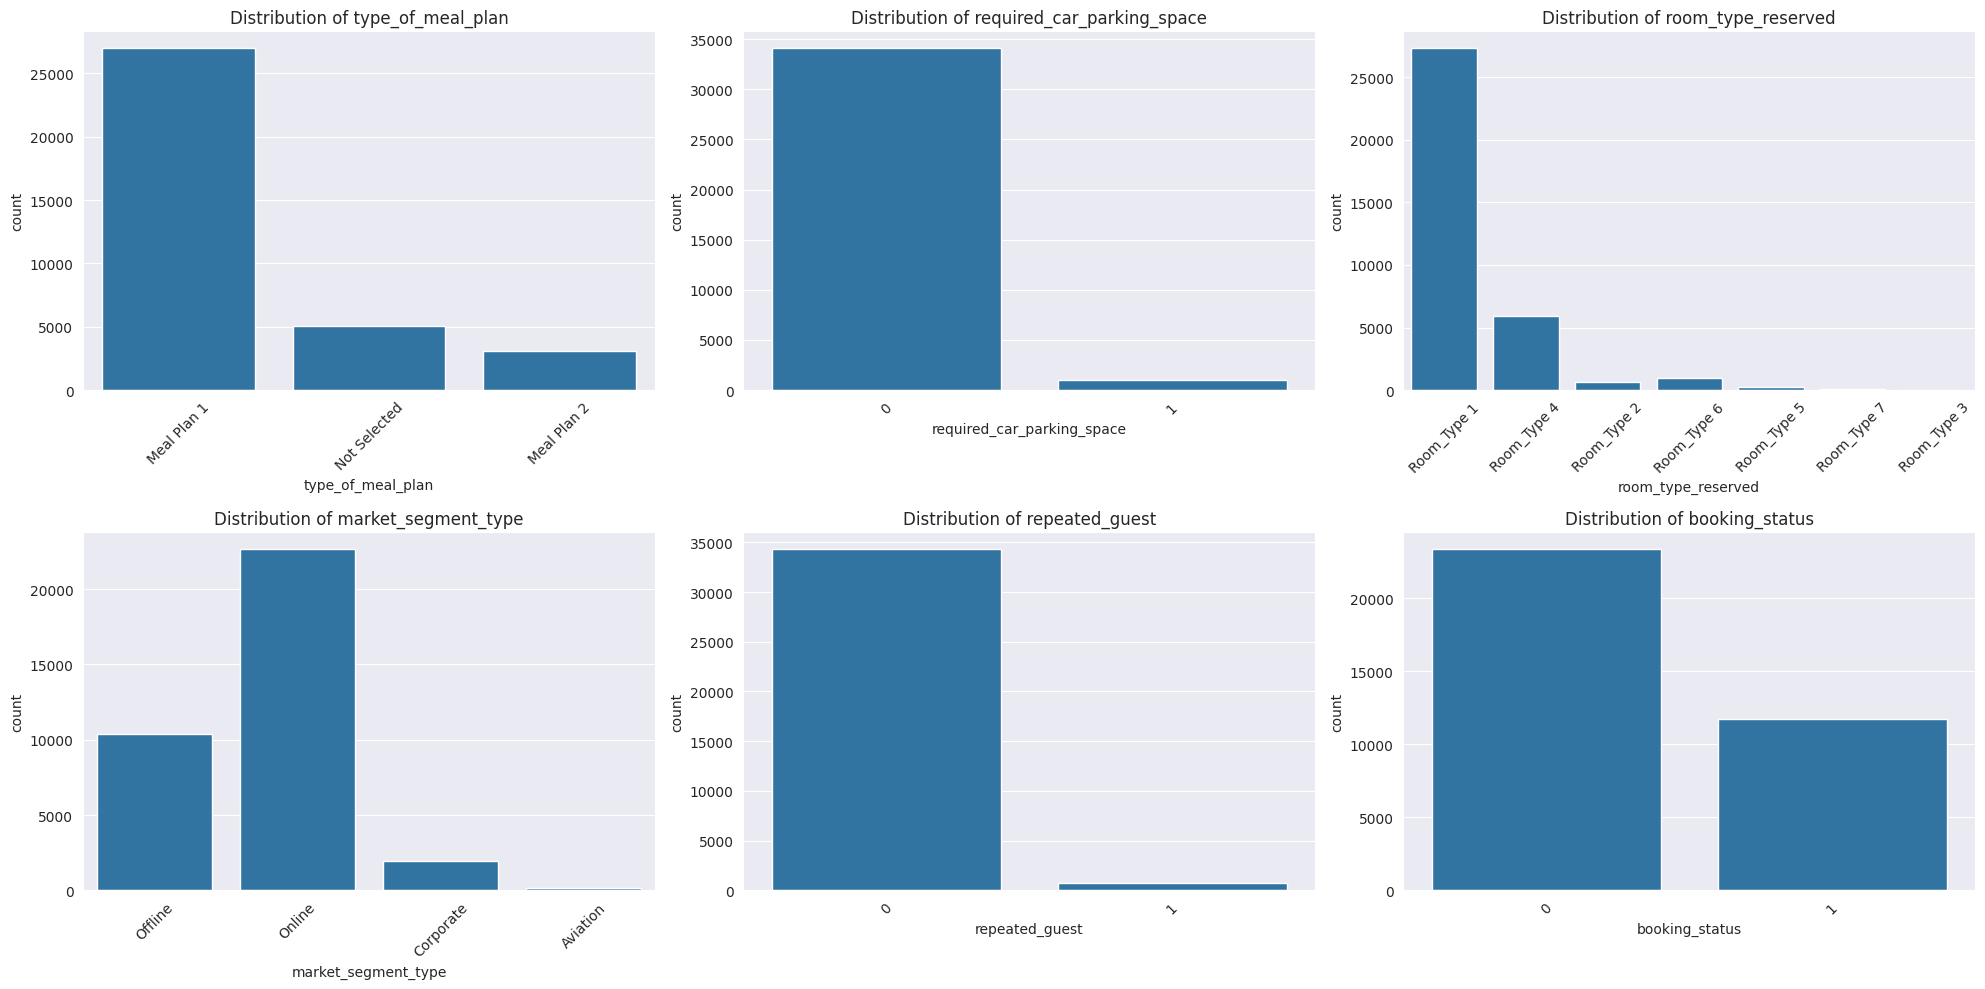

In [103]:
#quick-view visualization of the categorical variables
cat_cols = ['type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'market_segment_type', 'repeated_guest', 'booking_status']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10)) # Adjust subplot grid to fit 6 plots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(cat_cols):
    sns.countplot(data=data4, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##Univariate Analysis

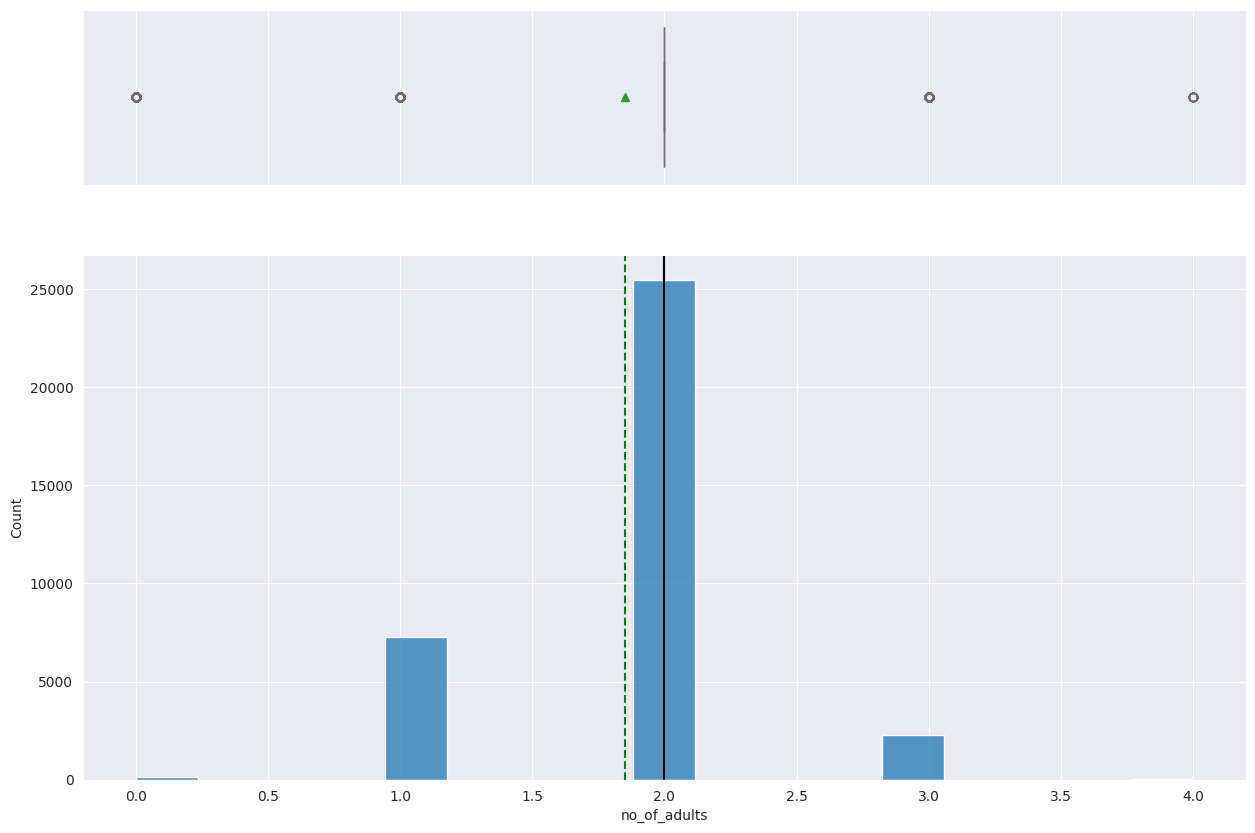

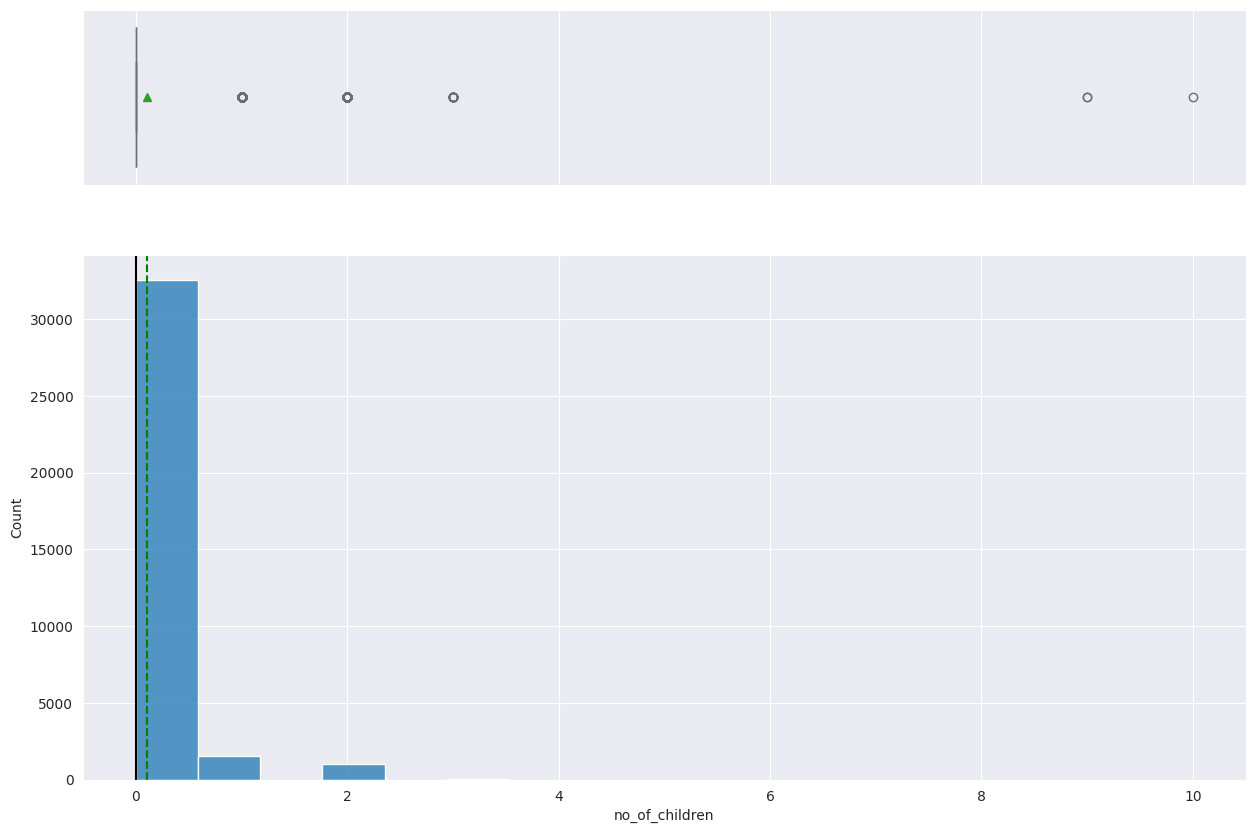

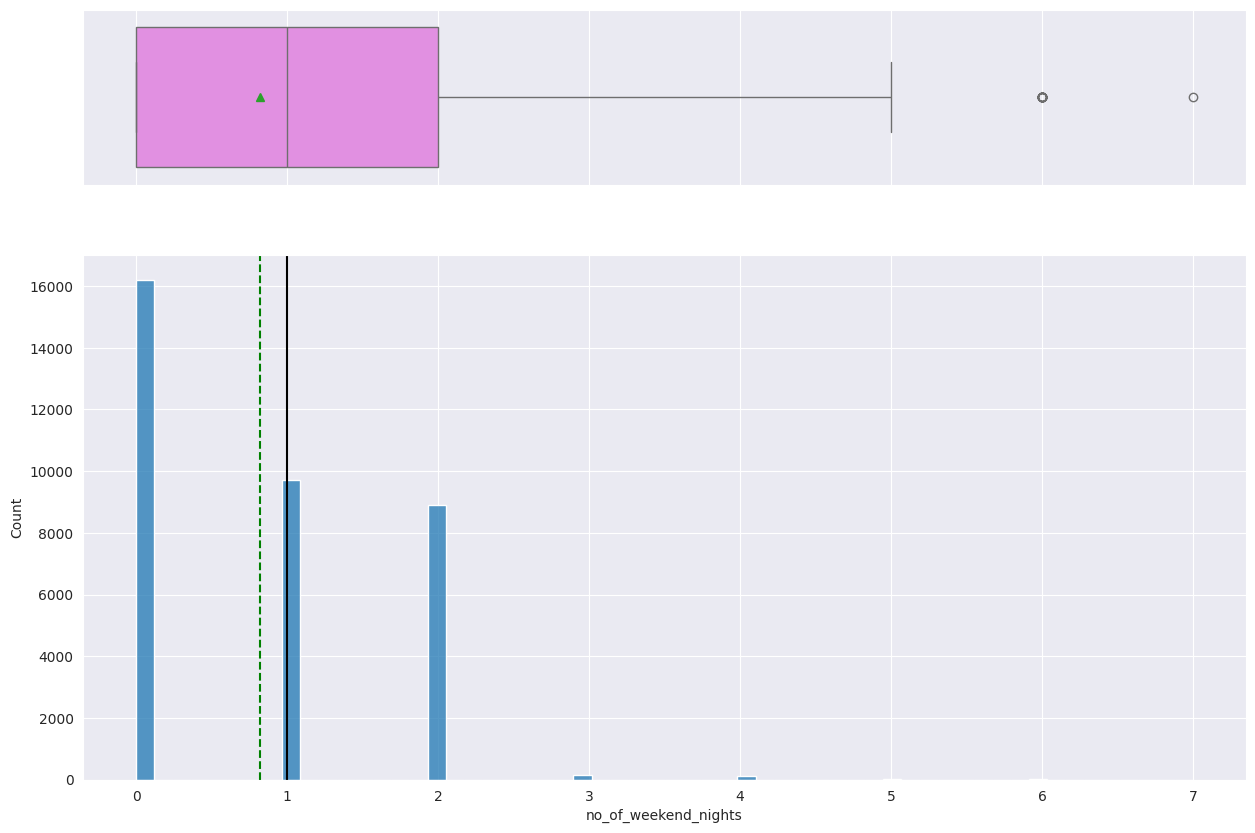

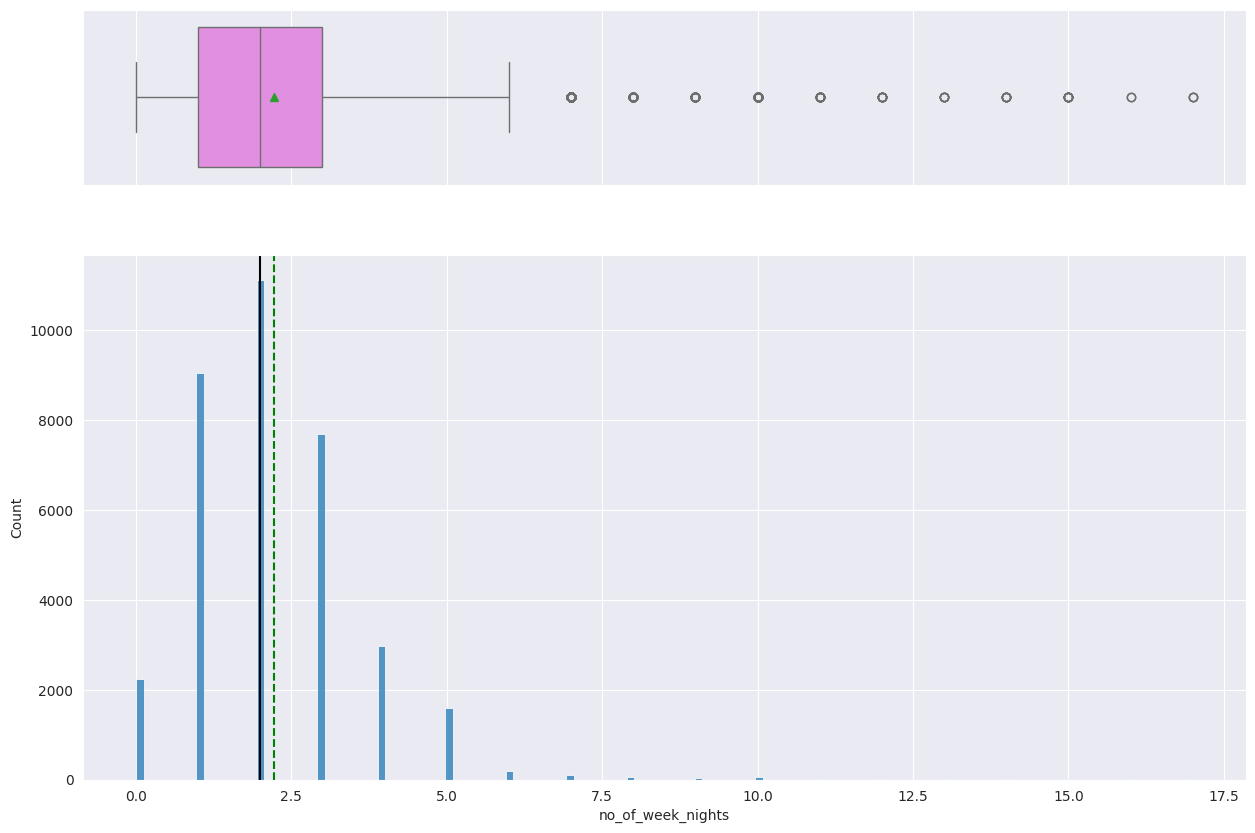

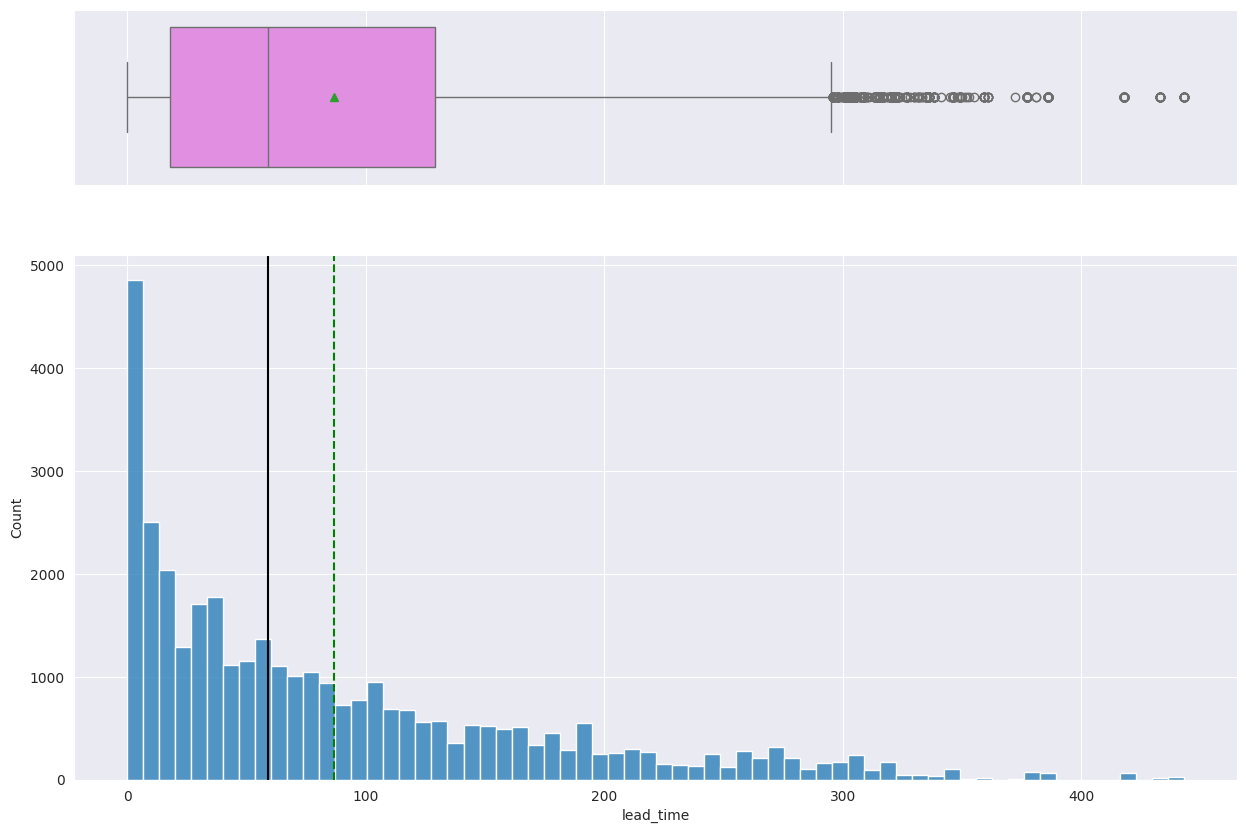

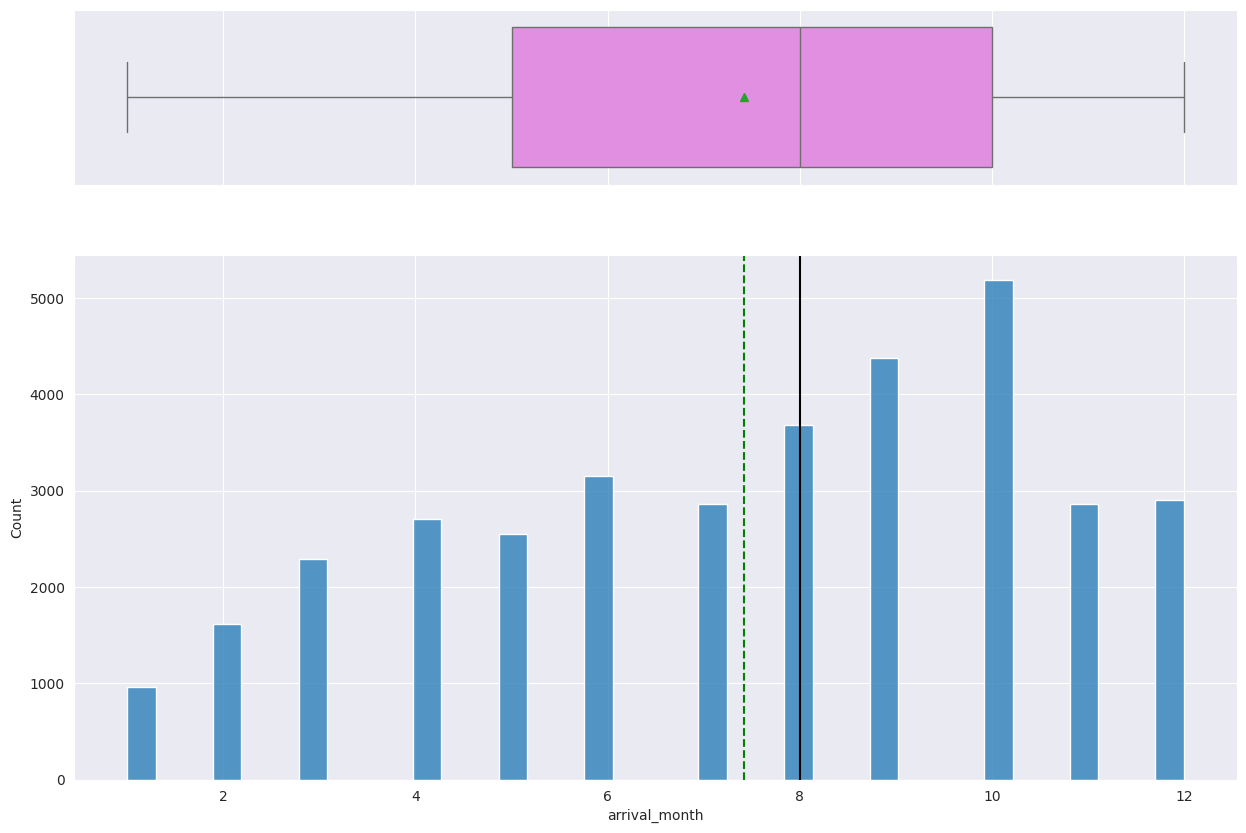

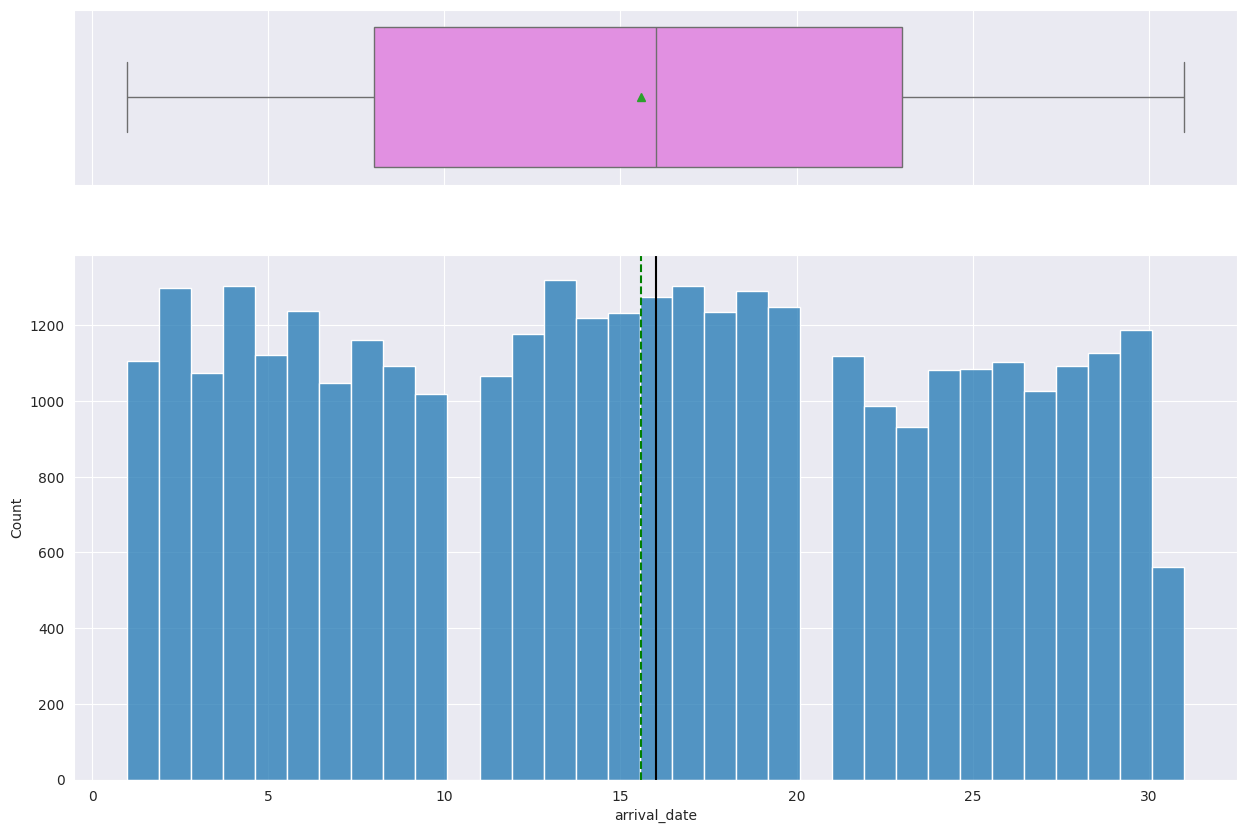

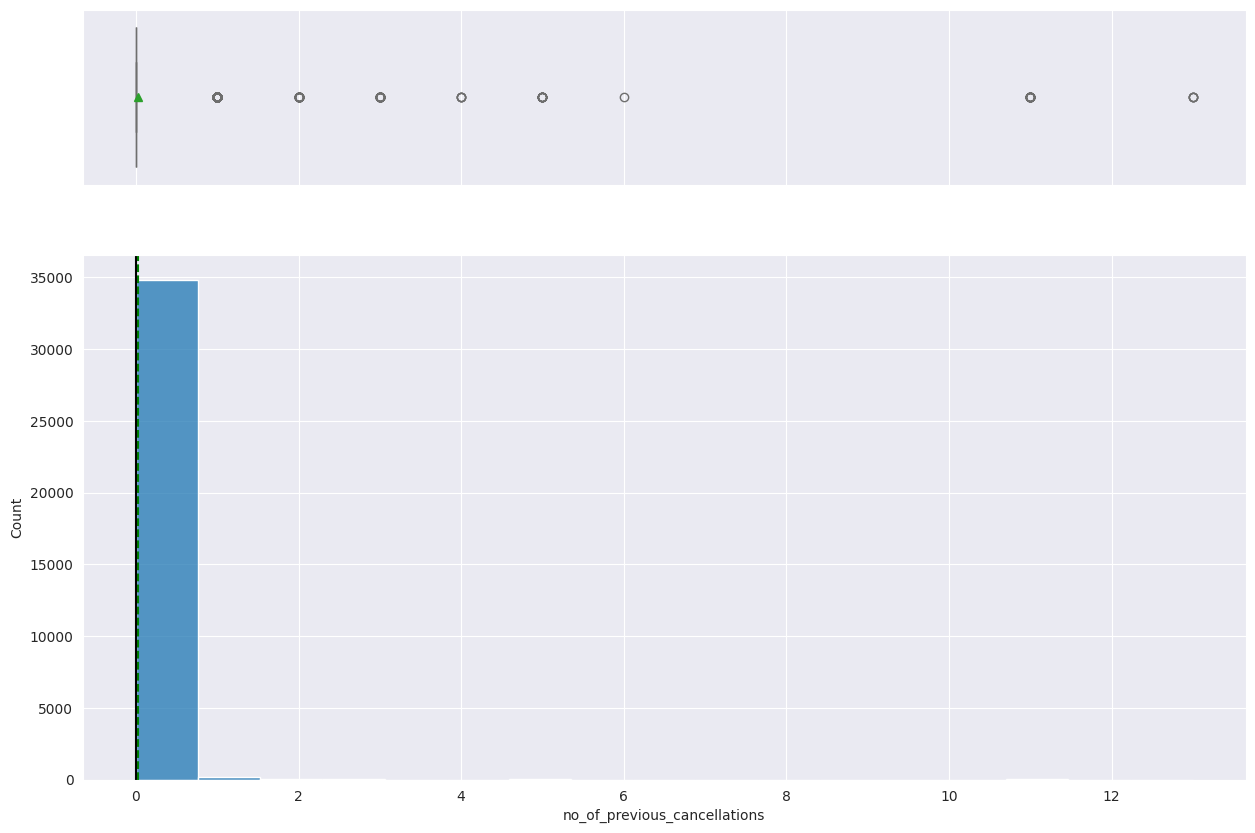

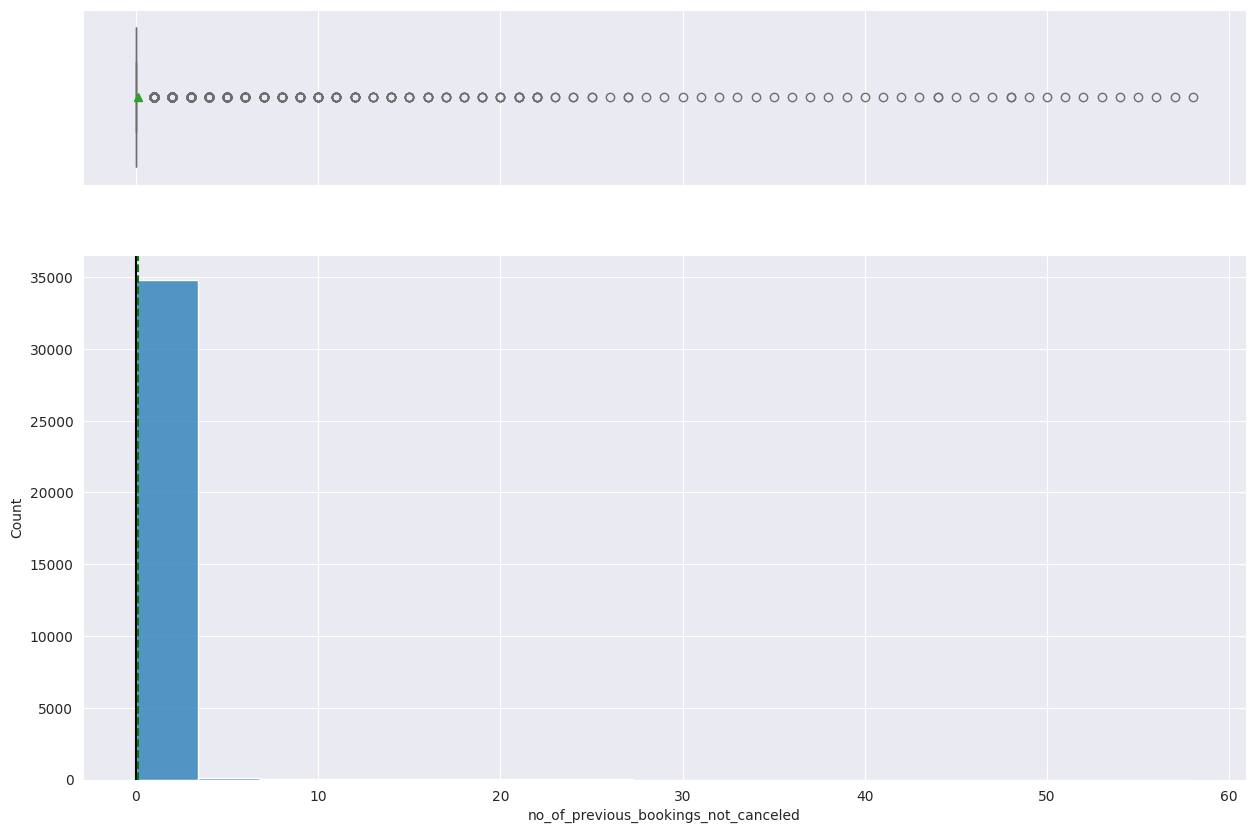

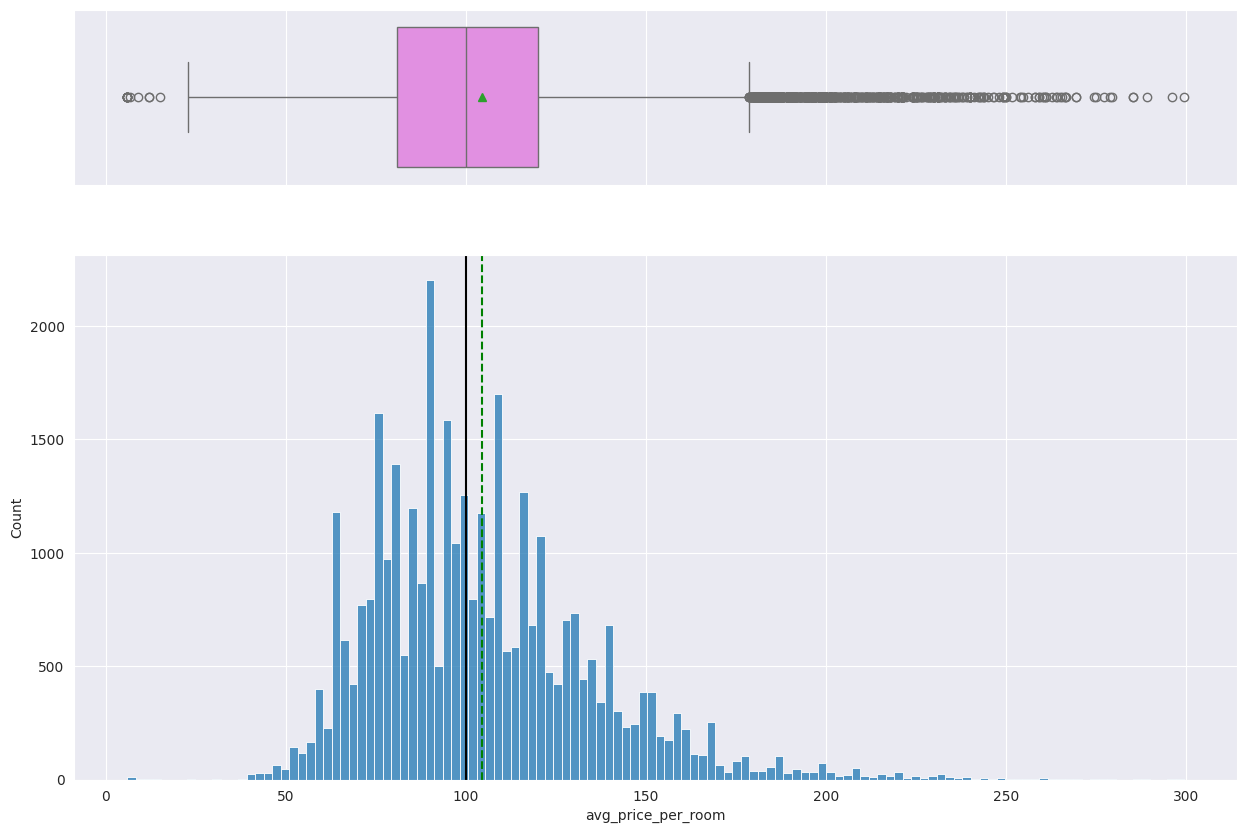

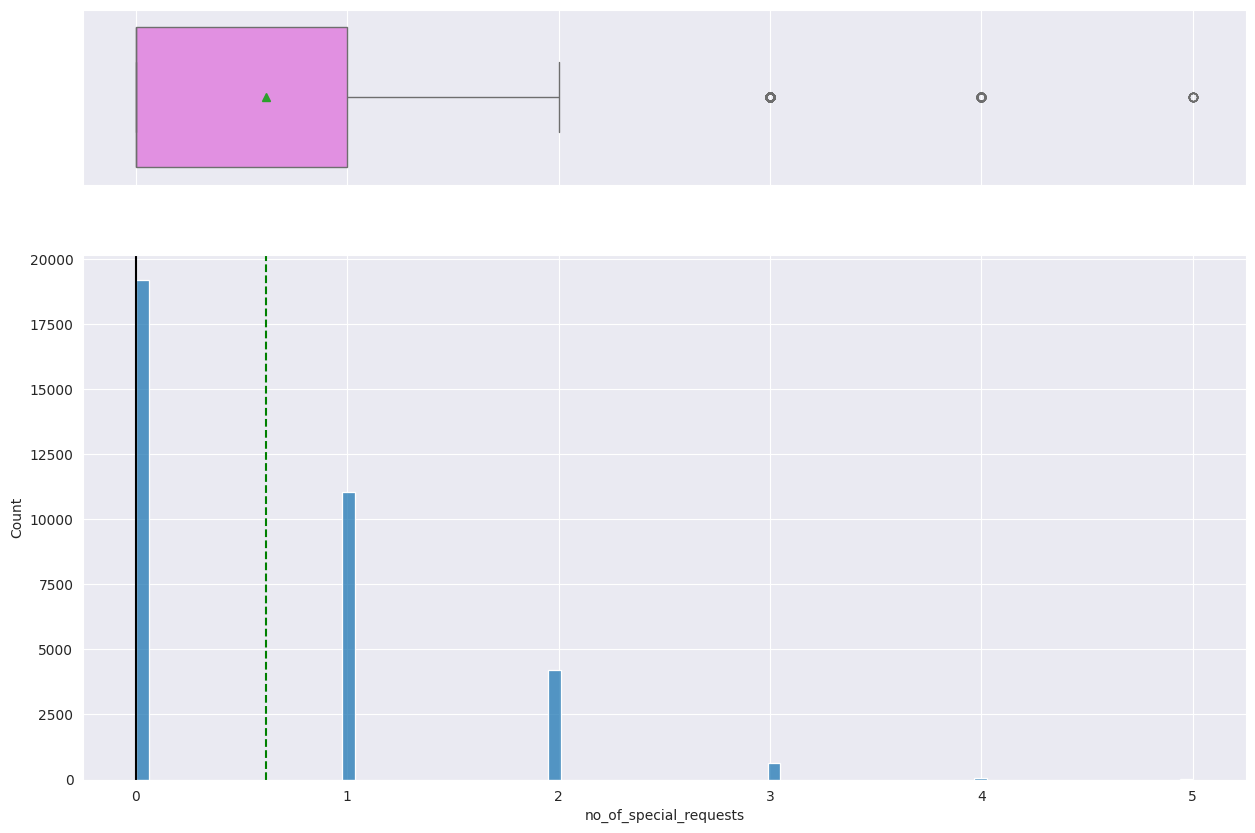

In [104]:
#pull numeric columns from data4
num_cols = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'lead_time', 'arrival_month', 'arrival_date', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']

#use the custom function histogram_boxplot to visualize each columns
for col in num_cols:
  print("\n\n", "="*150,"\n\n")
  histogram_boxplot(data4, col)
  plt.show()


###Observations on numeric data

* Number of adults:  this data is normally distributed.  Since it is discrete, the lower and higher values (0 and 4) appear as outliers.
* Number of children: this data is right skewed with some unually high outliers (10 children).  However, this could be explained by a school group or some other reason this many children are travelling together.  No further exploration is warranted.
* Number of weekend nights: The number of weekend nights is also right skewed. There are a significant number of outliers as the number of weekend nights goes up to 7.  This would only be possible with a long term hotel stay of at least 3 weeks.  This is conceivably possible, but these outliers are a bit concerning.
* Number of week nights:  This data is also right skewed.  Thankfully the outliers (17 days) supports the possibility of a 2.5 week stay, making the weekend night outliers less concerning.
* Lead time: This is right skewed with outliers; however none are unusual.
* arrrival month: this data is not very uniform, suggesting that some months are more common than others.  This warrants further investigation.
* arrival date: also uniform and consistent with expectations
* number of previous cancellations: this data is heavily right skewed with a majority of guests not having cancelled.  These outliers is what this project is attempting to predict.
* number of bookings not cancelled: visually the data is suggestive that most customers in the data set have not used the hotel chain.  Thus, most individuals are one-time travellers versus repeat customers.  This may be something to note in the feature engineering section.
* Average price per room: this data is right skewed with some outliers that are within reasonable price expectations.
* Number of special requests: this is also right skewed.

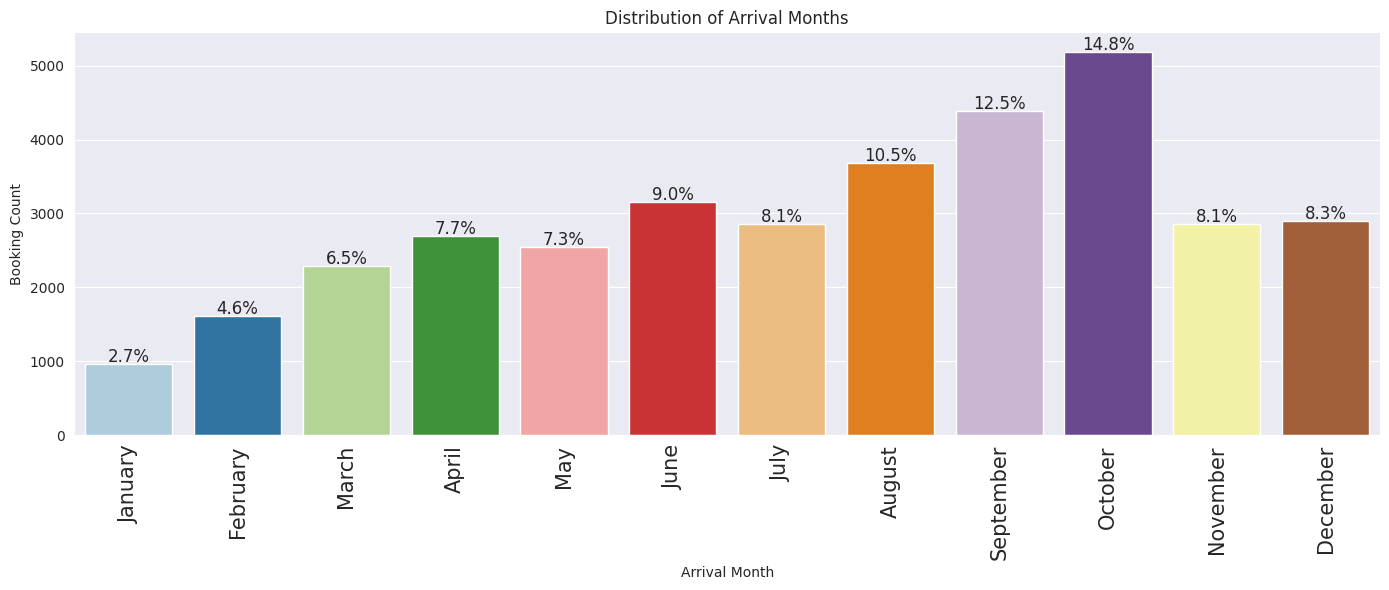

In [105]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(len(months) + 2, 6))

# Get unique month numbers, sorted to ensure chronological order
month_order = sorted(data4['arrival_month'].unique())

ax = sns.countplot(
    data=data4,
    x='arrival_month',
    hue='arrival_month',
    palette="Paired",
    order=month_order,
    legend=False
)

# Set the x-tick labels to month names
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=90, fontsize=15)

# Add percentage annotations
total_bookings = len(data4)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        label = "{:.1f}%".format(100 * height / total_bookings)
        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.xlabel("Arrival Month")
plt.ylabel("Booking Count")
plt.title("Distribution of Arrival Months")
plt.tight_layout()
plt.show()

###Observation on arrival months
The three most common months for booking are in the late summer to early autumn time frame.  August, September, and October account for 37.9% of the bookings for the entire year.  

The least common months are the winter months of January, Febuary, and March: accounting for only 13.9% of the yearly bookings.

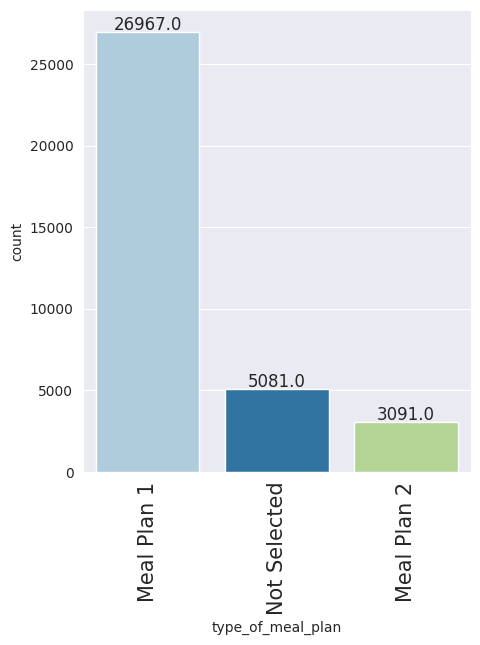

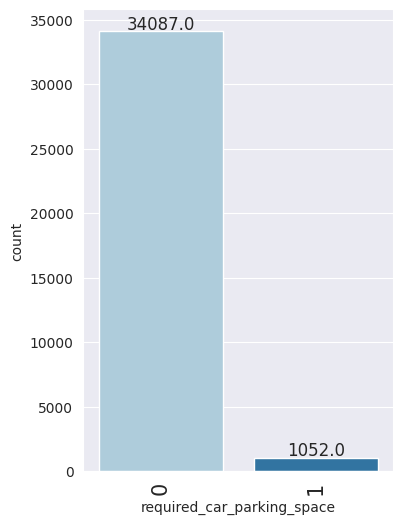

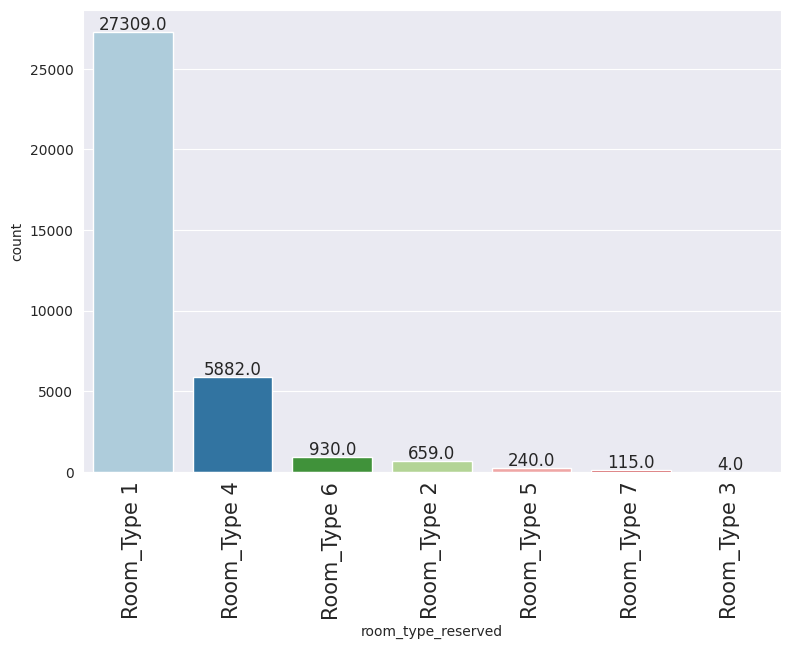

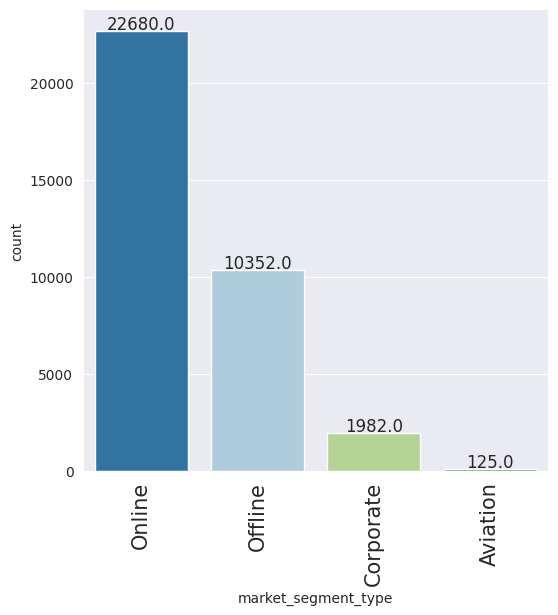

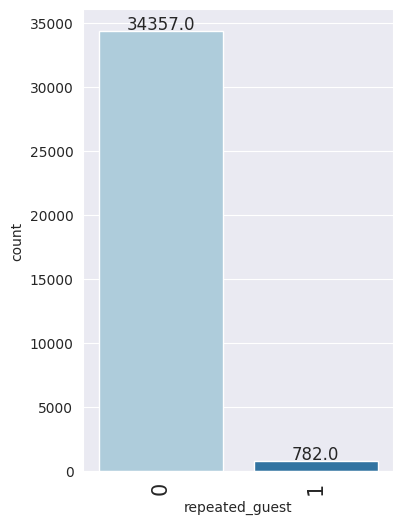

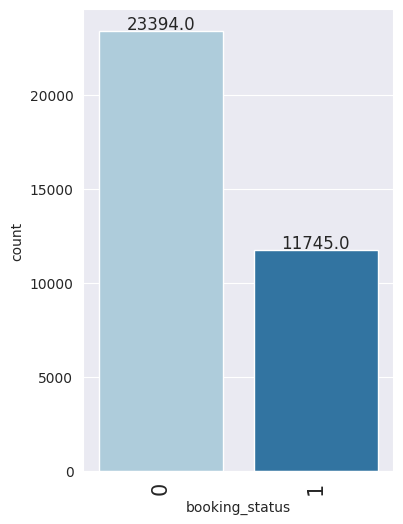

In [106]:
#use the custom function labeled barplot to visualize all the categorical columns from data4
for col in cat_cols:
  print("\n\n", "="*150,"\n\n")
  labeled_barplot(data4, col)
  plt.show()

###Observations on Categorical Data
* Meal plan type 1 was the most popular choice followed by "not selected".  This second category may warrant further investigation.
* Required car parking space: few travelers needed a parking space suggesting that most used some form of public transportation
* Room types:  type 1 was far and away the most popular room choice with Type 4 being a far second place.
* Market segment: online reservations were the most common type made followed by offline.  Corporate and others make us less than 10% of the reservation methods.  This suggests that a majority of the Inn's business comes from individuals rather than corporate accounts.
* Only a small segment of the guests were repeated.  Again, the reasons behind this trend merit further study but are beyond the scope of the current analysis.
* Booking status: this is our dependent variable.  Fully 1/3 of the bookings were cancelled and it is important to figure out why so many bookings have been cancelled over the prvious time period.

In [107]:
#what percent of bookings cancel?
#create a table showing the percent of bookings that cancel and the percent of bookings that do not cancel

cancellation_percentage = data4['booking_status'].value_counts(normalize=True) * 100

print("Booking Cancellation Status Percentages:")
print(round(cancellation_percentage.to_frame(), 2))

Booking Cancellation Status Percentages:
                proportion
booking_status            
0                    66.58
1                    33.42


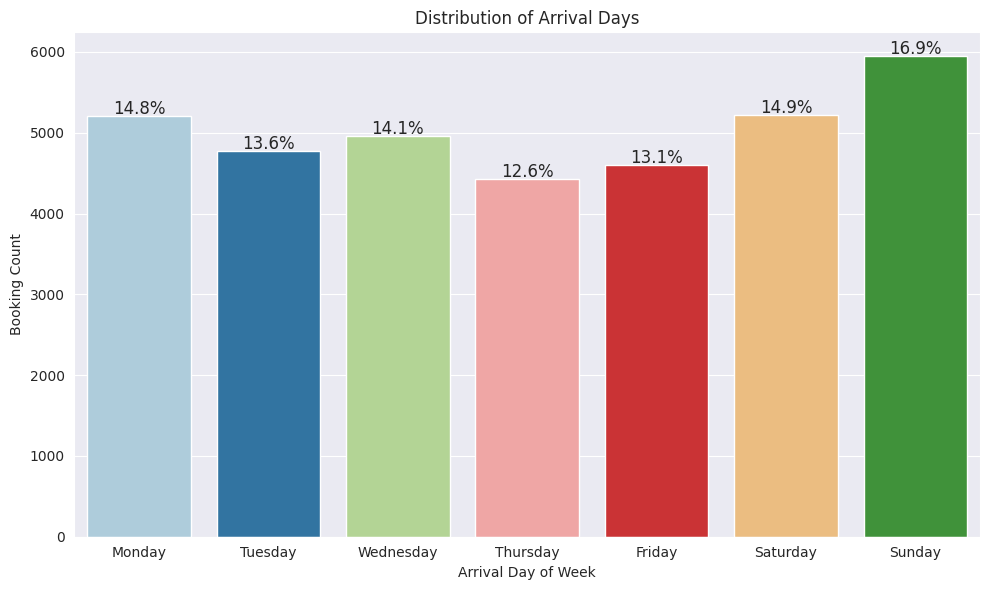

In [108]:
# Define the order of the days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=data5,
    x='arrival_day_of_week',
    hue='arrival_day_of_week', # Used to avoid future deprecation warnings
    palette="Paired",
    order=day_order,
    legend=False
)

# Add percentage annotations
total_bookings = len(data5)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        label = "{:.1f}%".format(100 * height / total_bookings)
        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2, height), # Position of the label
            ha="center", # Horizontal alignment
            va="center", # Vertical alignment
            size=12,
            xytext=(0, 5), # Offset for text
            textcoords="offset points",
        )

plt.xlabel("Arrival Day of Week")
plt.ylabel("Booking Count")
plt.title("Distribution of Arrival Days")
plt.tight_layout()
plt.show()

###Observations on Days of the Week

Sunday is the busiest day for check in and Thursday is the least busy; however, the data is relatively uniform.

<Axes: xlabel='family_trip', ylabel='count'>

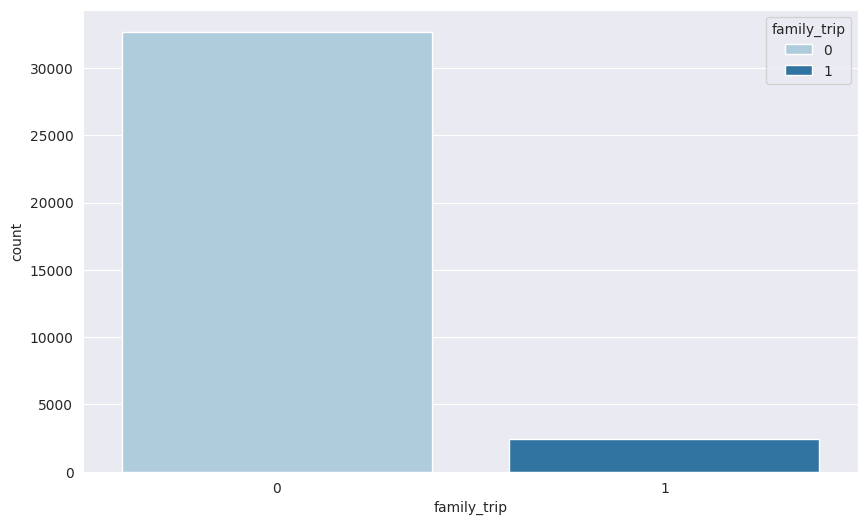

In [109]:
#plot the distribution of family_trip
plt.figure(figsize=(10, 6))
sns.countplot(data=data5, x='family_trip', hue='family_trip', palette="Paired")

##Multivariate Visualizations


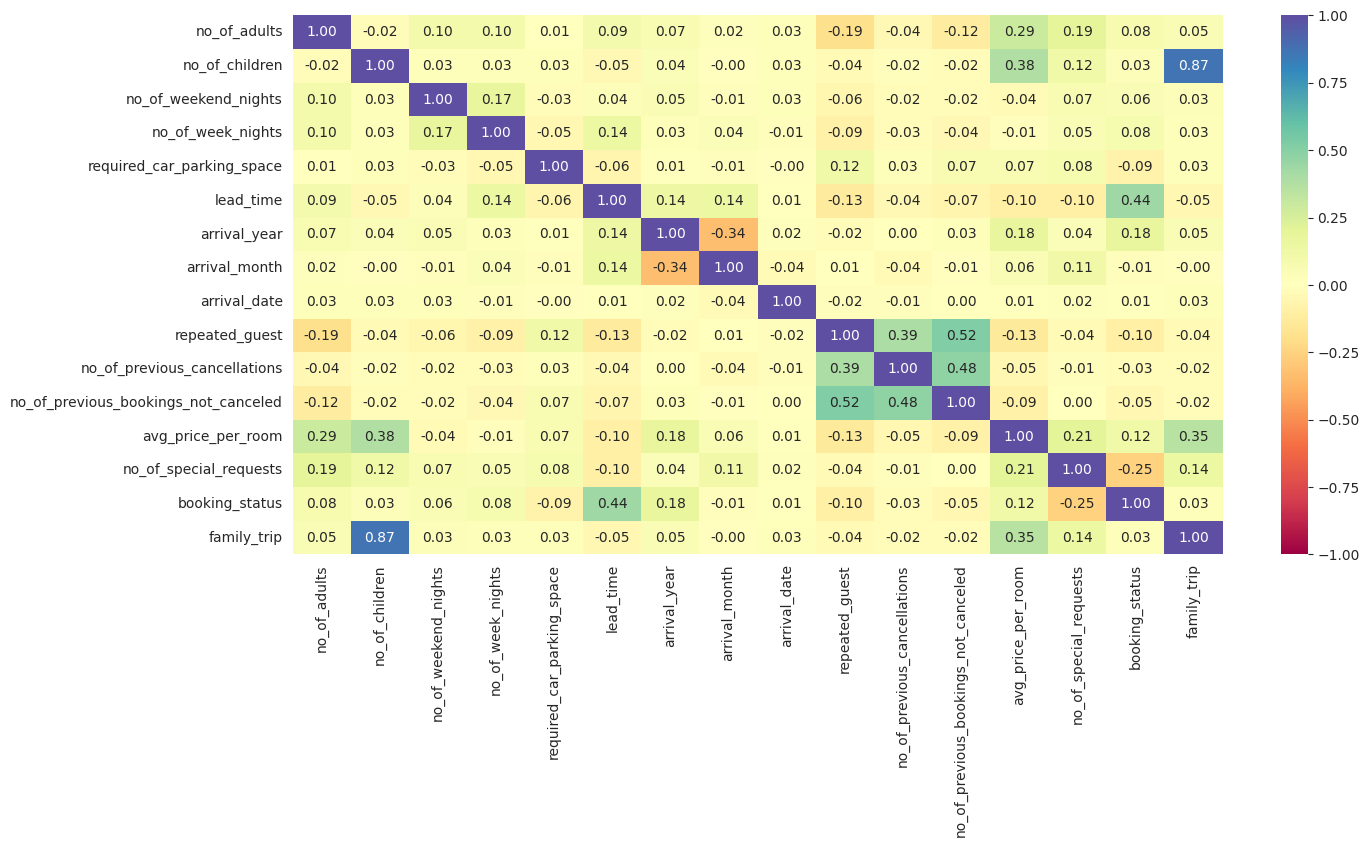

In [110]:
#correlation matrix for numeric values
plt.figure(figsize=(15, 7))
sns.heatmap(data4.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

###Observations on Correlation
Most of the variables are not correlated; however there is a weak correlation between the average price per room and the number of adults and the price with the number of children.  This is a logical correlation since more people usually get charged a higher price.  There is also a moderate positive correlation between lead time and booking status.  Reservations with a greater lead time are correlated with a higher number of cancellations.

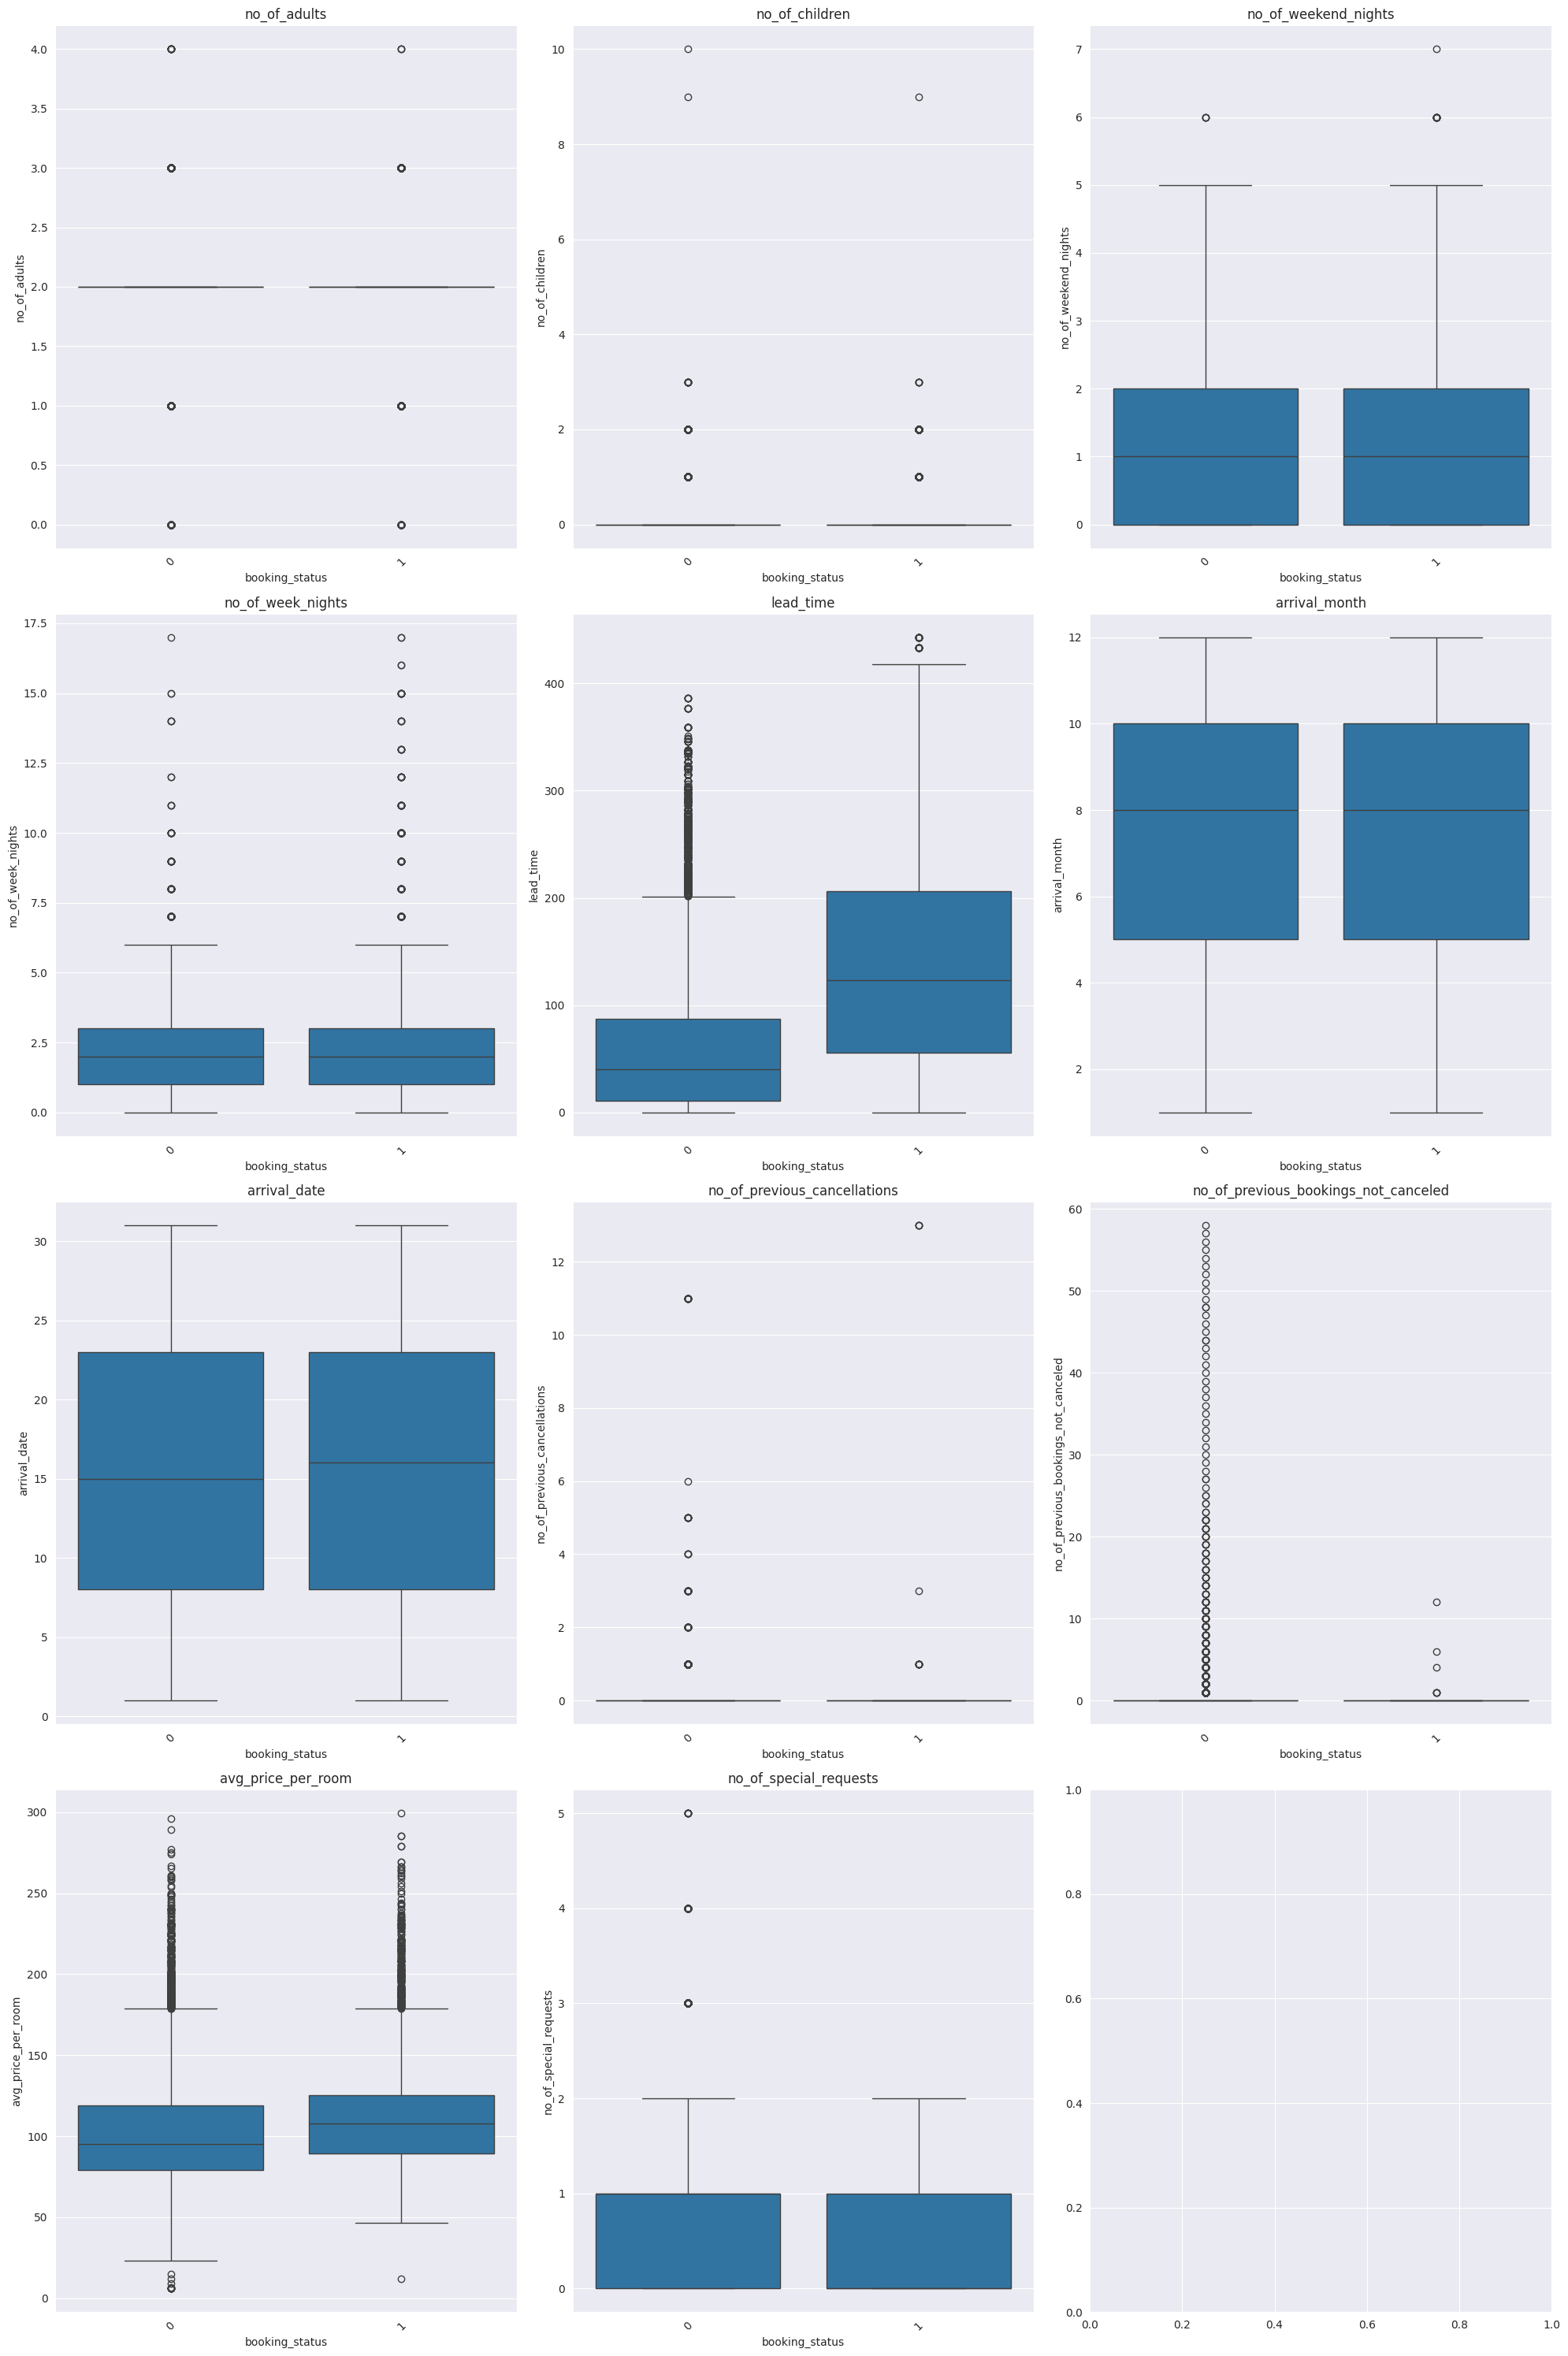

In [111]:
# plot the numeric variable boxplots sorted by the category of booking_status
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20,30))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=data4, x='booking_status', y=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

###Observations on numeric variables by booking status

There is little distinction in most of the numeric variables when sorting by booking status.  However, the one that stands out of that more cancellations occured when a client booked more than two weekday nights.

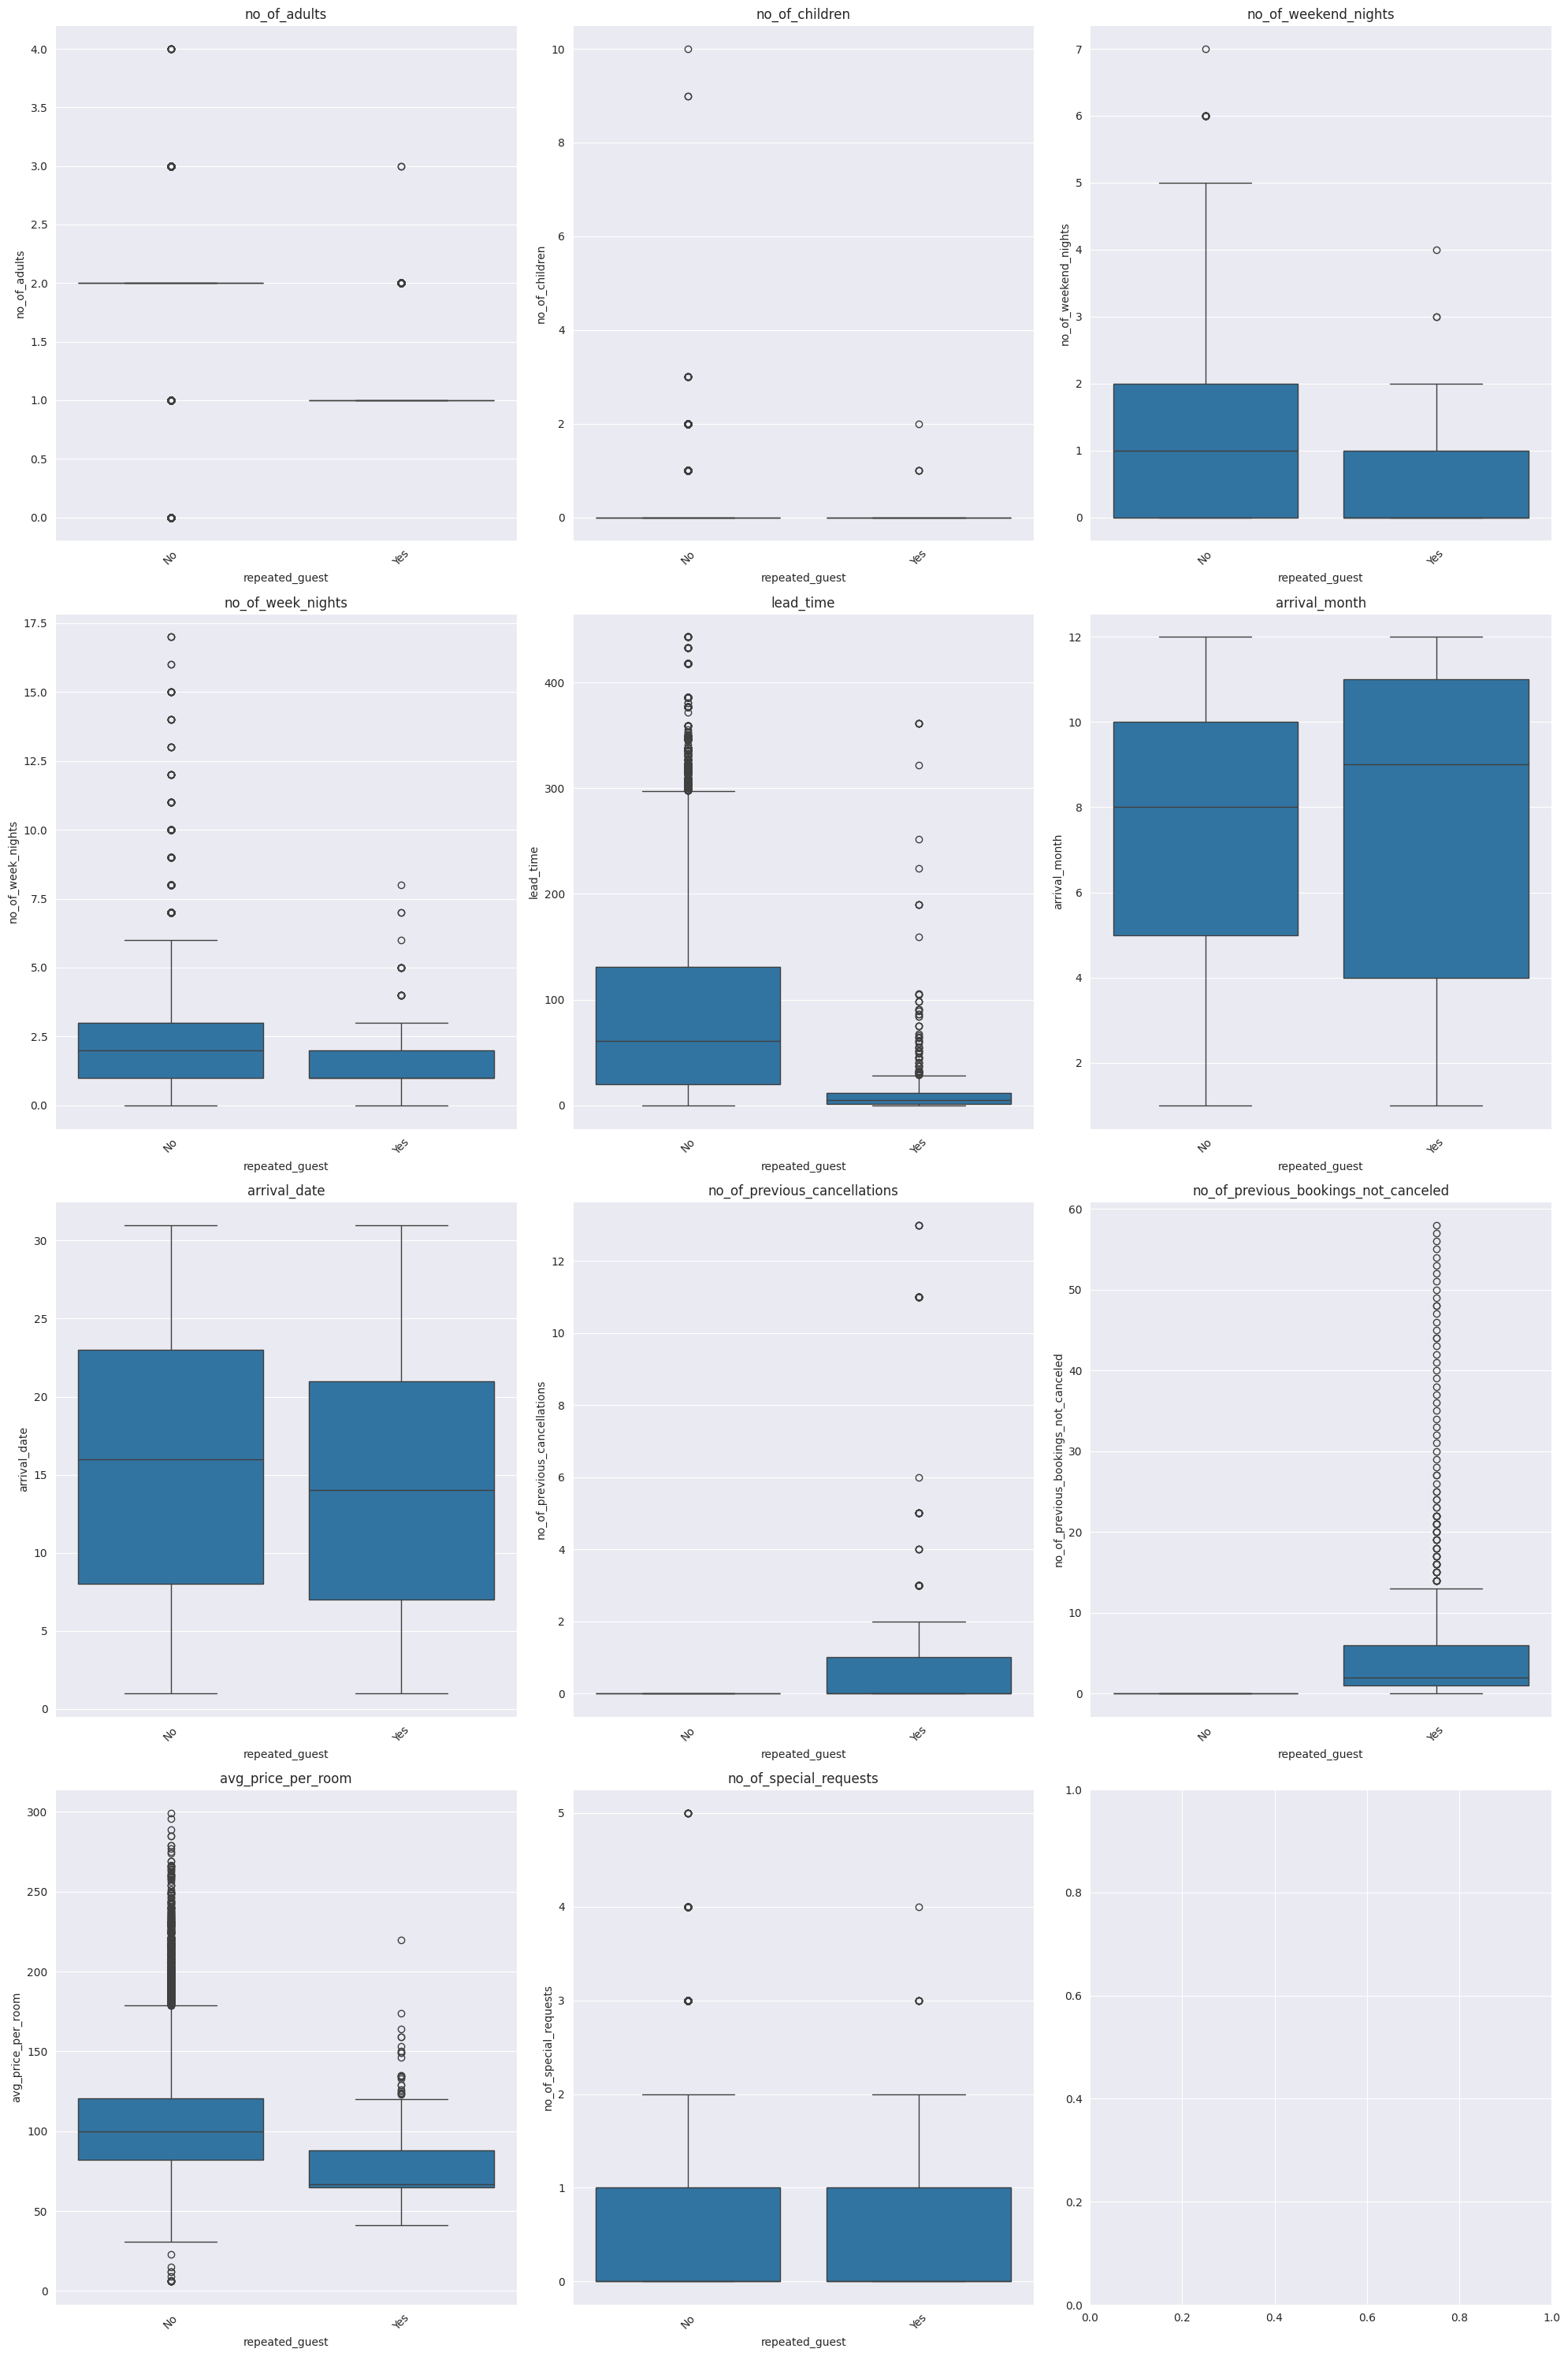

In [112]:
#view numerica data sorted by the repeated guests category
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20,30))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=data4, x='repeated_guest', y=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xticks([0, 1]) # Explicitly set tick locations for 0 and 1
    axes[i].set_xticklabels(['No', 'Yes']) # Set custom labels for 0 and 1

plt.tight_layout()
plt.show()

In [113]:
#display avg_price_per_room sorted by arrival_month
print(data4.groupby('arrival_month')['avg_price_per_room'].mean())
print("\n\n", "="*150,"\n\n")

#display avg_price_per_room sorted by market_segment_type
print(data4.groupby('market_segment_type')['avg_price_per_room'].mean())


arrival_month
1      77.973337
2      82.676660
3      93.099182
4     102.878782
5     114.627103
6     112.597442
7     111.937530
8     113.940353
9     115.877402
10    105.788487
11     91.600745
12     91.258389
Name: avg_price_per_room, dtype: float64




market_segment_type
Aviation     100.704000
Corporate     83.160747
Offline       91.174419
Online       112.358906
Name: avg_price_per_room, dtype: float64


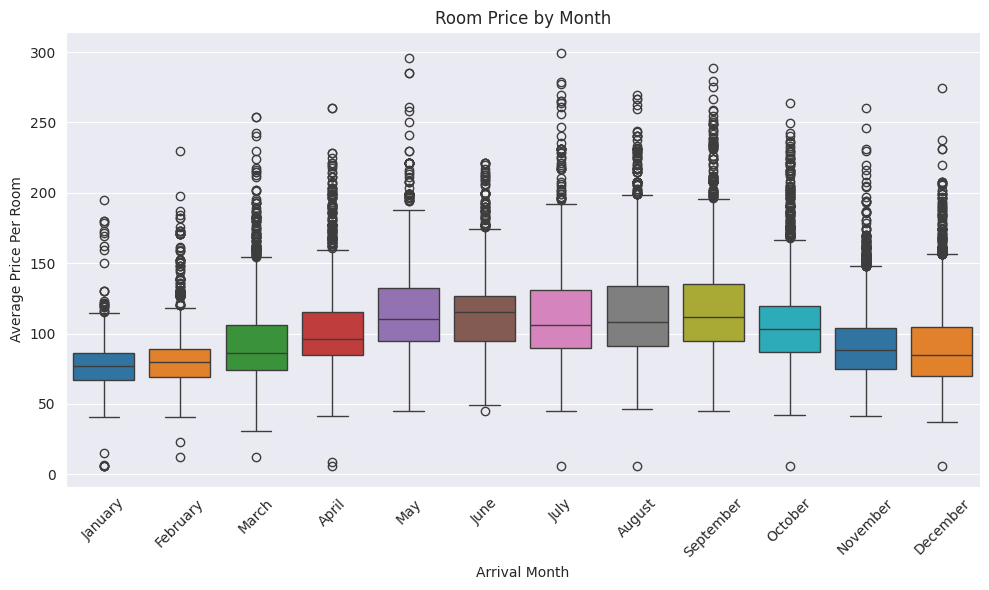

In [114]:
#boxplots for room price sorted by month

plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=data4, x='arrival_month', y='avg_price_per_room', hue = "arrival_month", legend = False, palette='tab10')
plt.title('Room Price by Month')
plt.xlabel('Arrival Month')
# Set the x-tick locations from 0 to 11 (for the 12 months)
ax.set_xticks(range(len(months)))
# Apply the month names as labels to these tick locations
ax.set_xticklabels(months, rotation=45)
plt.ylabel('Average Price Per Room')
plt.tight_layout()
plt.show()

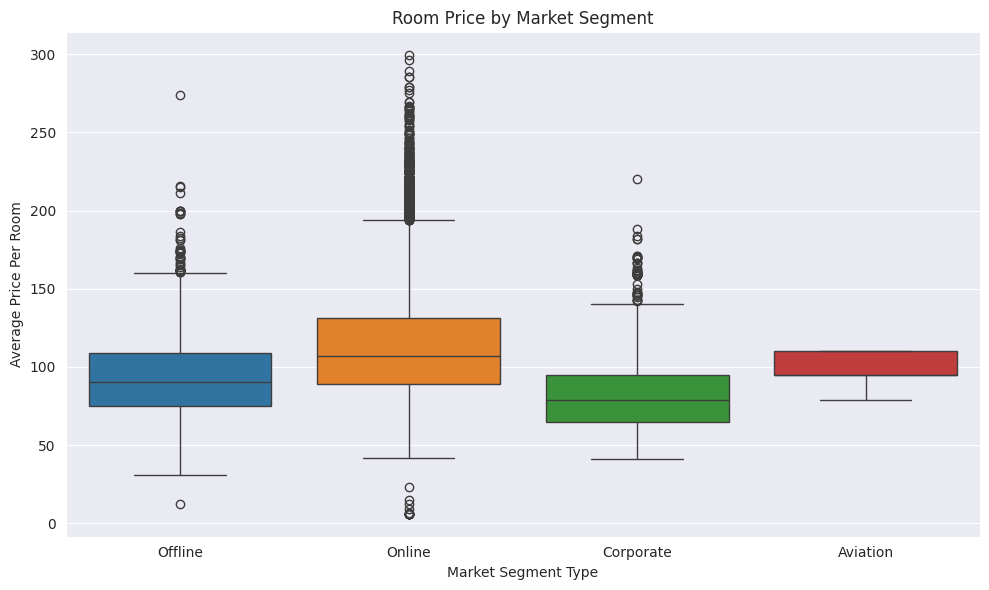

In [115]:
#box plot for room price by market segment type
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=data4, x='market_segment_type', y='avg_price_per_room', hue = "market_segment_type", legend = False, palette='tab10')
plt.title('Room Price by Market Segment')
plt.xlabel('Market Segment Type')
plt.ylabel('Average Price Per Room')
plt.tight_layout()
plt.show()

###Observations on Room price by month and market segment

Overall, there is significant overlap for average room prices when grouped by month and by market segment type. Not surprisingly, the low frequency winter months (as mentioned above) have a lower average price per room, while the popular late summer months have a correspondingly higher average price per room.

For the market segment, the only odd observation is that the median and mean of the online price exceeds that of the offline price.  This is surprising since broad general perception is that online booking will be cheaper than offline since it can be done with automation rather than by a paid staff member.

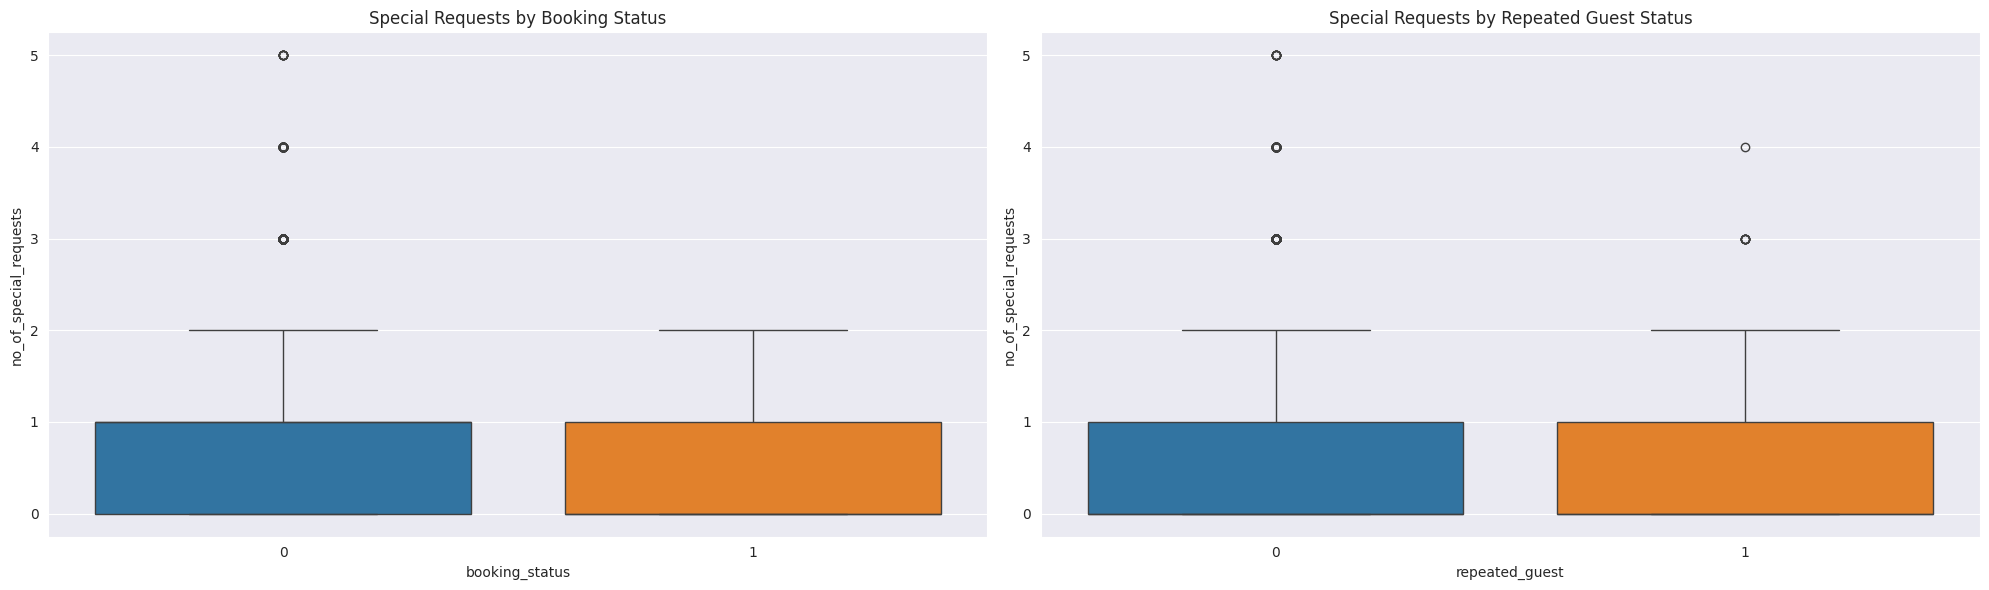





Number of special requests by booking status:
booking_status              0     1
no_of_special_requests             
0                       10766  8434
1                        8348  2683
2                        3561   628
3                         646     0
4                          65     0
5                           8     0




Percentage of special requests by booking status:
booking_status               0      1
no_of_special_requests               
0                        56.07  43.93
1                        75.68  24.32
2                        85.01  14.99
3                       100.00   0.00
4                       100.00   0.00
5                       100.00   0.00




Number of special requests by repeated guest status:
repeated_guest              0    1
no_of_special_requests            
0                       18701  499
1                       10791  240
2                        4154   35
3                         639    7
4                          64    1
5 

In [116]:
#boxplot for number of special requests grouped by booking_status and repeated_guest status on a single grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# Boxplot for number of special requests grouped by booking_status
sns.boxplot(data=data4, x='booking_status', y='no_of_special_requests', hue='booking_status', legend=False, palette='tab10', ax=axes[0])
axes[0].set_title('Special Requests by Booking Status')

# Boxplot for number of special requests grouped by repeated_guest status
sns.boxplot(data=data4, x='repeated_guest', y='no_of_special_requests', hue='repeated_guest', legend=False, palette='tab10', ax=axes[1])
axes[1].set_title('Special Requests by Repeated Guest Status')

plt.tight_layout()
plt.show()

#display table of number of special requests by booking status
print("\n\n", "="*150,"\n\n")
req_status = pd.crosstab(data4['no_of_special_requests'], data4['booking_status'])
print("Number of special requests by booking status:")
print(req_status)

#display same table with row normalization
print("\n\n", "="*150,"\n\n")
print("Percentage of special requests by booking status:")
print(round(req_status.div(req_status.sum(axis=1), axis=0) * 100, 2))


#display table with number of special request by repeat customer status
print("\n\n", "="*150,"\n\n")
req_repeat = pd.crosstab(data4['no_of_special_requests'], data4['repeated_guest'])
print("Number of special requests by repeated guest status:")
print(req_repeat)

#same table with column normalization
print("\n\n", "="*150,"\n\n")
print("Percentage of special requests by repeated guest status:")
print(round(req_repeat.div(req_repeat.sum(axis=0), axis=1) * 100, 2))


###Observation on special requests by booking status
Based on the visualization and summary tables above, the number of special requests made seems to have a large impact on the likelihood of cancellations.  The higher the number of requests made, the less likely a reservation will be cancelled.  There does not appear to be a signficant distinction between special requests and repeated guest status.  This is suggestive of a possible marketing strategy.  The Inn may want to focus on how it will meet guests' individual needs.

In [117]:
#for room price analysis, I will drop the complementary category
no_comps = data4[data4['market_segment_type'] != 'Complementary'].copy()

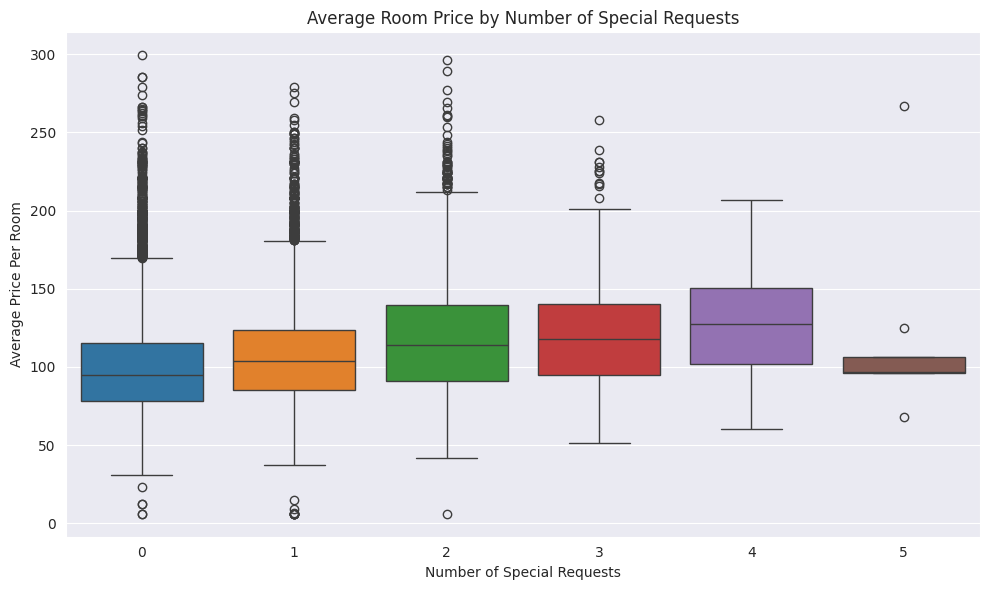

In [118]:
#show how average room price is affected by number of special requests
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=no_comps, x='no_of_special_requests', y='avg_price_per_room', hue='no_of_special_requests', legend=False, palette='tab10')
plt.title('Average Room Price by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Average Price Per Room')
plt.tight_layout()
plt.show()

###Observations on Room Type v Special Requests
The number of special requests does not appear to alter the average room price.

room_type_reserved
Room_Type 1     96.667539
Room_Type 2     89.651608
Room_Type 3    112.687500
Room_Type 4    126.221124
Room_Type 5    131.976708
Room_Type 6    185.057860
Room_Type 7    207.950696
Name: avg_price_per_room, dtype: float64


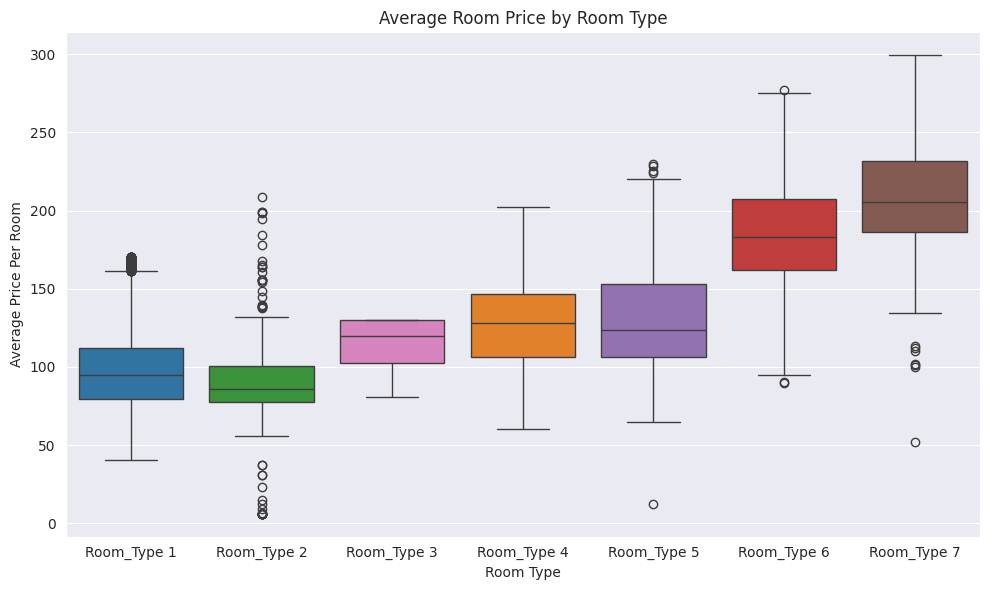

In [119]:
#show average room price by room type
print(no_comps.groupby('room_type_reserved')['avg_price_per_room'].mean())
plt.figure(figsize=(10, 6))
# Define the desired order for room types
room_type_order = ['Room_Type 1', 'Room_Type 2', 'Room_Type 3', 'Room_Type 4', 'Room_Type 5', 'Room_Type 6', 'Room_Type 7']
ax = sns.boxplot(data=no_comps, x='room_type_reserved', y='avg_price_per_room', hue='room_type_reserved', legend=False, palette='tab10', order=room_type_order)
plt.title('Average Room Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price Per Room')
plt.tight_layout()
plt.show()

In [120]:
from scipy.stats import f_oneway
f_stat, p_vale = f_oneway(no_comps[no_comps['room_type_reserved'] == 'Room_Type 1']['avg_price_per_room'],
                          no_comps[no_comps['room_type_reserved'] == 'Room_Type 2']['avg_price_per_room'],
                          no_comps[no_comps['room_type_reserved'] == 'Room_Type 3']['avg_price_per_room'],
                          no_comps[no_comps['room_type_reserved'] == 'Room_Type 4']['avg_price_per_room'],
                          no_comps[no_comps['room_type_reserved'] == 'Room_Type 5']['avg_price_per_room'],
                          no_comps[no_comps['room_type_reserved'] == 'Room_Type 6']['avg_price_per_room'],
                          no_comps[no_comps['room_type_reserved'] == 'Room_Type 7']['avg_price_per_room'])
print("F-statistic:", f_stat)
print("p-value:", p_vale)

F-statistic: 3257.1080899447957
p-value: 0.0


In [121]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=no_comps['avg_price_per_room'],
                                   groups=no_comps['room_type_reserved'],
                                   alpha=0.05)

print(tukey_result)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj   lower    upper   reject
----------------------------------------------------------------
Room_Type 1 Room_Type 2  -7.0159    0.0  -9.9014  -4.1305   True
Room_Type 1 Room_Type 3    16.02 0.8566 -20.5799  52.6198  False
Room_Type 1 Room_Type 4  29.5536    0.0  28.5014  30.6057   True
Room_Type 1 Room_Type 5  35.3092    0.0  30.5638  40.0546   True
Room_Type 1 Room_Type 6  88.3903    0.0  85.9497   90.831   True
Room_Type 1 Room_Type 7 111.2832    0.0 104.4434 118.1229   True
Room_Type 2 Room_Type 3  23.0359 0.5138 -13.6722   59.744  False
Room_Type 2 Room_Type 4  36.5695    0.0  33.5628  39.5762   True
Room_Type 2 Room_Type 5  42.3251    0.0  36.8068  47.8434   True
Room_Type 2 Room_Type 6  95.4063    0.0  91.6793  99.1332   True
Room_Type 2 Room_Type 7 118.2991    0.0 110.9021 125.6961   True
Room_Type 3 Room_Type 4  13.5336 0.9313  -23.076  50.1433  False
Room_Type 3 Room_Type 5  

###Observations on price v room type
There are significant differences between the price of a room and the room price.  Since our sample size is so large, we had a big F-statistic and a very low p-value (F = 2578.74, p-val ≈ 0).  Running a Tukey HSD post-hoc test showed that all rooms were significantly different from each other with one notable exception.  Room type 3 was not significantly different from any of the other rooms.  This may be due to a lack of data but warrants further investigation.  Additionally, one of the outliers that appears here is concerning.  There is an outlier in Room_Type_1 that is more than 5 times larger than the mean of the Room 1 price.  This needs to be dealt with.

In [122]:
#show the overall percentage of bookings that were cancelled
print("Percentage of bookings that were cancelled")
cancelled_bookings = data4['booking_status'].value_counts(normalize=True) * 100
print(round(cancelled_bookings, 2))

#show the percentage of no_of_previous_cancellations for repeated_guest
print("\n\n", "="*150,"\n\n")
print("Percentage of previous cancellations for repeated guests:")
repeated_guest_cancellations = pd.crosstab(data4['no_of_previous_cancellations'], data4['repeated_guest'],  normalize='index') * 100
print(round(repeated_guest_cancellations, 2))


#show the count of cancellations by repeat status
print("\n\n", "="*150,"\n\n")
print("Count of repeated guests and cancellations:")
rep_guests = pd.crosstab(data4['repeated_guest'], data4['booking_status'])
print(rep_guests)

#show the conditional proportion (as a %) of booking_status | repeated_guests
print("\n\n", "="*150,"\n\n")
print("Percentage of booking cancellations for repeated guests:")
rep_guests_cancellations = pd.crosstab(data4['repeated_guest'], data4['booking_status'], normalize='columns') * 100
print(round(rep_guests_cancellations, 2))


Percentage of bookings that were cancelled
booking_status
0    66.58
1    33.42
Name: proportion, dtype: float64




Percentage of previous cancellations for repeated guests:
repeated_guest                    0       1
no_of_previous_cancellations               
0                             98.61    1.39
1                              0.00  100.00
2                              0.00  100.00
3                              0.00  100.00
4                              0.00  100.00
5                              0.00  100.00
6                              0.00  100.00
11                             0.00  100.00
13                             0.00  100.00




Count of repeated guests and cancellations:
booking_status      0      1
repeated_guest              
0               22627  11730
1                 767     15




Percentage of booking cancellations for repeated guests:
booking_status      0      1
repeated_guest              
0               96.72  99.87
1                3.28   0.13


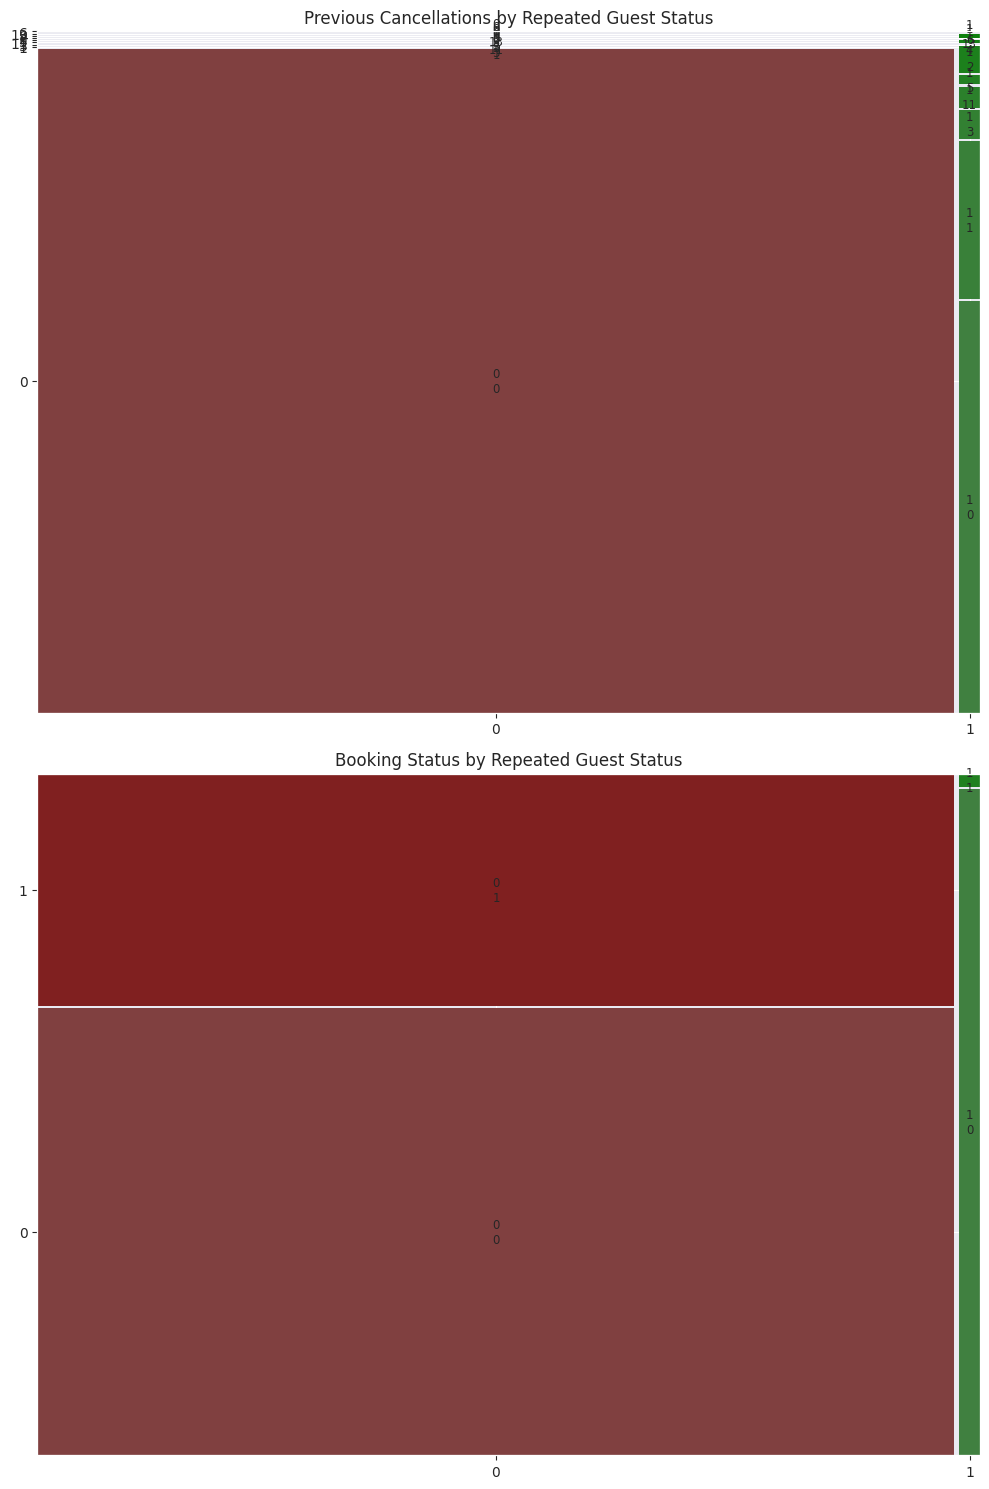

In [123]:
from statsmodels.graphics.mosaicplot import mosaic

# Set a brighter color cycle for matplotlib plots
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=sns.color_palette('viridis', n_colors=9)) # 9 is enough for max unique values in previous cancellations

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 15)) # 2 rows, 1 col, adjusted figsize

# Mosaic plot for no_of_previous_cancellations by repeated_guest
plt.sca(axes[0]) # Set the current axes for plotting
mosaic(data4, ['repeated_guest', 'no_of_previous_cancellations'], ax=axes[0], title='Previous Cancellations by Repeated Guest Status')

# Mosaic plot for booking_status by repeated_guest
plt.sca(axes[1]) # Set the current axes for plotting
mosaic(data4, ['repeated_guest', 'booking_status'], ax=axes[1], title='Booking Status by Repeated Guest Status')

plt.tight_layout()
plt.show()

###Observations on data from repeated guests
Overall, repeated guests had much lower lead time than first time visitors.  Additionally, they paid less per the room overall.

The overwhelming majority of cancelaltions come from new guests.  Repeated guests have a very low cancellation rate of 0.13%.  This suggests that once the chain manages to convert a guest to their brand, they have a very high retention rate for future bookings.

I attempted to display the data in the tables as a mosaic plot, but the small size of the values of requests relative to the number of observations makes readability a challenge.

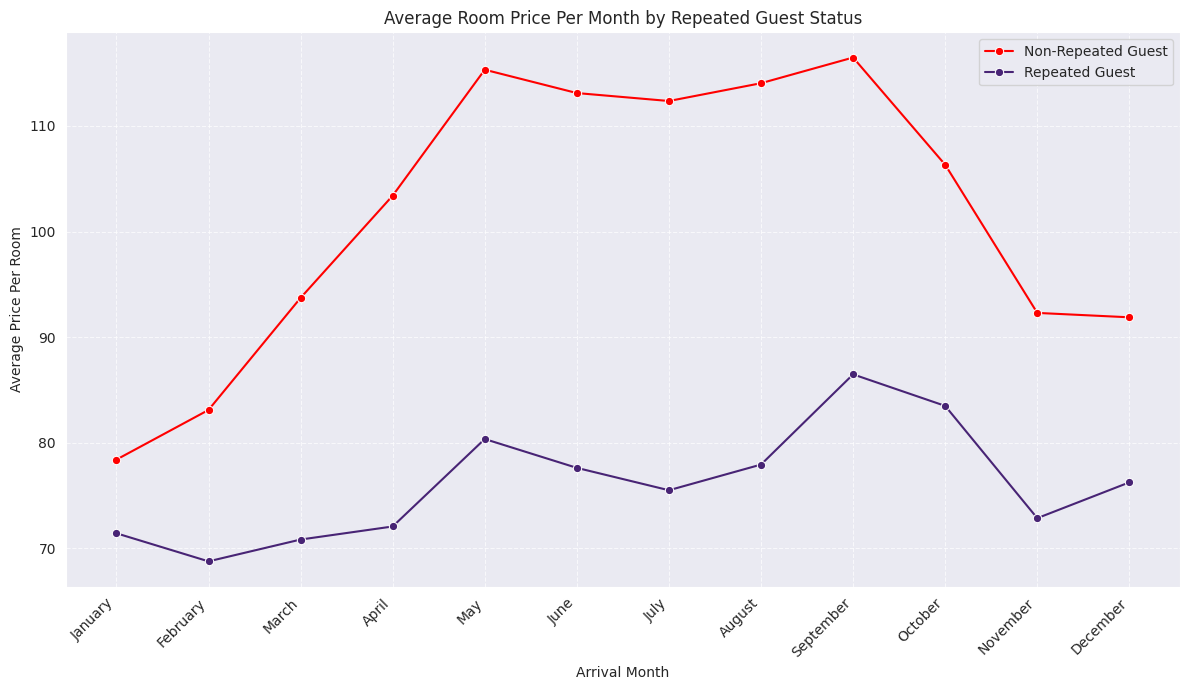

In [124]:
#create a time series of average room price by month, grouped by repeated_guest

# Group by arrival_month and repeated_guest, then calculate the mean of avg_price_per_room
price_by_month_guest = data4.groupby(['arrival_month', 'repeated_guest'])['avg_price_per_room'].mean().unstack()

# Plotting the time series
plt.figure(figsize=(12, 7))

# Plot for non-repeated guests (repeated_guest = 0)
sns.lineplot(x=price_by_month_guest.index, y=price_by_month_guest[0], marker='o', label='Non-Repeated Guest', color = "red")

# Plot for repeated guests (repeated_guest = 1)
sns.lineplot(x=price_by_month_guest.index, y=price_by_month_guest[1], marker='o', label='Repeated Guest')

plt.title('Average Room Price Per Month by Repeated Guest Status')
plt.xlabel('Arrival Month')
plt.ylabel('Average Price Per Room')

# Use the 'months' list defined earlier for x-axis labels
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xticks(ticks=range(1, 13), labels=months, rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

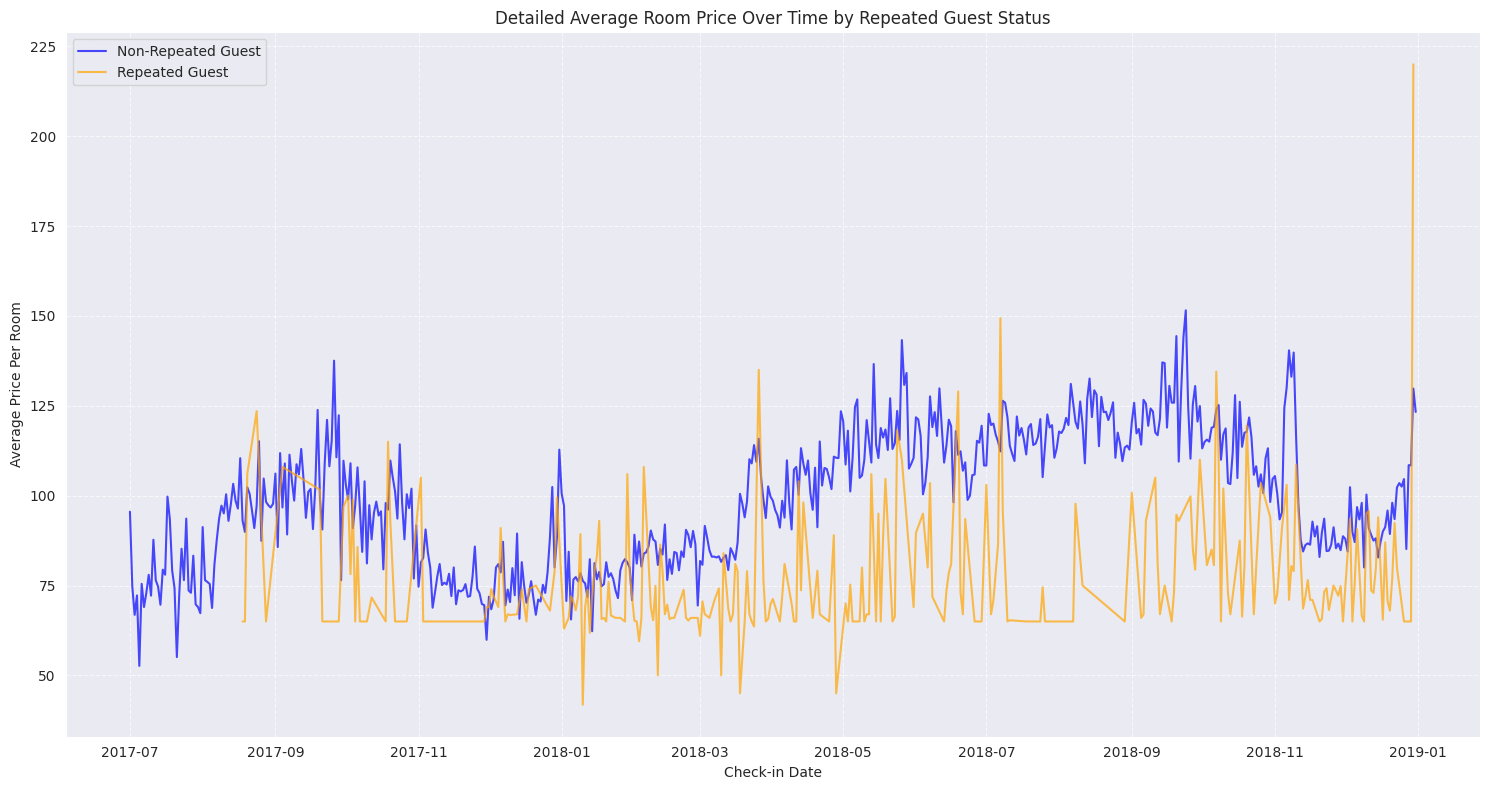

In [125]:
# Group by Check_in_date and repeated_guest, then calculate the mean of avg_price_per_room
price_by_date_guest = data4.groupby(['Check_in_date', 'repeated_guest'])['avg_price_per_room'].mean().unstack()

# Plotting the detailed time series
plt.figure(figsize=(15, 8))

# Plot for non-repeated guests (repeated_guest = 0)
sns.lineplot(x=price_by_date_guest.index, y=price_by_date_guest[0], label='Non-Repeated Guest', color='blue', alpha=0.7)

# Plot for repeated guests (repeated_guest = 1)
sns.lineplot(x=price_by_date_guest.index, y=price_by_date_guest[1], label='Repeated Guest', color='orange', alpha=0.7)

plt.title('Detailed Average Room Price Over Time by Repeated Guest Status')
plt.xlabel('Check-in Date')
plt.ylabel('Average Price Per Room')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

###Observations on room price by guest type
These two time series show the room price over time for both repeated and first time guests.  Overall, both graphs show that first time guests pay more for their rooms than refpeated guests.  The cost trends over the course of the year are similar for the two groups with the high frequency months are more expensive than the low frequency months.  However, first time customers see a much greater spike in their costs over these months than do repeat guests.  This discrepancy may be good for maintaining brand loyalty, but may be a cause of the cancellations.

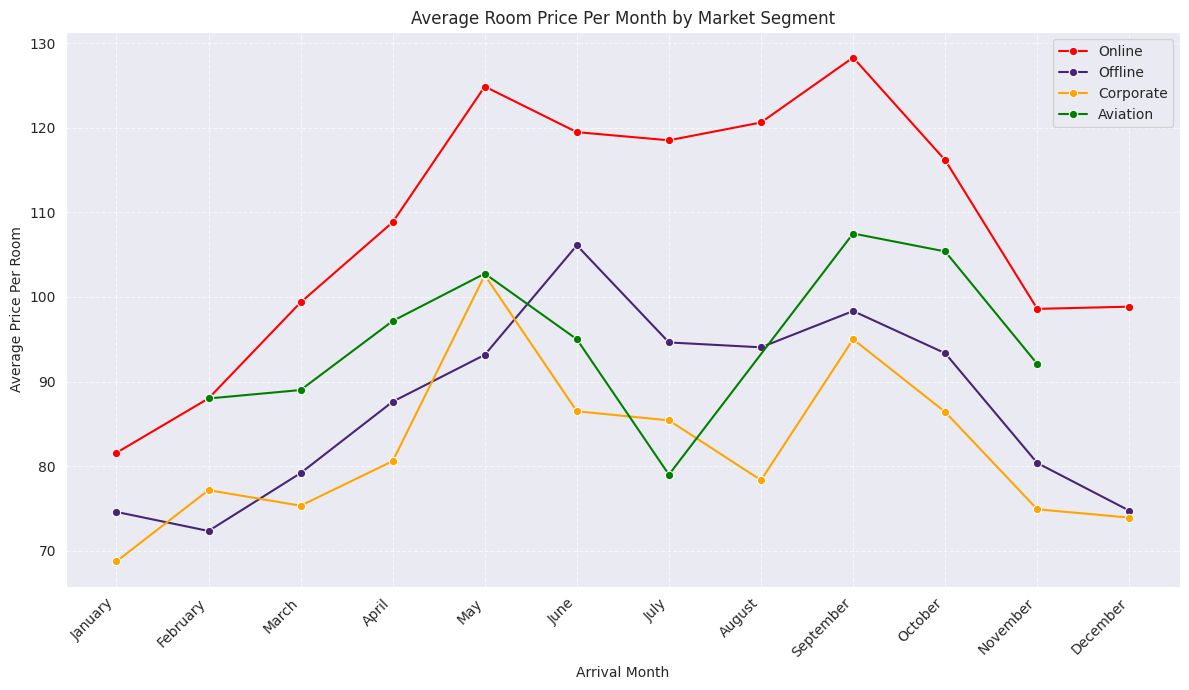

In [126]:
#create a time series of average room price by month, grouped by market segment

# Group by arrival_month and repeated_guest, then calculate the mean of avg_price_per_room
price_by_month_market = data4.groupby(['arrival_month', 'market_segment_type'])['avg_price_per_room'].mean().unstack()

# Plotting the time series
plt.figure(figsize=(12, 7))

# Plot for online
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market['Online'], marker='o', label='Online', color = "red")

# Plot for offline (repeated_guest = 1)
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Offline"], marker='o', label='Offline')

# Plot for corporate
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Corporate"], marker='o', label='Corporate', color = "orange")

# Plot for aviation
sns.lineplot(x=price_by_month_market.index, y=price_by_month_market["Aviation"], marker='o', label='Aviation', color = "green")

plt.title('Average Room Price Per Month by Market Segment')
plt.xlabel('Arrival Month')
plt.ylabel('Average Price Per Room')

# Use the 'months' list defined earlier for x-axis labels
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xticks(ticks=range(1, 13), labels=months, rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

###Observations on Room Price by Market Segment
Ovearll, online reservations showed the highest average price on a month by month basis.  The next highest was aviation overall, but with a dip during June and July.  Offline reservations trended close to the corporate cost, but was slightly higher than corporate costs nearly every month.

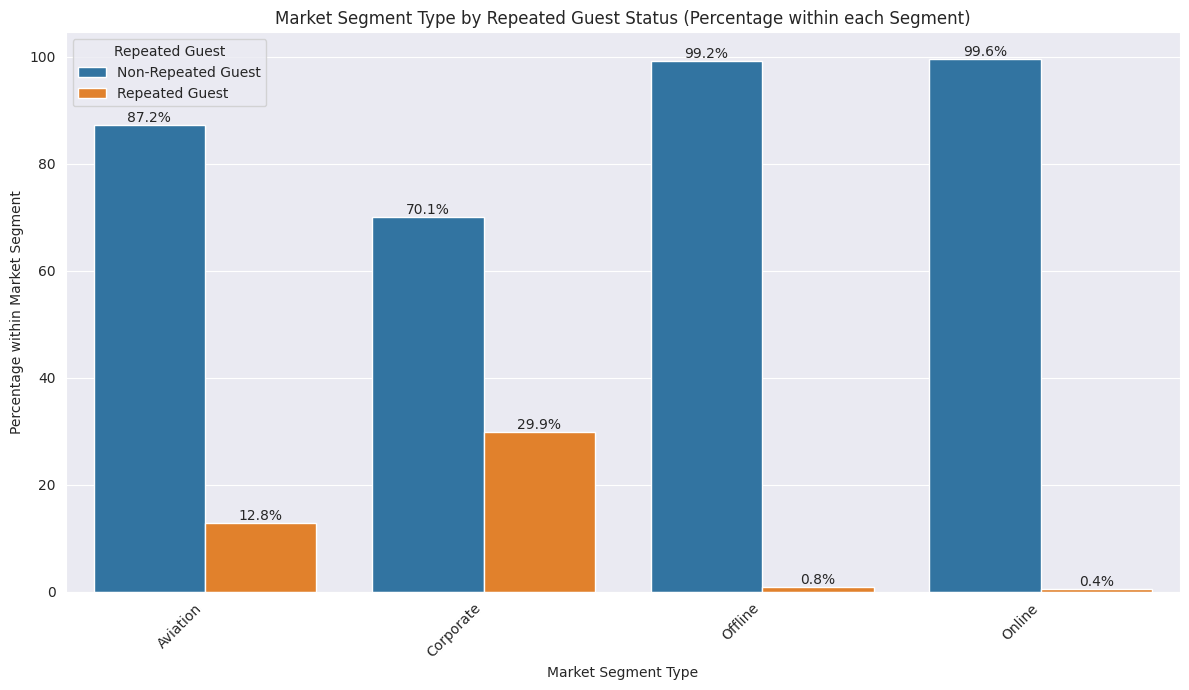

In [127]:
# Calculate counts for each combination of market_segment_type and repeated_guest
segment_guest_counts = data4.groupby(['market_segment_type', 'repeated_guest']).size().reset_index(name='count')

# Calculate the total count for each market_segment_type
total_segment_counts = segment_guest_counts.groupby('market_segment_type')['count'].transform('sum')

# Calculate percentages relative to the total of each market_segment_type
segment_guest_counts['percentage'] = 100 * segment_guest_counts['count'] / total_segment_counts

plt.figure(figsize=(12, 7))

# Use barplot with the calculated percentages
ax = sns.barplot(
    data=segment_guest_counts,
    x='market_segment_type',
    y='percentage',
    hue='repeated_guest',
    palette='tab10'
)

plt.title('Market Segment Type by Repeated Guest Status (Percentage within each Segment)')
plt.xlabel('Market Segment Type')
plt.ylabel('Percentage within Market Segment')

# Customize legend labels for repeated_guest
hue_labels = {0: 'Non-Repeated Guest', 1: 'Repeated Guest'}
handles, labels = ax.get_legend_handles_labels()
new_labels = [hue_labels[int(label)] for label in labels]
ax.legend(handles=handles, labels=new_labels, title='Repeated Guest')

plt.xticks(rotation=45, ha='right')

# Add percent value at the top of each bar
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0.01: # Avoid annotating very small or NaN bars
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 5), # 5 points vertical offset
                    textcoords="offset points",
                    fontsize=10)

plt.tight_layout()
plt.show()

###Observations on Market Segment Type by Repeated Guests

Overall, repeat guest make up a miniscule percent of the online and offline reservations (1.3%).  Most repeated guests appear either in the aviation, complementary, or corporate categories.  This suggests that repeated guests may be from a pool of guests who do not necessarily have a choice in their hotels (assuming corporate contracts with the hotel chain).

In [128]:
#Analysis of families (guests with children)
family_data = data4[(data4["no_of_children"] >= 0) & (data4["no_of_adults"] > 1)].copy()
family_data["no_of_family_members"] = (
    family_data["no_of_adults"] + family_data["no_of_children"]
)
family_data.shape

(27759, 22)

booking_status            0     1    All
no_of_family_members                    
2                     15077  8143  23220
3                      2325  1320   3645
4                       487   392    879
5                         8     5     13
11                        0     1      1
12                        1     0      1
All                   17898  9861  27759
------------------------------------------------------------------------------------------------------------------------


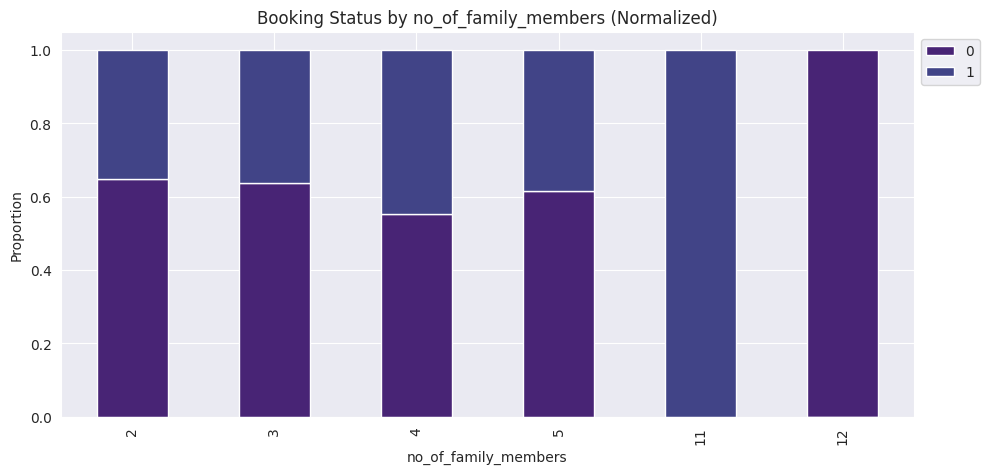

In [129]:
# Use the custom function stacked_barplot for number of family members and booking status
# To maintain the natural numeric order of 'no_of_family_members', we'll manually create and sort the data for plotting.

predictor = "no_of_family_members"
target = "booking_status"

# Calculate count of unique family members for figsize
count = family_data[predictor].nunique()

# Create the first table (absolute counts with margins)
# pd.crosstab naturally sorts numerical indices and places 'All' at the end.
tab1 = pd.crosstab(family_data[predictor], family_data[target], margins=True)
print(tab1)
print("-" * 120)

# Create the second table (normalized percentages), and sort its numerical index
tab = pd.crosstab(family_data[predictor], family_data[target], normalize="index")
tab = tab.sort_index(ascending=True)

# Plot the stacked bar chart
tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
plt.legend(
    loc="lower left", frameon=False,
)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.title(f'Booking Status by {predictor} (Normalized)')
plt.xlabel(predictor)
plt.ylabel('Proportion')
plt.show()

###Observations on Family Cancellations
Family size does not visually appear to be correlated with the number of cancellations.

booking_status           0      1    All
arrival_day_of_week                     
All                  23394  11745  35139
Sunday                3668   2278   5946
Saturday              3533   1688   5221
Wednesday             3302   1661   4963
Monday                3576   1627   5203
Tuesday               3206   1571   4777
Friday                3106   1499   4605
Thursday              3003   1421   4424
------------------------------------------------------------------------------------------------------------------------


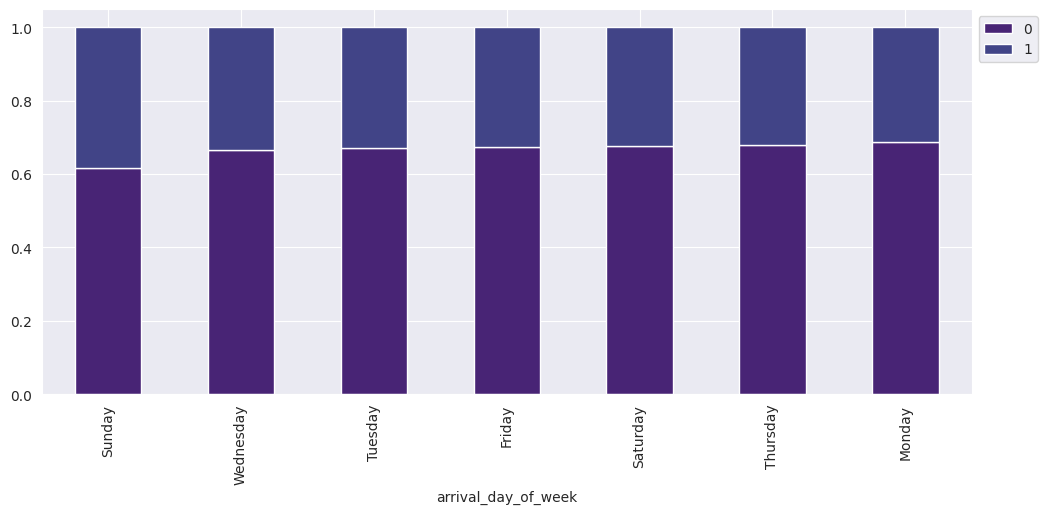

In [130]:
predictor = "arrival_day_of_week"
target = "booking_status"

stacked_barplot(data5, predictor, target)

###Observations on Cancellations and Day of the Week
There does not appear to be any association between day of the week and cancellations. Visually, only Sunday appears to have a slightly higher incidence of cancelled reservations.

In [131]:
stay_data = data4[(data4["no_of_week_nights"] > 0) & (data4["no_of_weekend_nights"] > 0)].copy()
stay_data["total_nights"] = (
    stay_data["no_of_week_nights"] + stay_data["no_of_weekend_nights"]
)
stay_data.shape

(16701, 22)

repeated_guest      0    1    All
total_nights                     
2                1822   53   1875
3                5655   67   5722
4                4234   21   4255
5                2293    6   2299
6                1016    2   1018
7                 952    6    958
8                 176    1    177
9                 109    0    109
10                106    2    108
11                 39    0     39
12                 22    1     23
13                 18    0     18
14                 30    0     30
15                 31    0     31
16                  5    0      5
17                  5    0      5
18                  3    0      3
19                  6    0      6
20                 11    0     11
21                  4    0      4
22                  2    0      2
23                  2    0      2
24                  1    0      1
All             16542  159  16701
--------------------------------------------------------------------------------------------------------------------

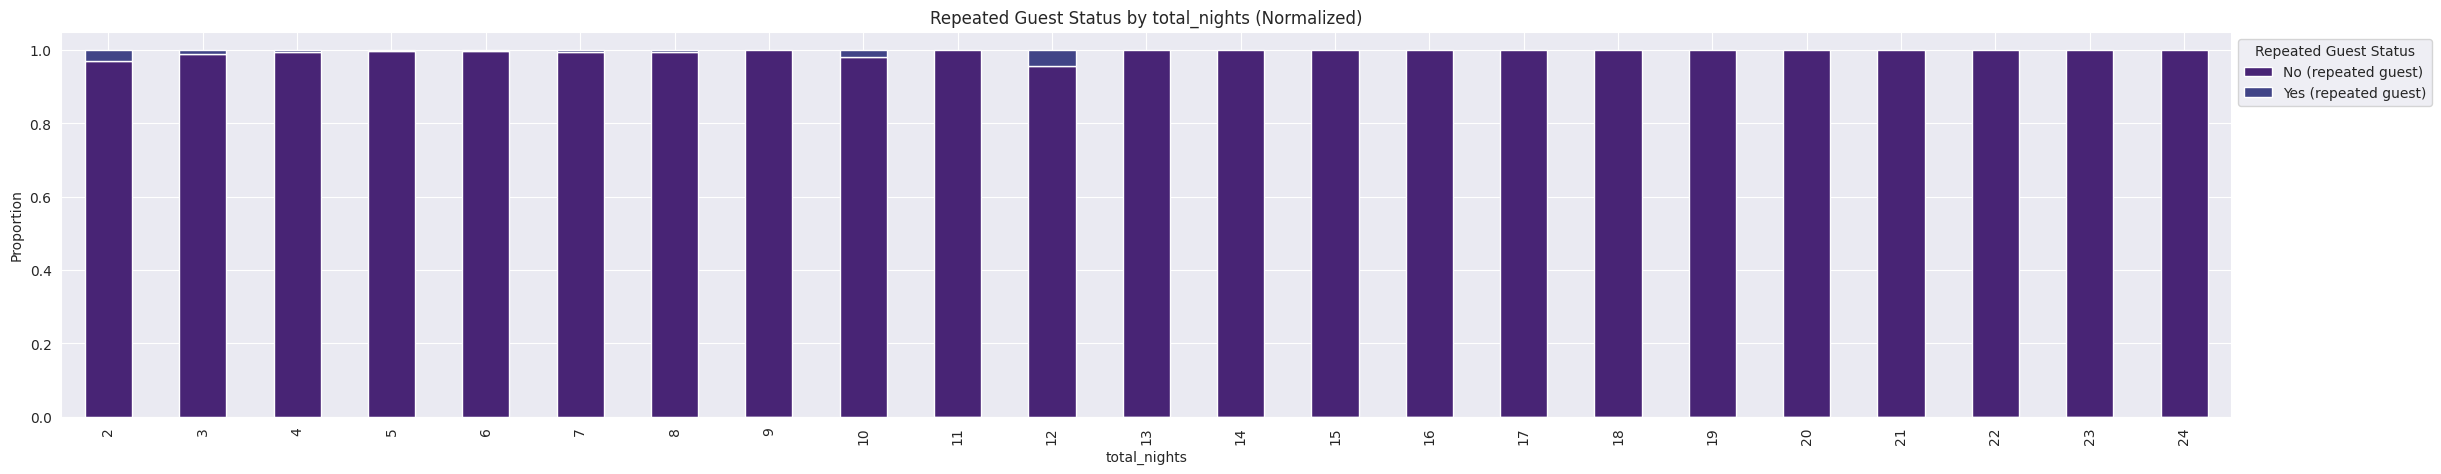

In [132]:
# Stacked barplot for repeated guests and total nights, maintaining natural order

predictor = "total_nights"
target = "repeated_guest"

# Calculate count of unique total nights for figsize
count = stay_data[predictor].nunique()

# Create the first table (absolute counts with margins)
# pd.crosstab naturally sorts numerical indices and places 'All' at the end.
tab1 = pd.crosstab(stay_data[predictor], stay_data[target], margins=True)
print(tab1)
print("-" * 120)

# Create the second table (normalized percentages), and sort its numerical index
tab = pd.crosstab(stay_data[predictor], stay_data[target], normalize="index")
tab = tab.sort_index(ascending=True)

# Plot the stacked bar chart
ax = tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
plt.legend(
    loc="lower left", frameon=False,
)

# Customize legend labels for repeated_guest (0: No, 1: Yes)
handles, labels = ax.get_legend_handles_labels()
new_labels = ['No (repeated guest)', 'Yes (repeated guest)']
ax.legend(handles=handles, labels=new_labels, title='Repeated Guest Status', loc='upper left', bbox_to_anchor=(1, 1))

plt.title(f'Repeated Guest Status by {predictor} (Normalized)')
plt.xlabel(predictor)
plt.ylabel('Proportion')
plt.show()

###Observation of Number of nights combined with repeated_guest
There does not appear to be a strong link between repeated guests and the number of nights.

 To jump back to the EDA summary section, click <a href = "#link2">here</a>.